In [2]:
import sys, os, pickle, random

import numpy as np
import matplotlib.pyplot as plt
import pickle

from resplan_utils import *

from graph_maker import GraphMaker

/home/ubuntu/mitunet/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# loading the resplan dataset
# By default, we load from /mnt/data. Change DATA_PATH if needed.
DATA_PATH = 'ResPlan.pkl'

with open(DATA_PATH, 'rb') as f:
    plans = pickle.load(f)

print(f'Loaded {len(plans)} plans')

Loaded 17107 plans


In [3]:
gm = GraphMaker(
    weights_path="mitunet.pth",
    device="cuda",
    input_size=512
)

/home/ubuntu/mitunet/graph_maker.py:175: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(self.weights_path, map_location=self.device)


{'nodes': [{'id': 1, 'polygon': [[95, 88], [96, 168], [193, 168], [194, 87]], 'centroid': [144, 127], 'area': 8179}, {'id': 2, 'polygon': [[198, 87], [198, 168], [259, 168], [259, 87]], 'centroid': [228, 127], 'area': 5084}, {'id': 3, 'polygon': [[322, 88], [323, 168], [420, 168], [422, 159], [421, 87]], 'centroid': [371, 127], 'area': 8261}, {'id': 4, 'polygon': [[95, 255], [96, 326], [187, 328], [187, 348], [194, 349], [196, 353], [196, 415], [294, 415], [295, 254]], 'centroid': [213, 320], 'area': 23756}, {'id': 5, 'polygon': [[336, 254], [336, 324], [337, 326], [420, 326], [421, 324], [421, 254]], 'centroid': [378, 289], 'area': 6274}], 'edges': [[1, 2]]}


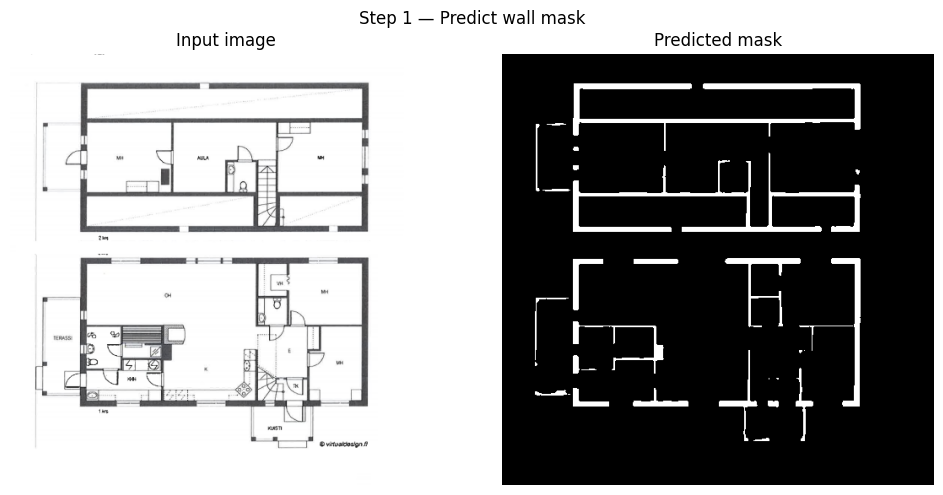

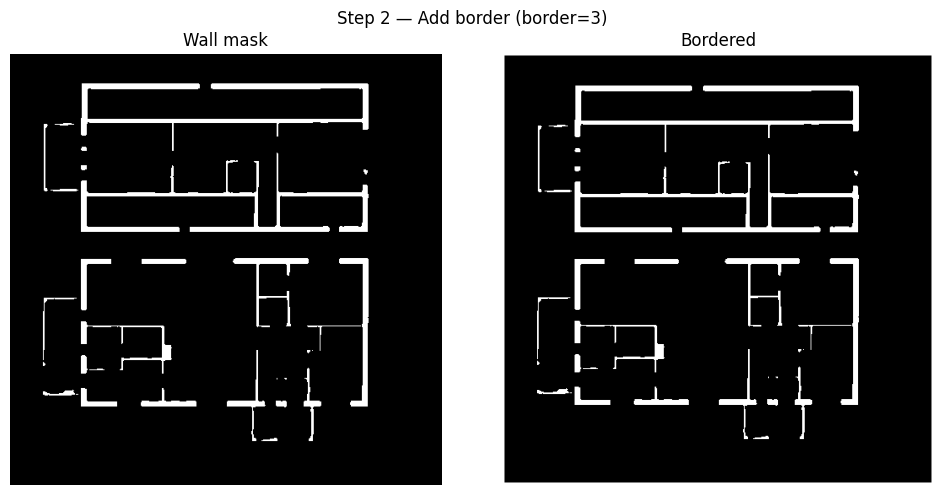

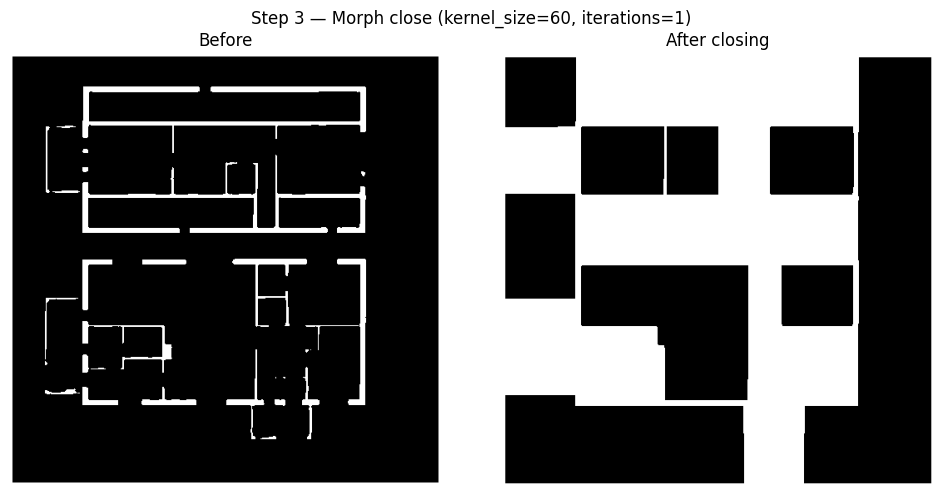

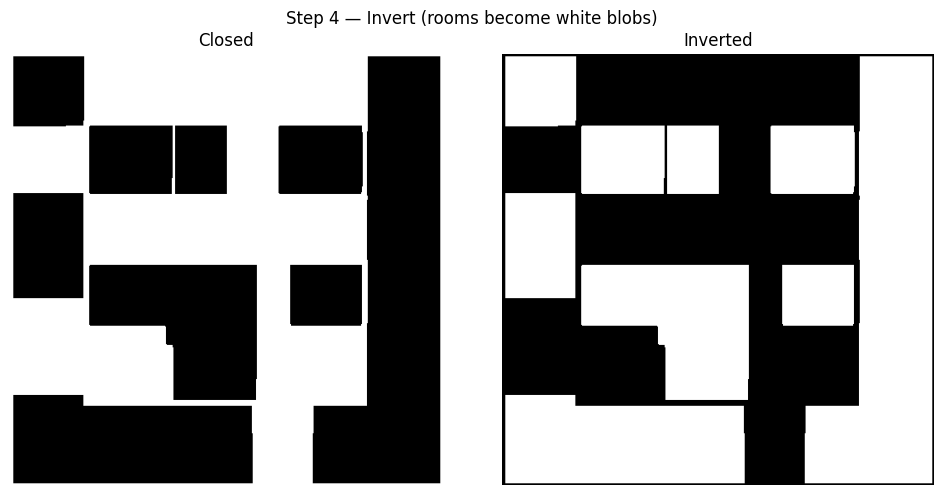

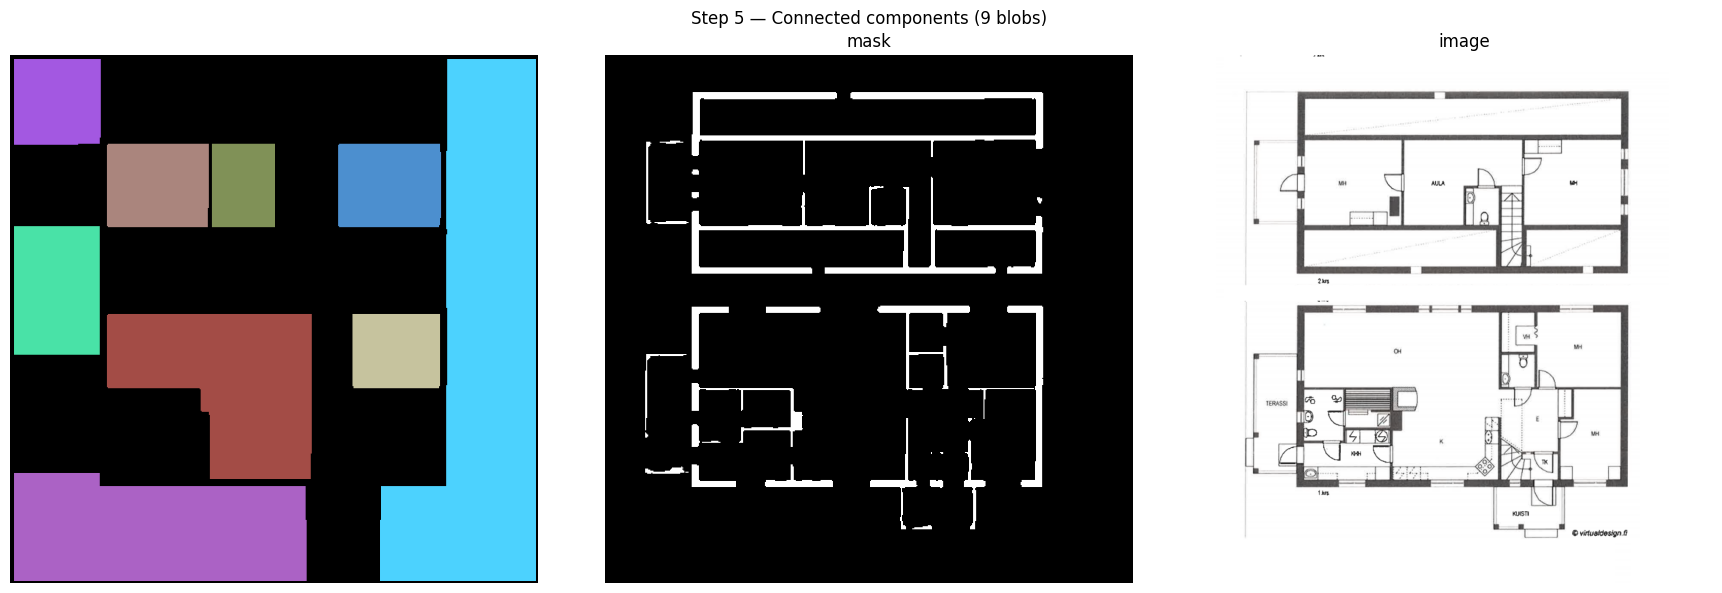

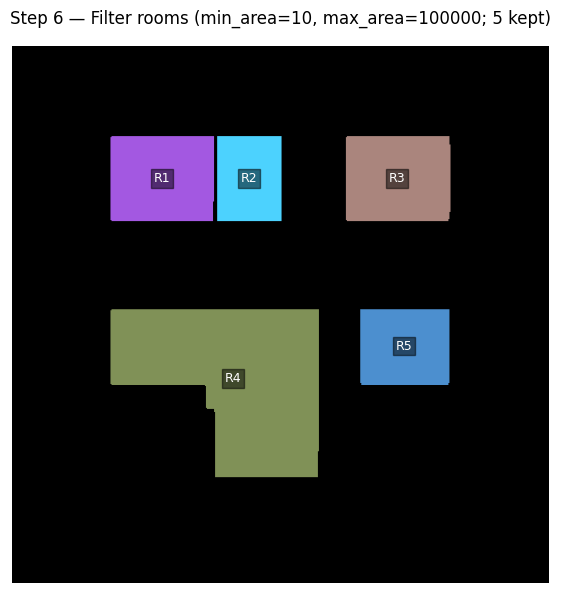

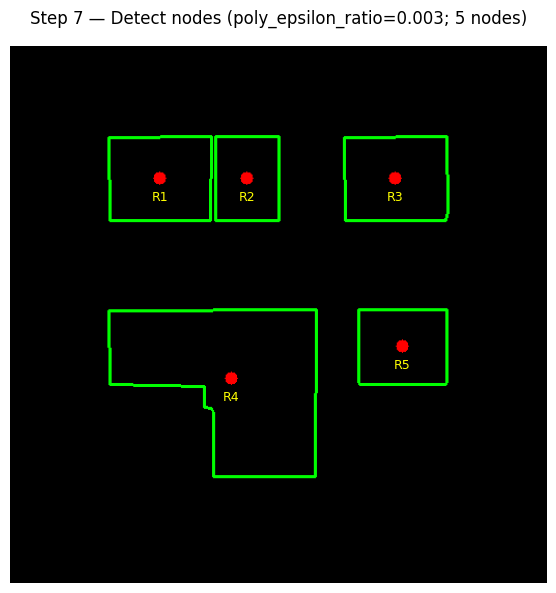

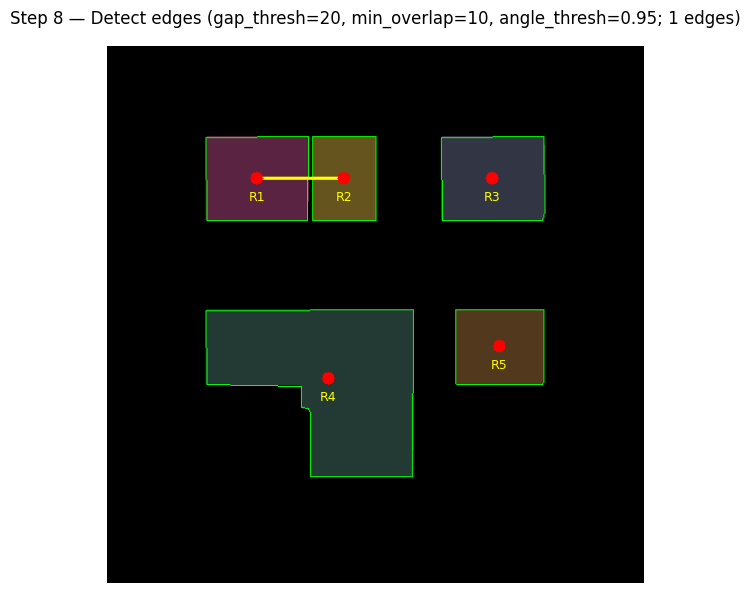

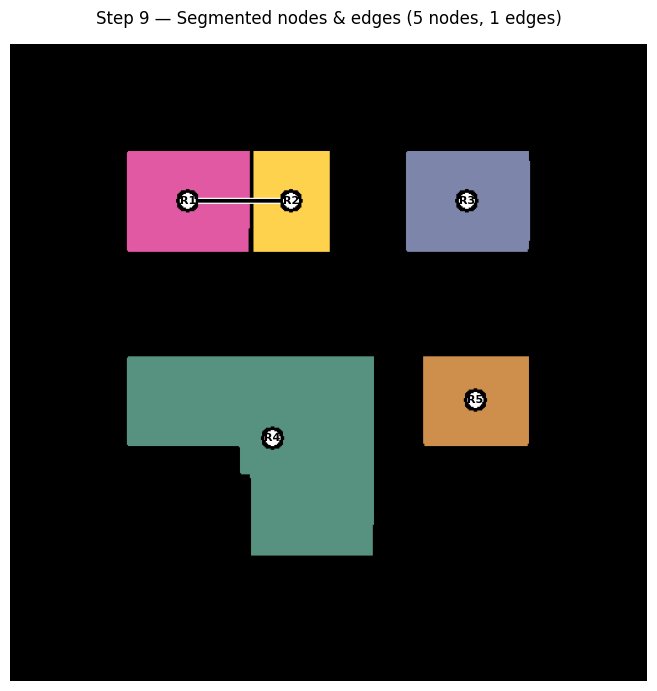

In [5]:
img_path = "test_images/test_image_2.png" #"test_images/image.png"
img = cv2.imread(img_path)

graph = gm.build_graph(
    img,
    border=3,
    kernel_size=60,
    iterations=1,
    min_room_area=10,
    max_room_area=100000,
    poly_epsilon_ratio=0.003,
    gap_thresh=20,
    min_overlap=10,
    angle_thresh=0.95,
    show=True,
)

print(graph)

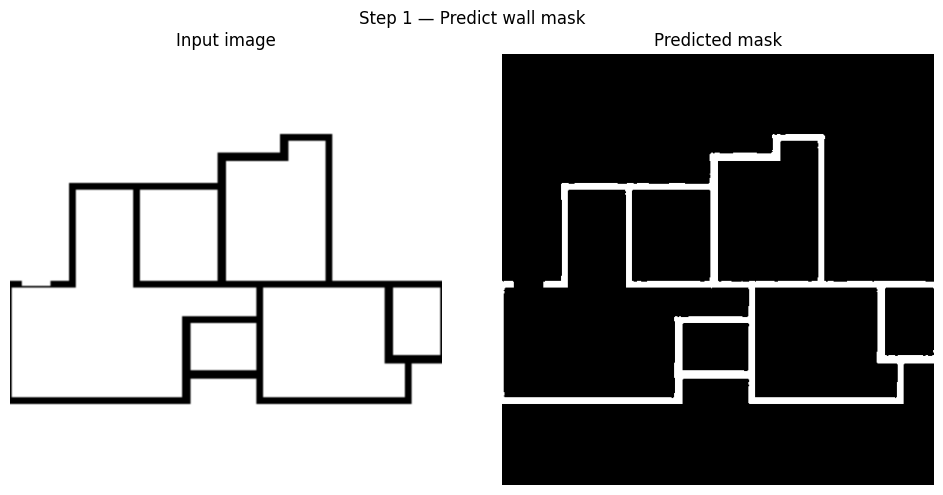

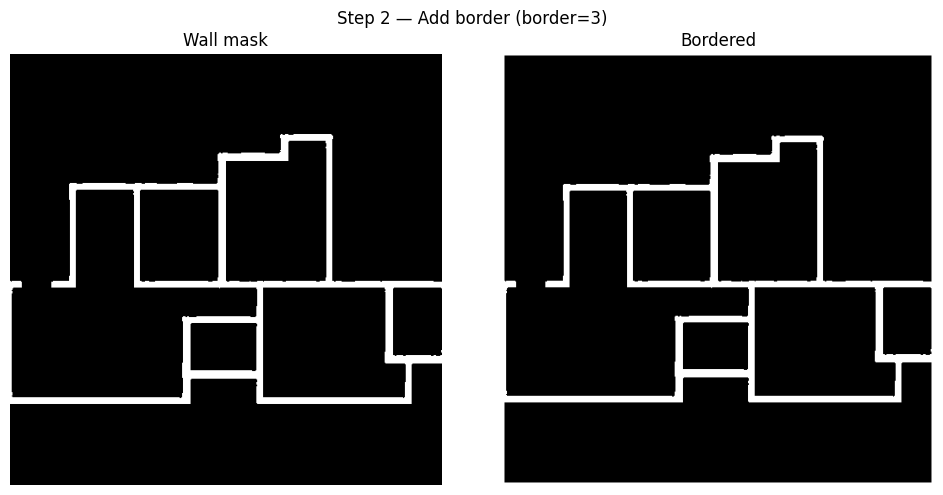

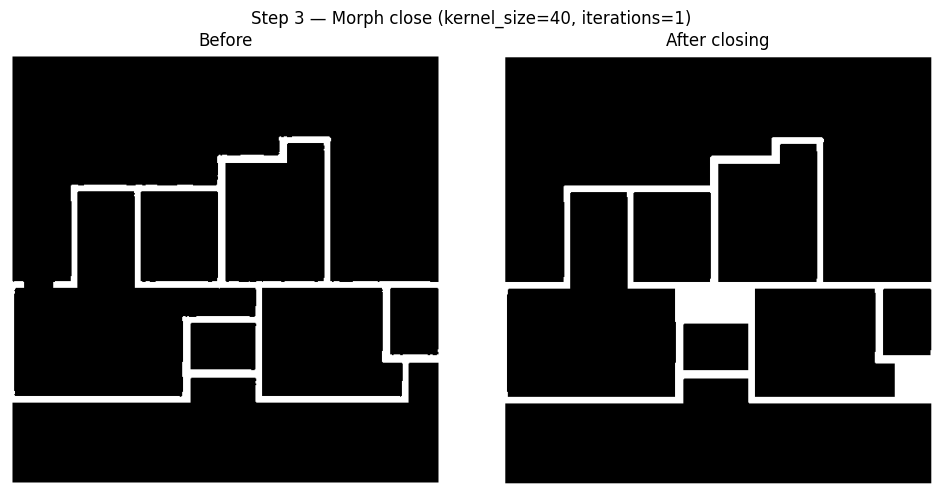

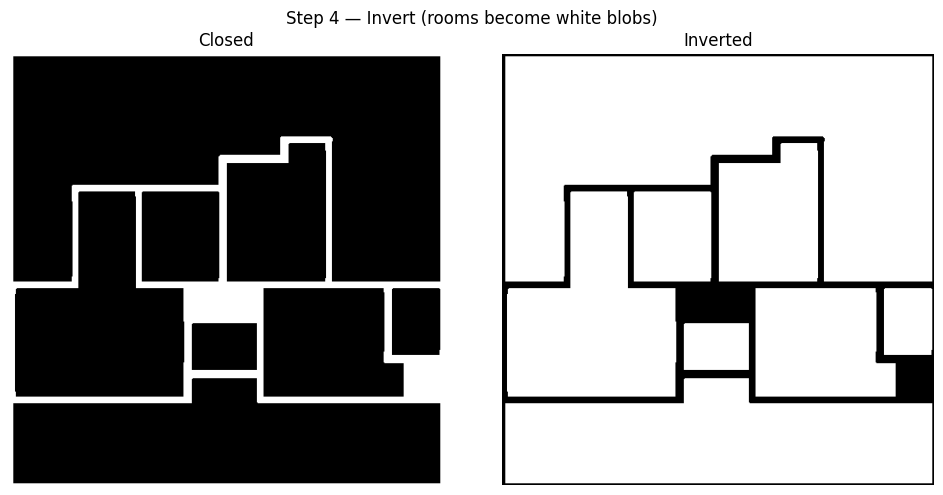

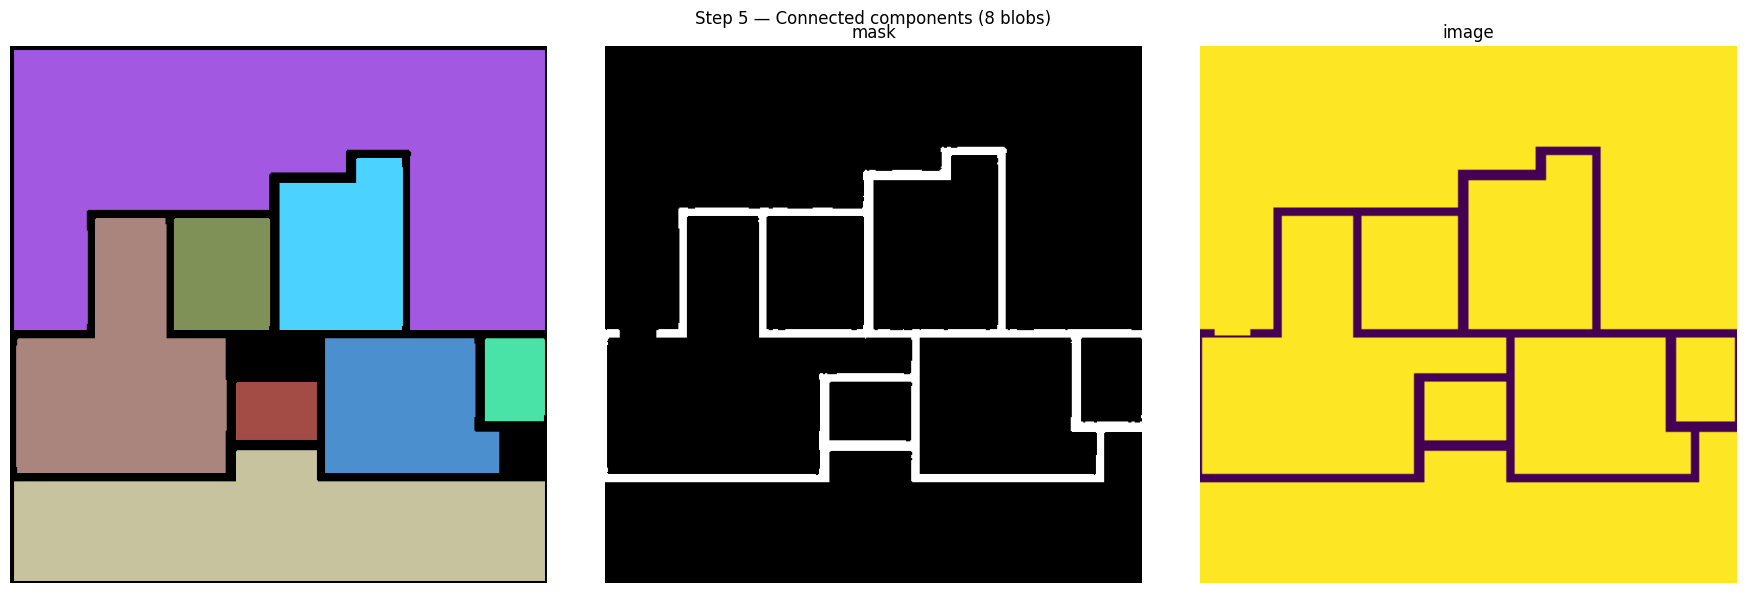

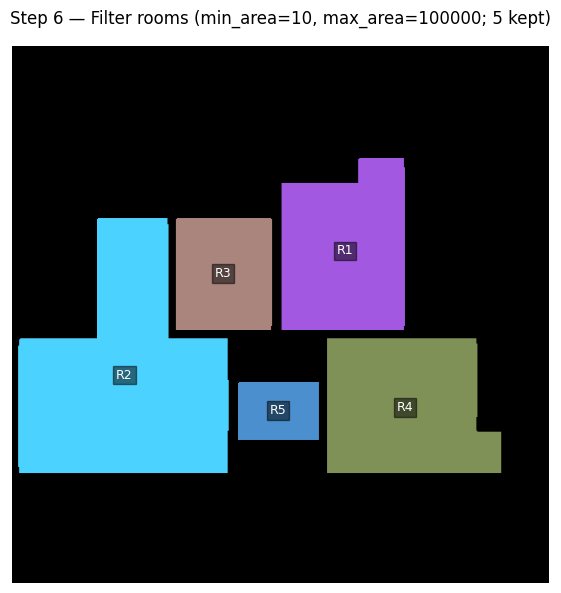

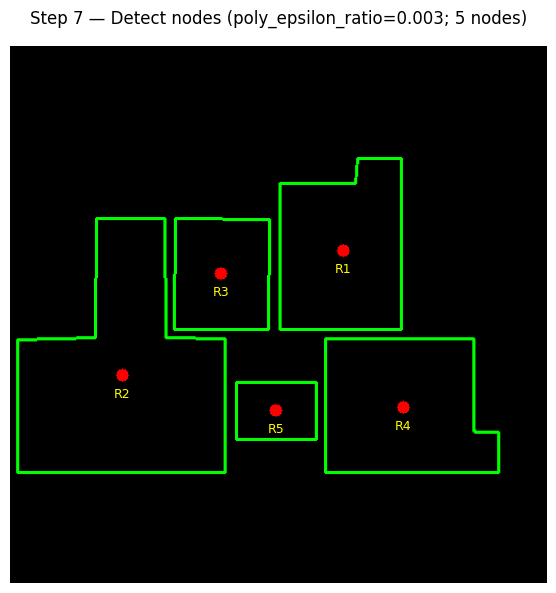

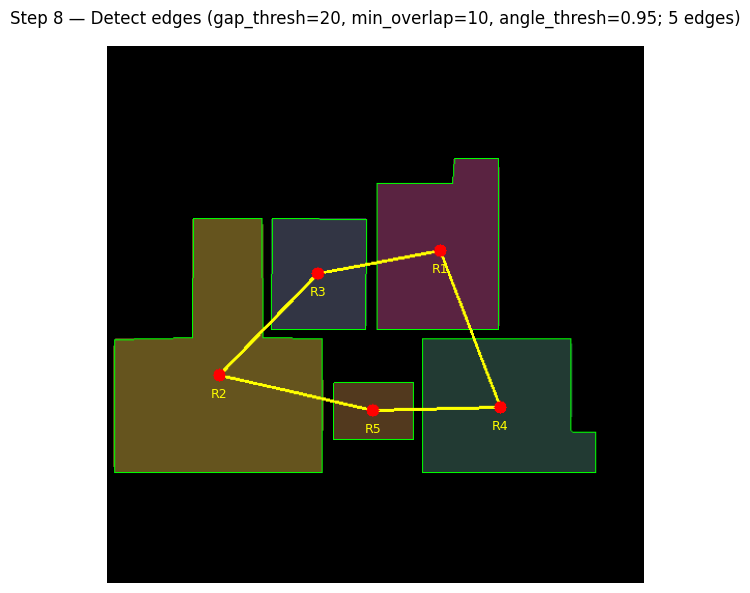

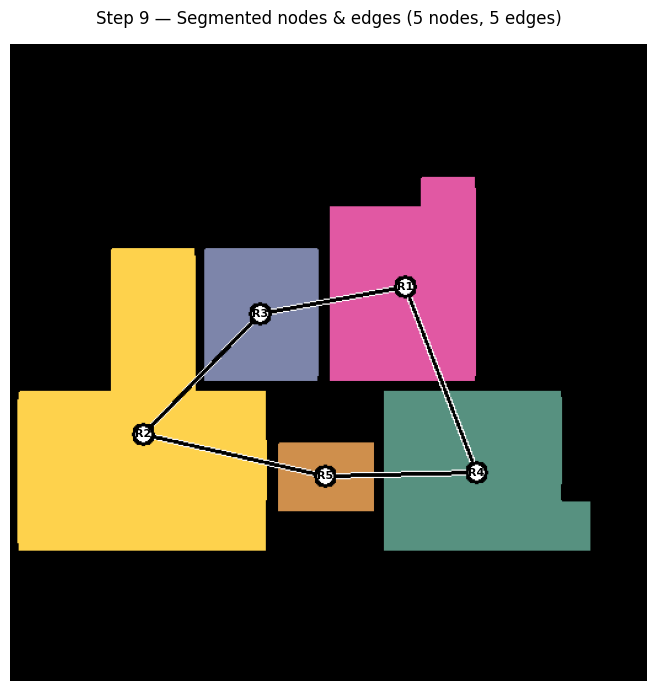

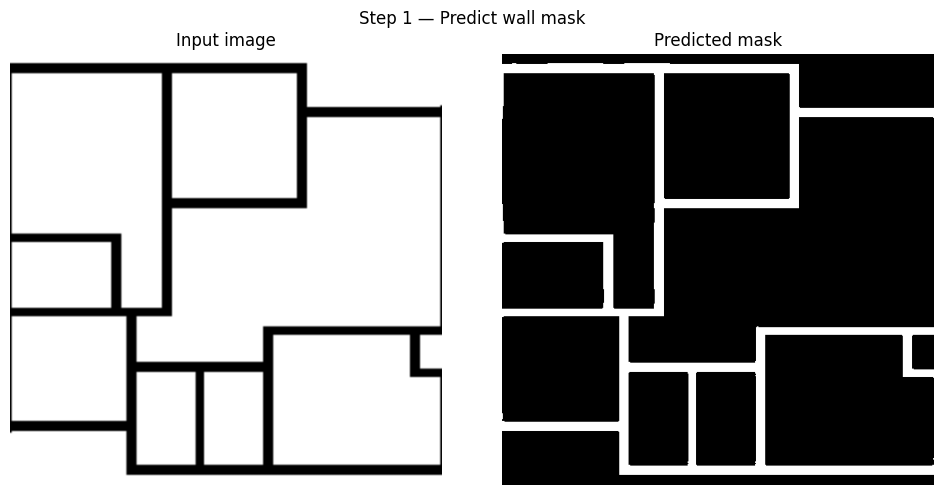

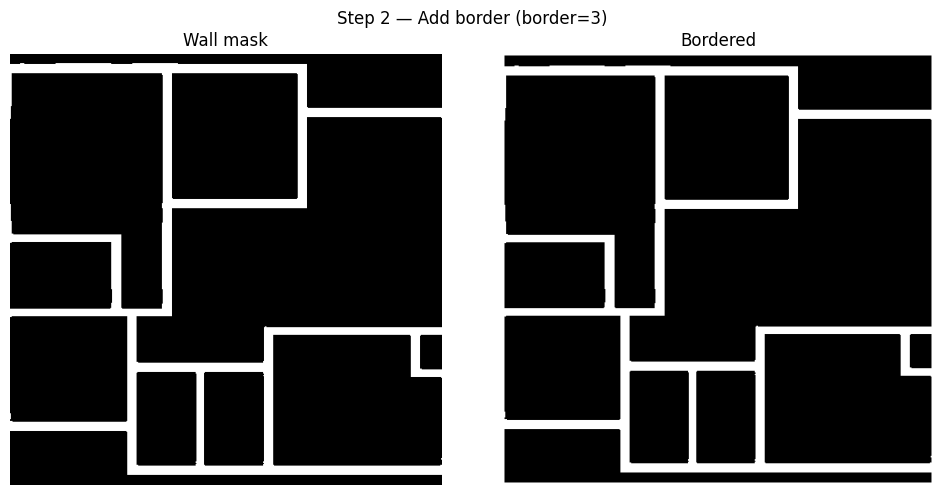

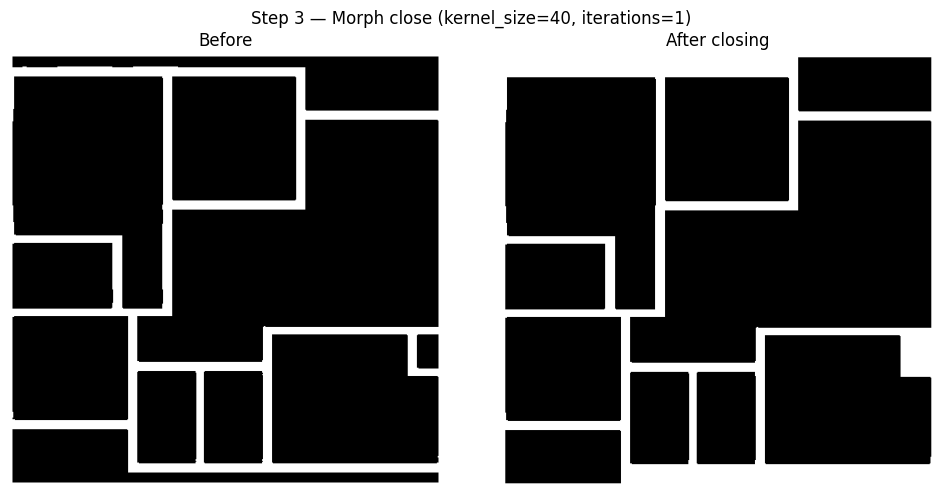

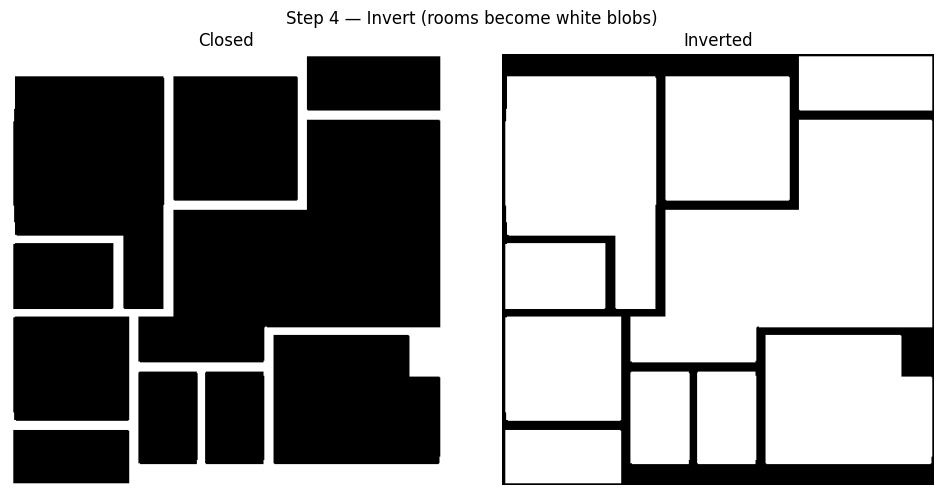

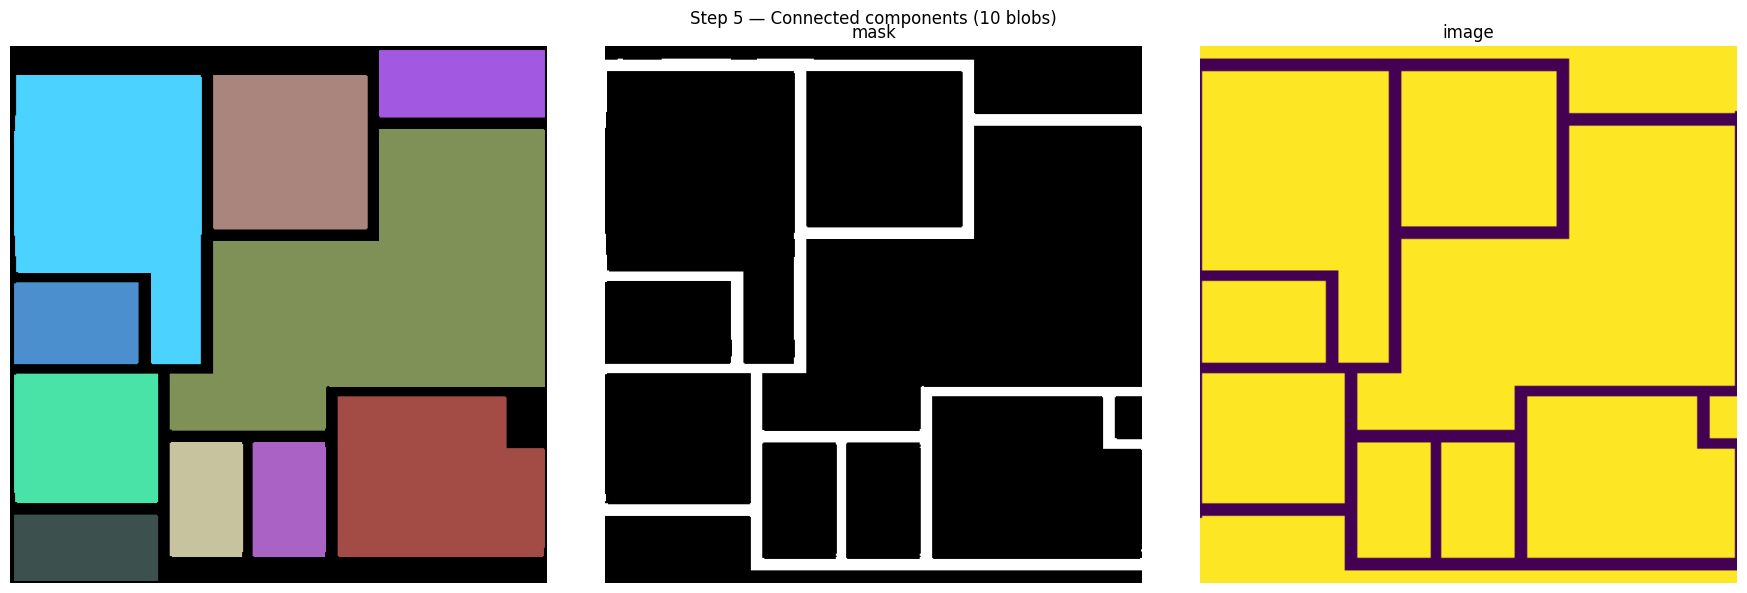

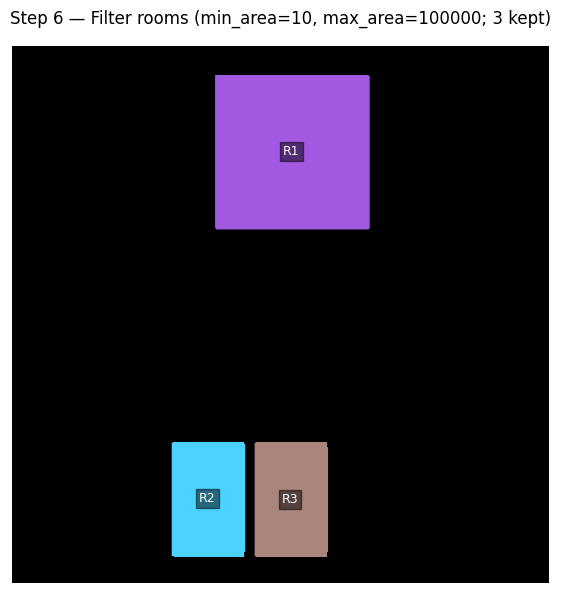

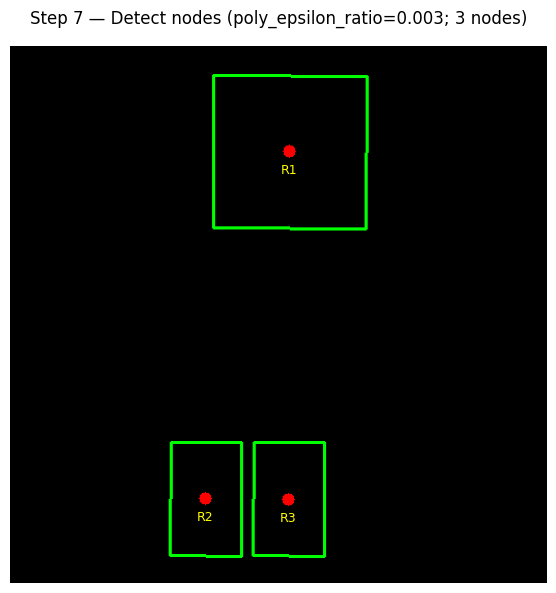

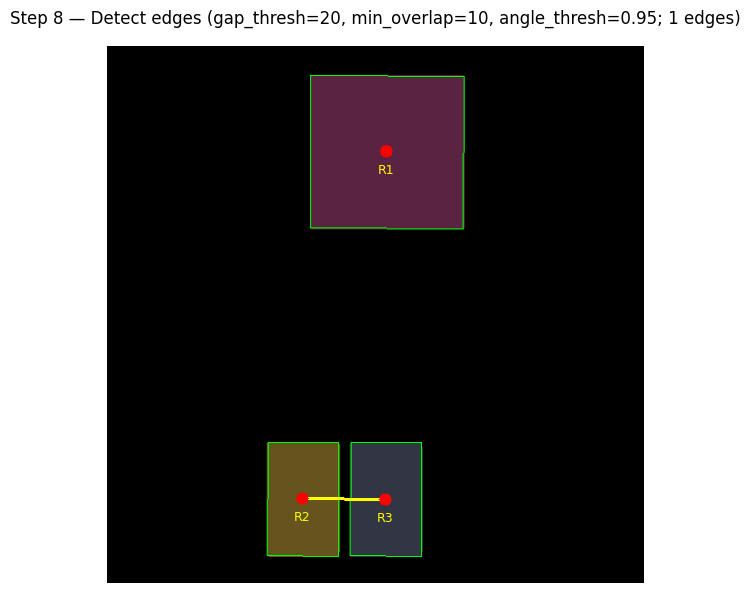

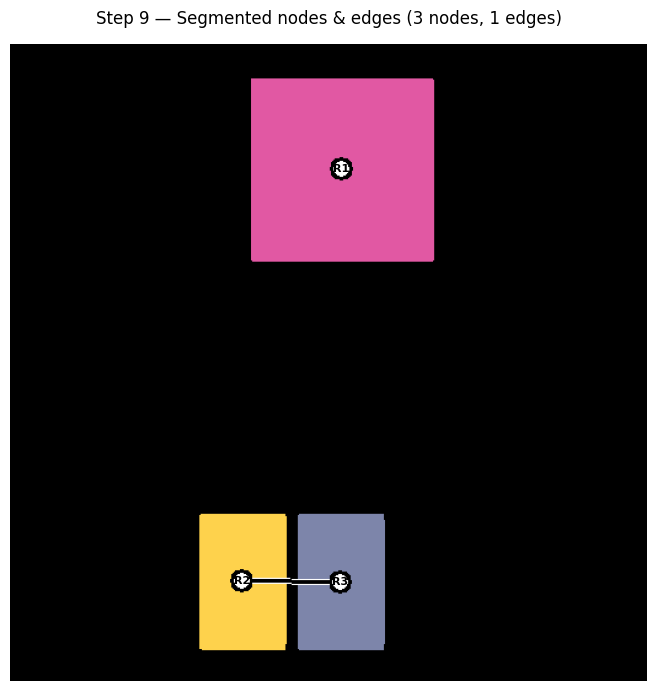

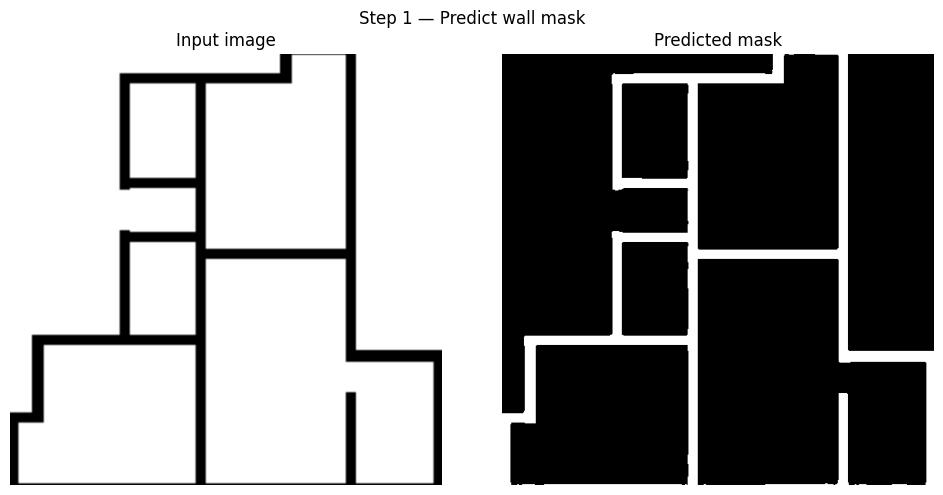

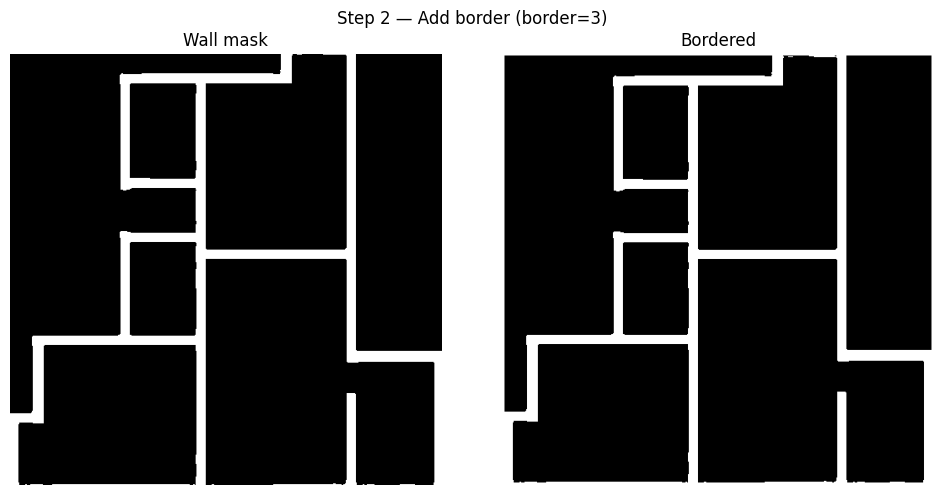

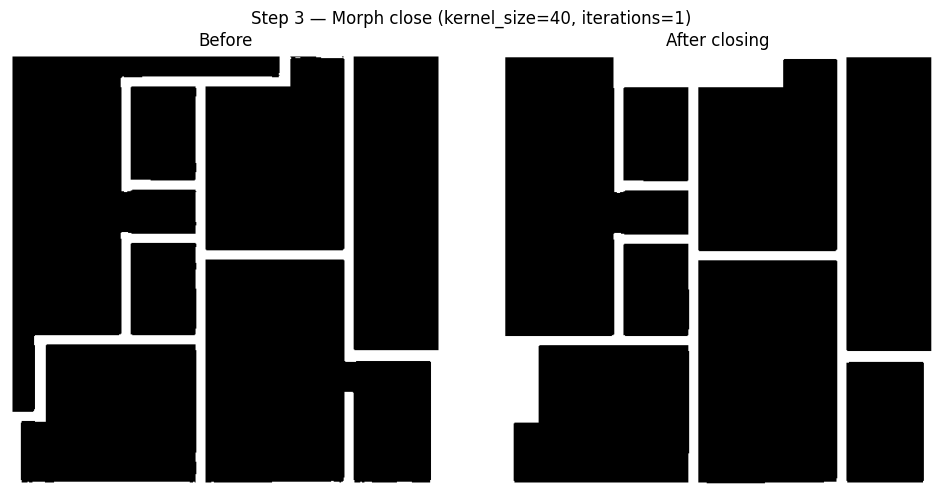

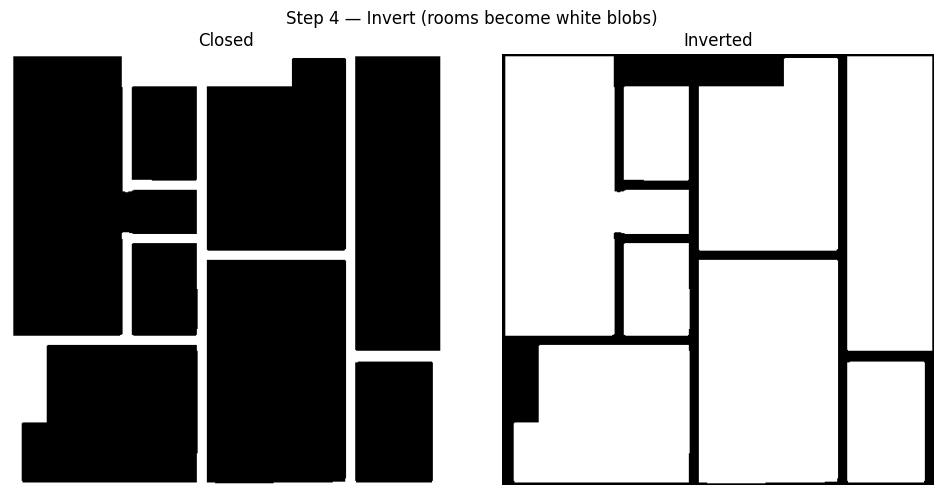

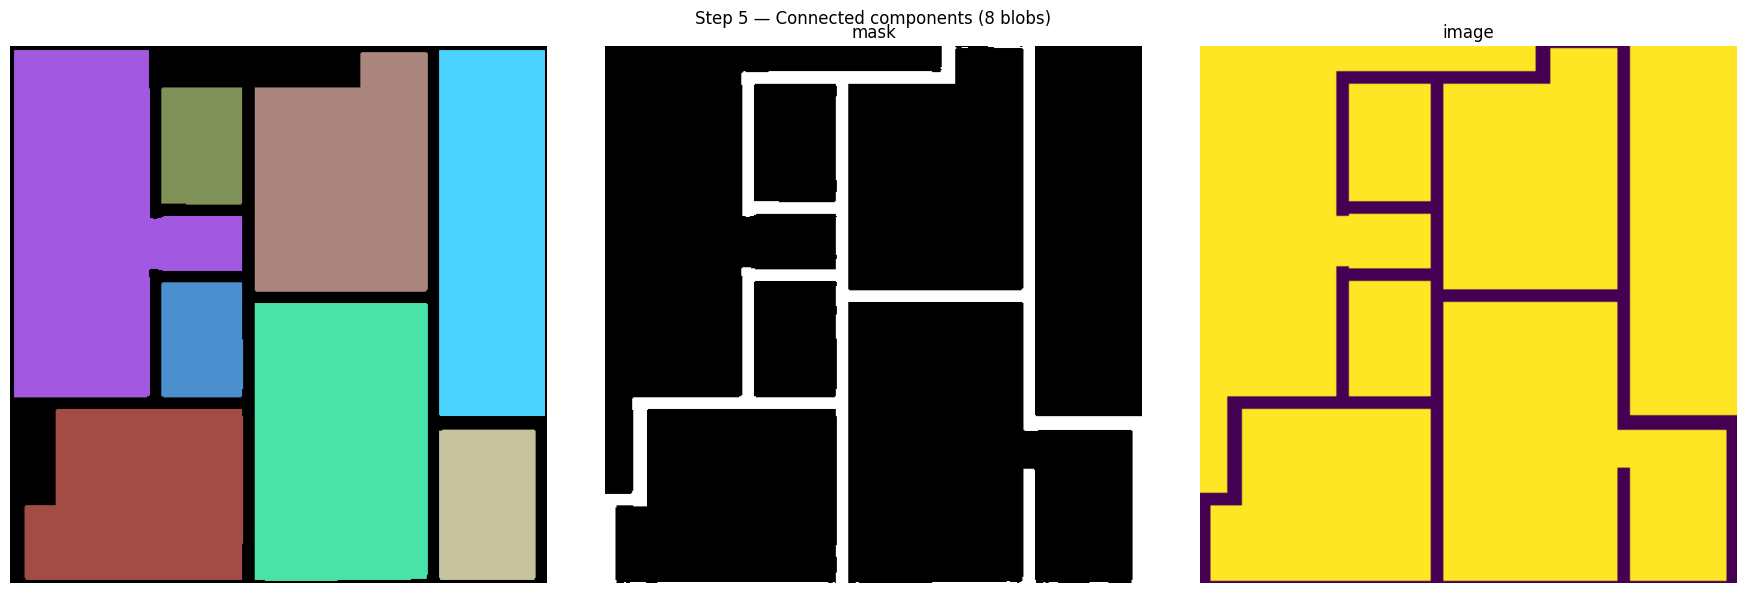

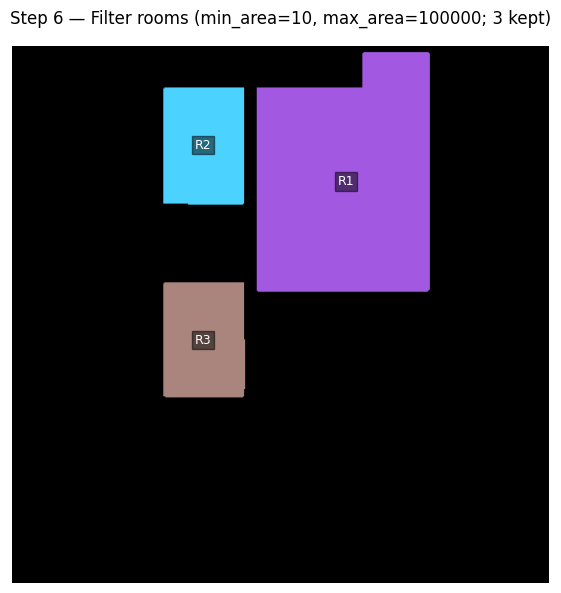

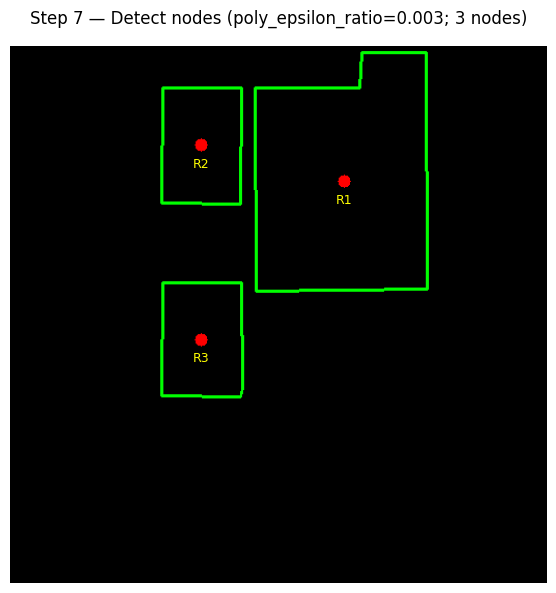

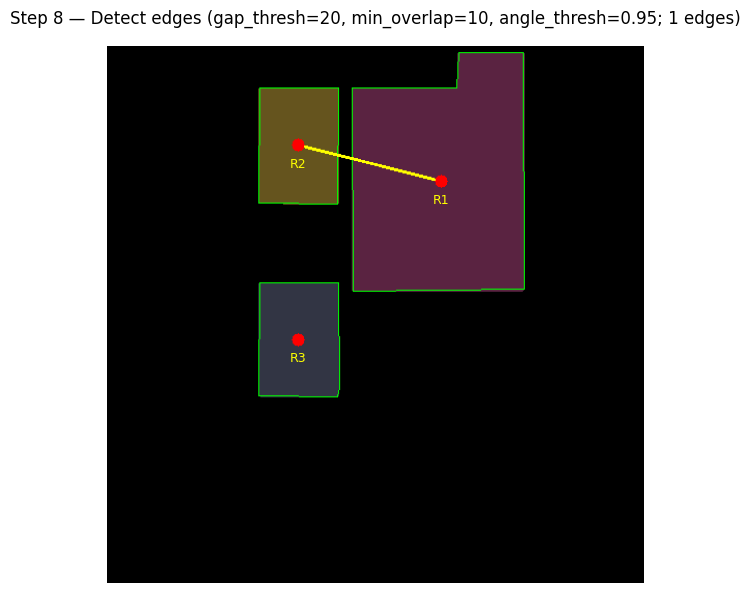

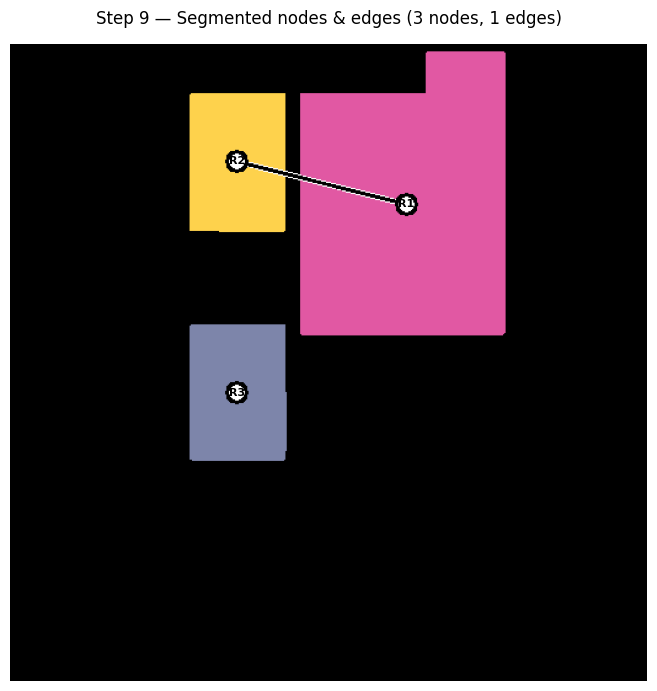

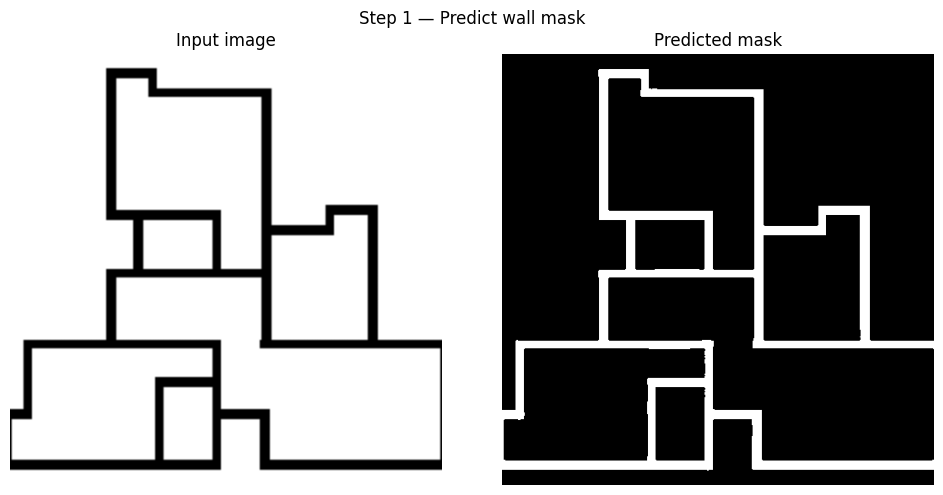

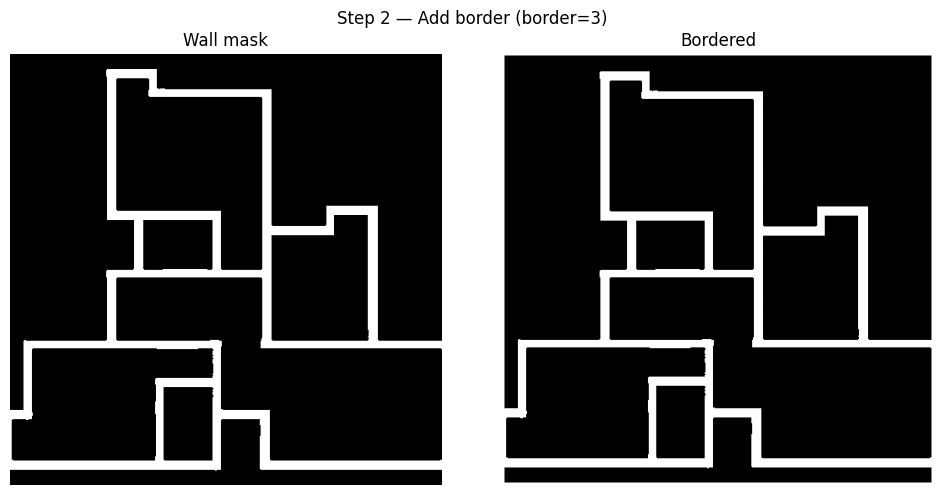

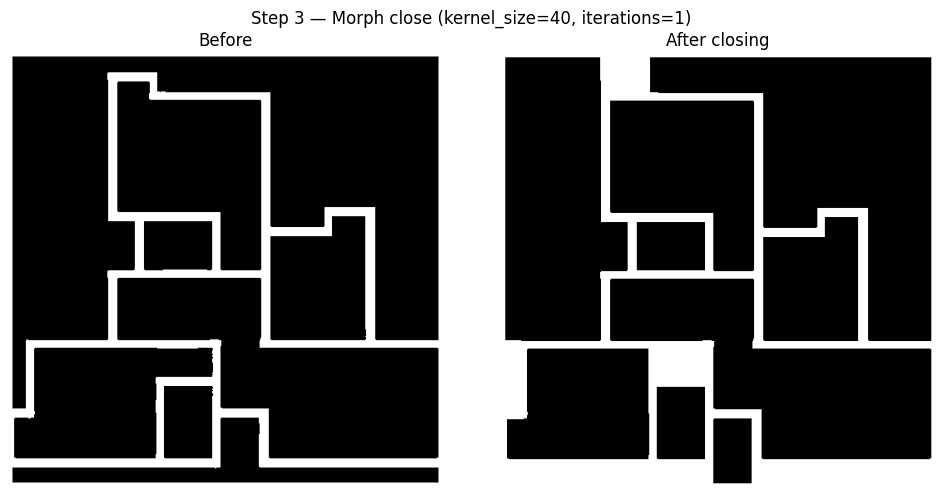

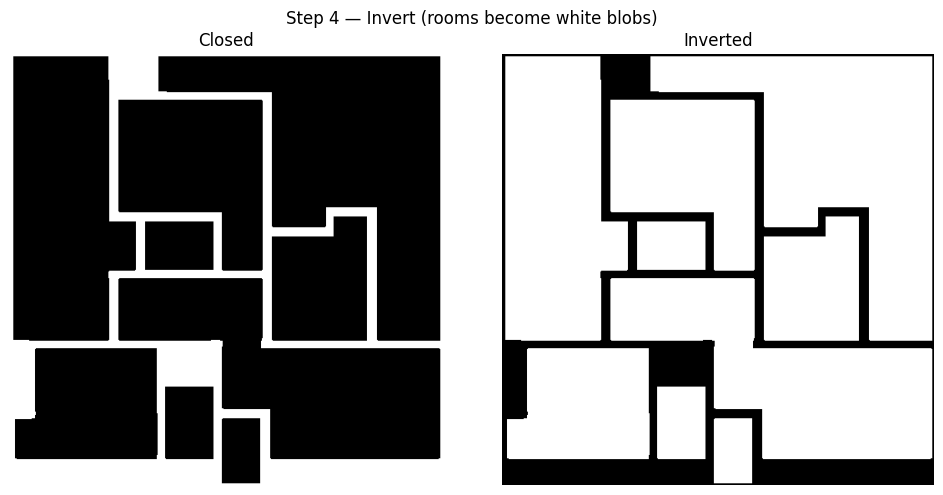

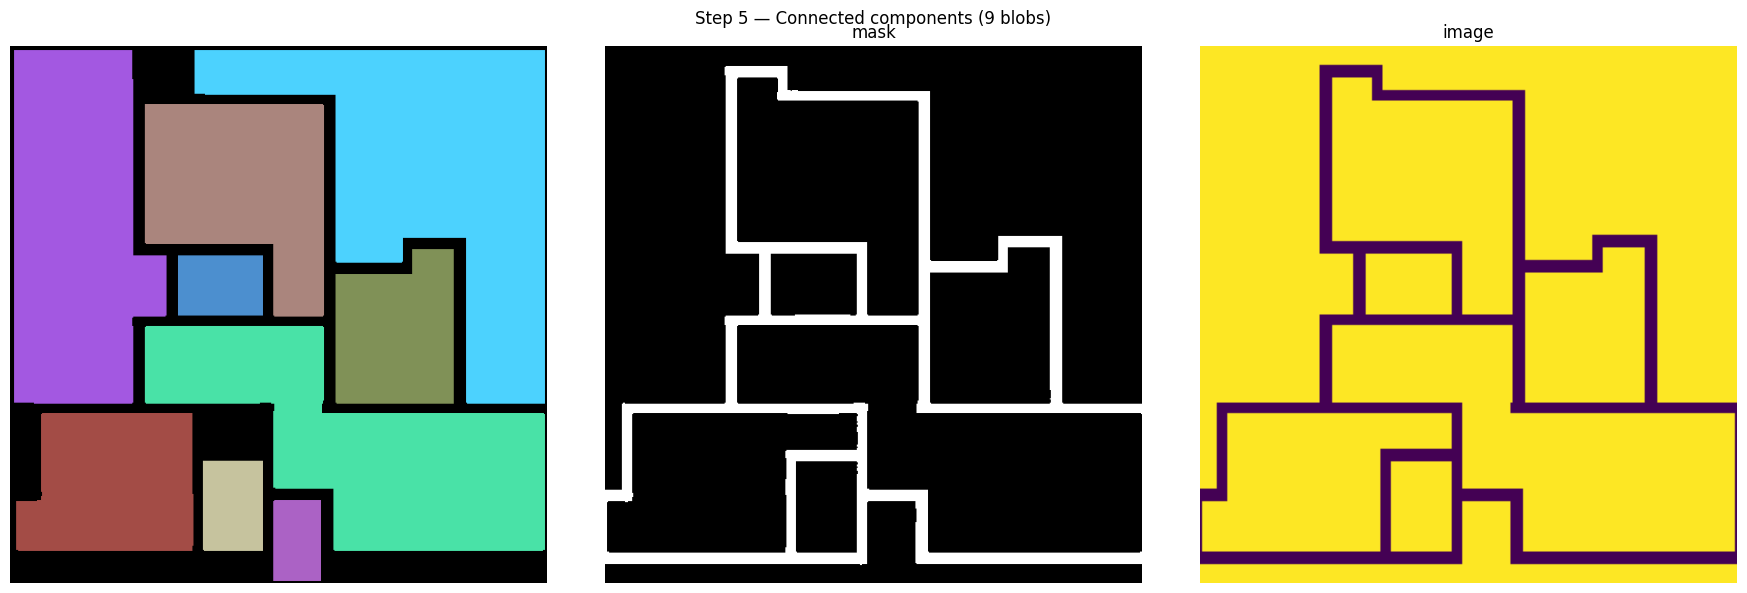

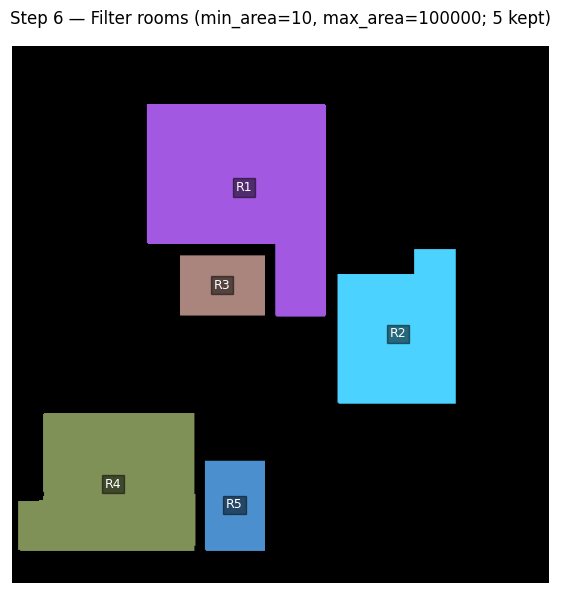

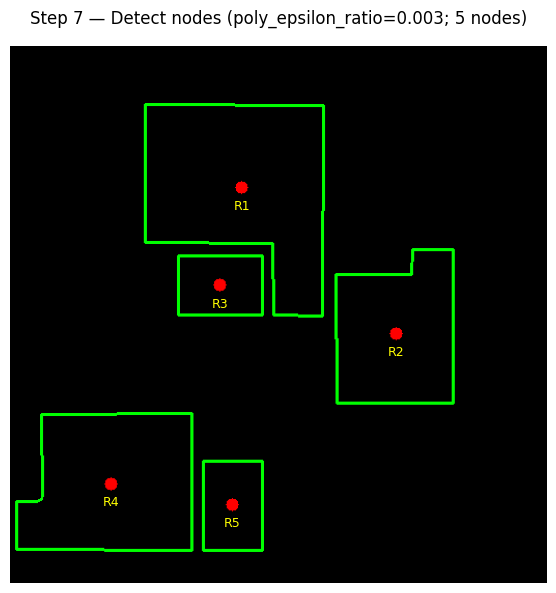

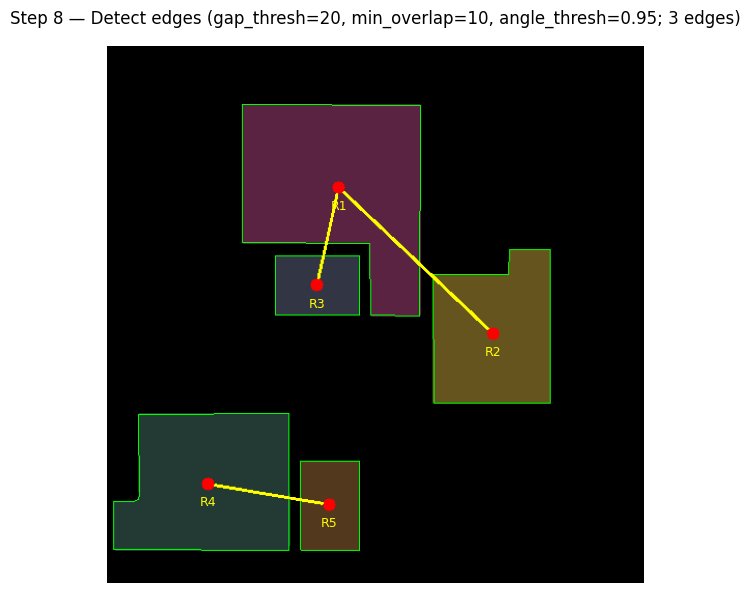

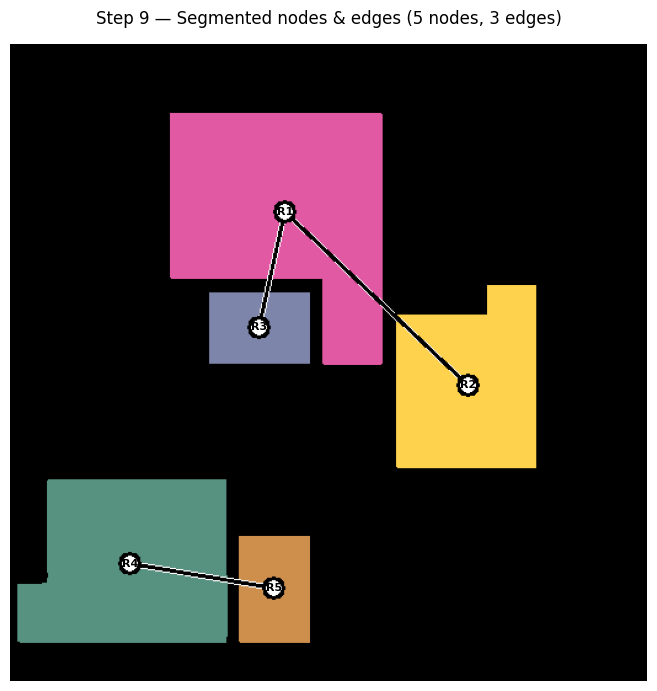

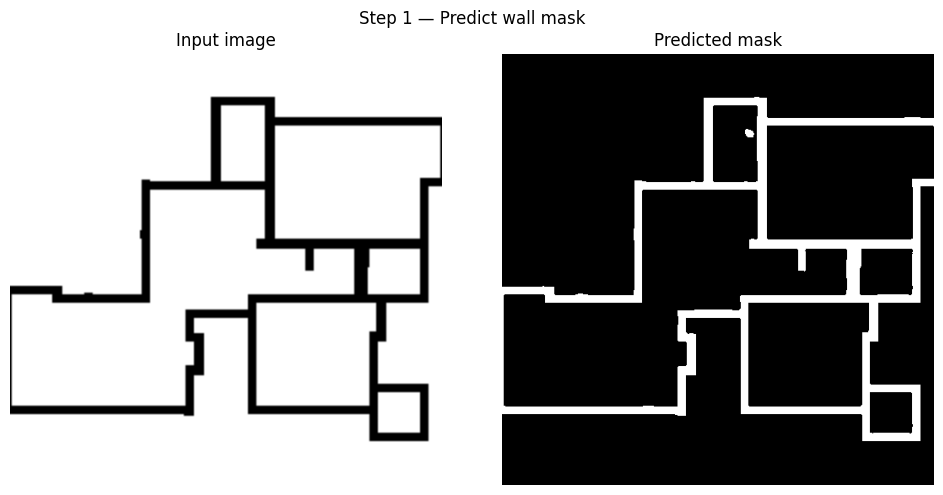

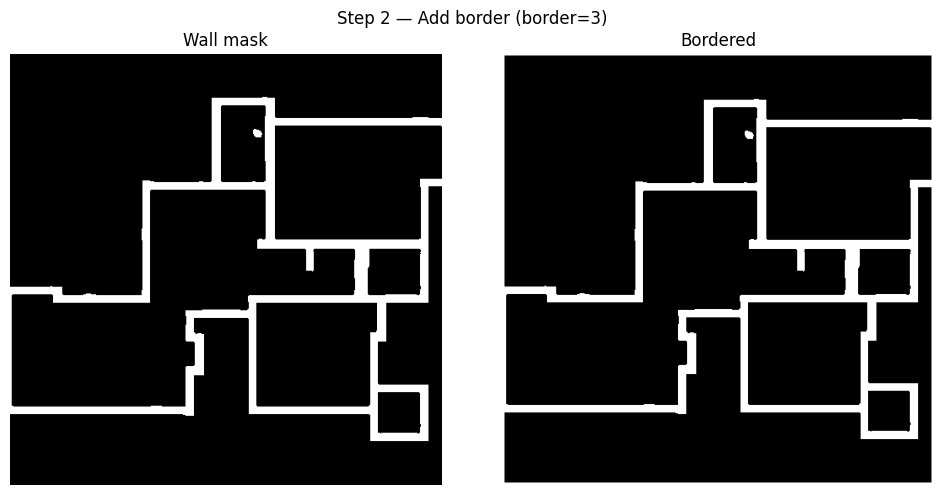

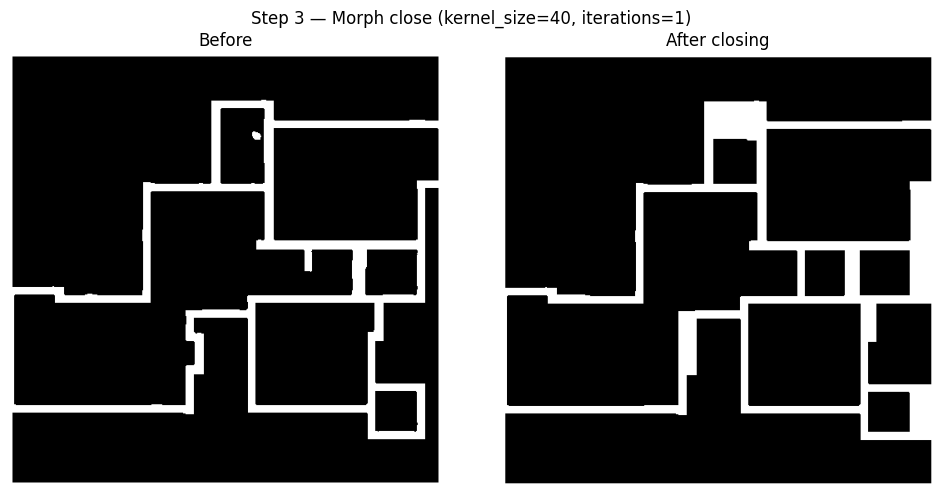

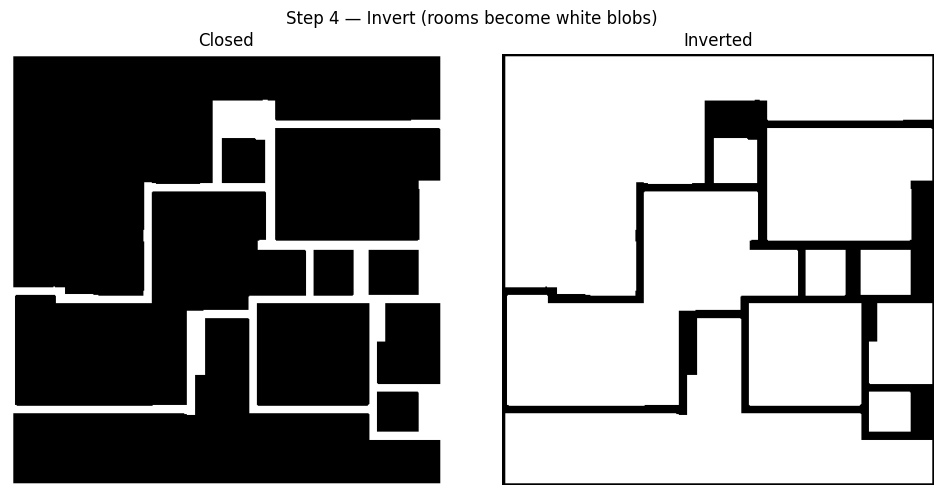

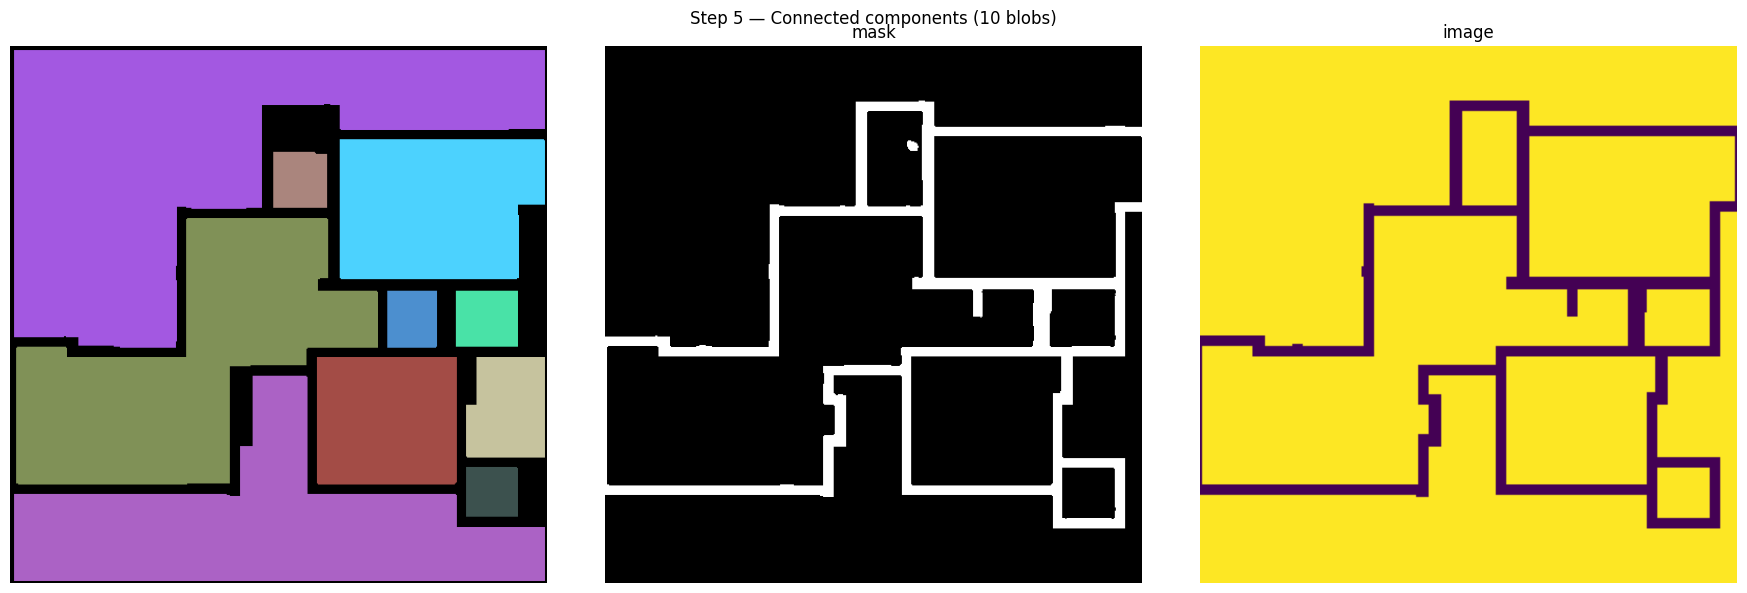

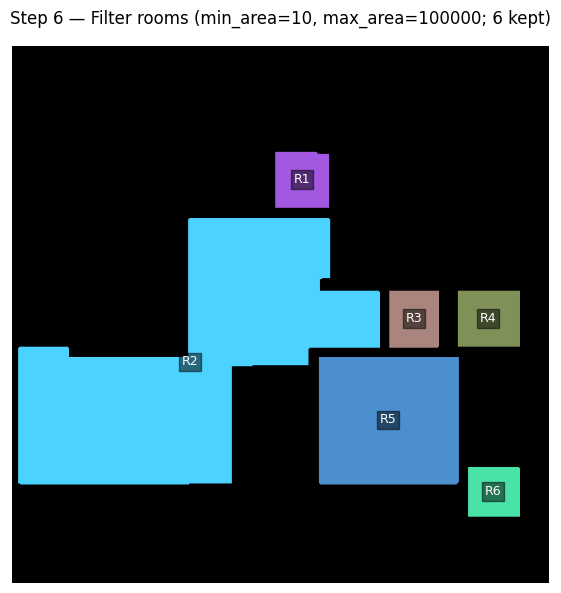

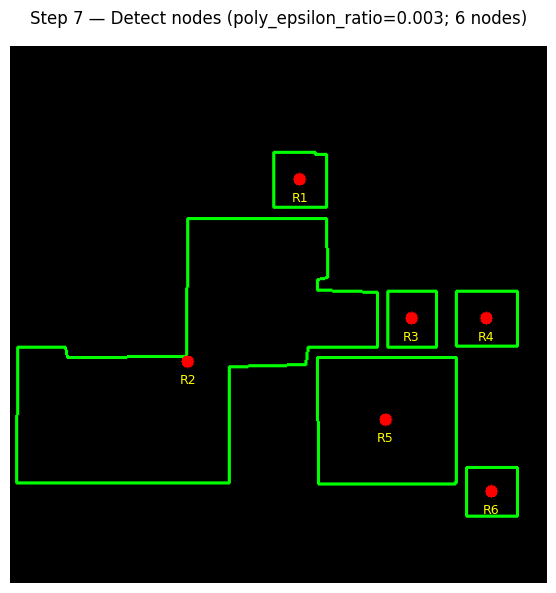

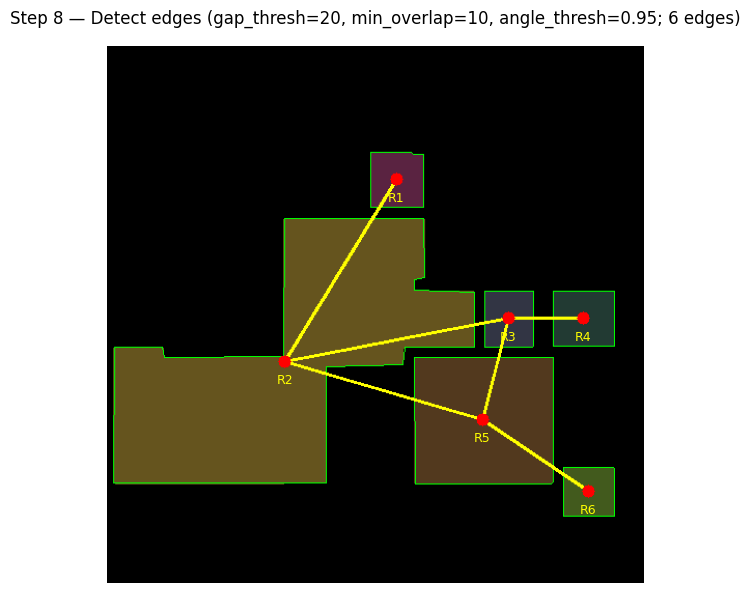

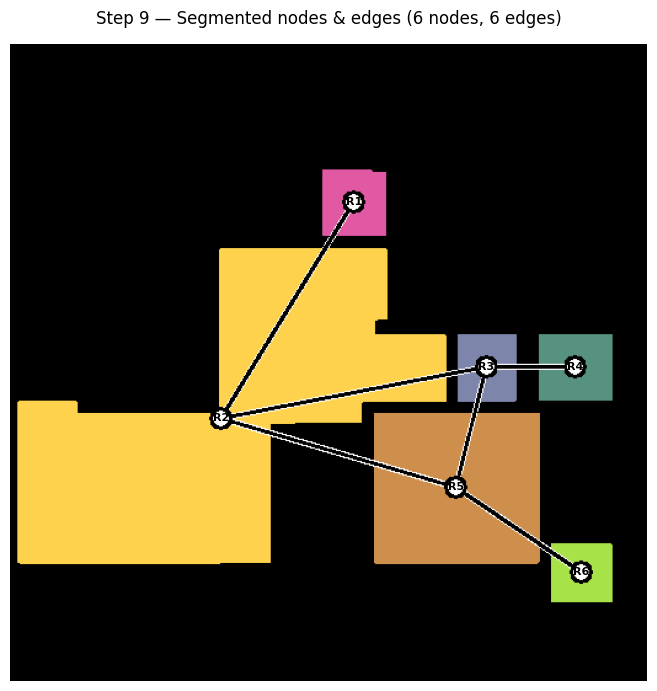

In [ ]:
# if 'plans' not in globals():
#     DATA_PATH = 'ResPlan.pkl'
#     with open(DATA_PATH, 'rb') as f:
#         plans = pickle.load(f)
#     print(f'Loaded {len(plans)} plans')



#for i in range(5):
for i in range(len(plans)):
    idx = i
    plan = plans[idx]

    SHAPE = (512, 512)

    img = get_2d_plan(plan, show=False, diff=False)

    graph = gm.build_graph(
        img,
        border=3,
        kernel_size=40,
        iterations=1,
        min_room_area=10,
        max_room_area=100000,
        poly_epsilon_ratio=0.003,
        gap_thresh=20,
        min_overlap=10,
        angle_thresh=0.95,
        show=True,
    )

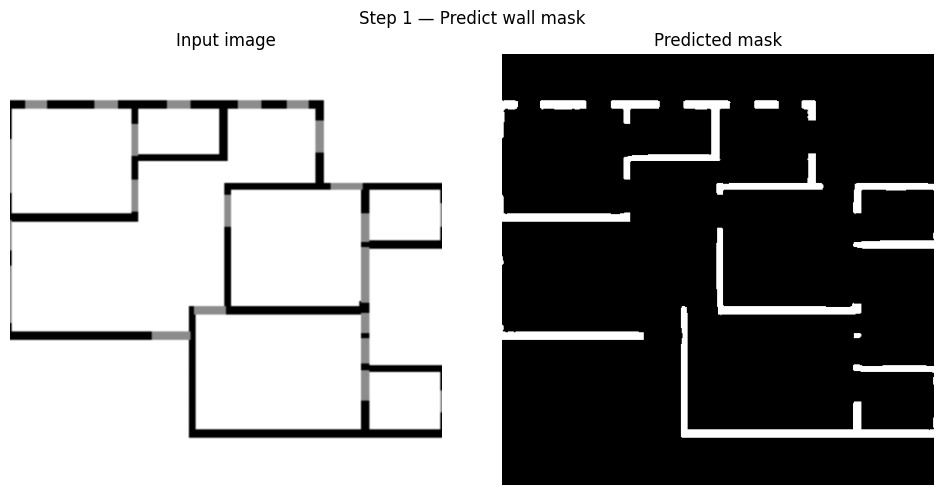

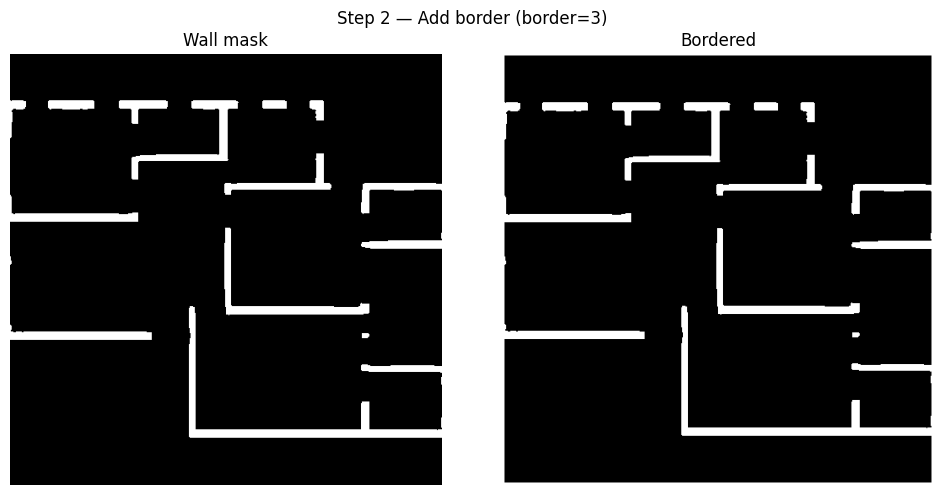

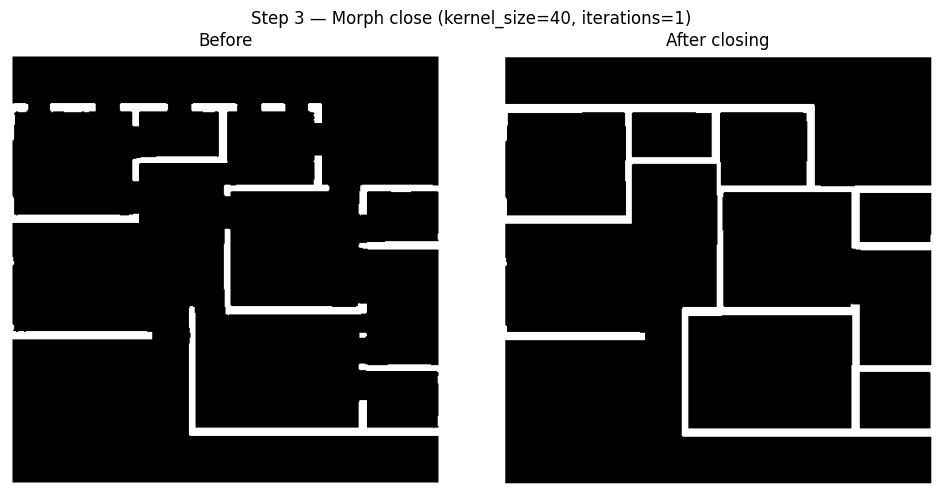

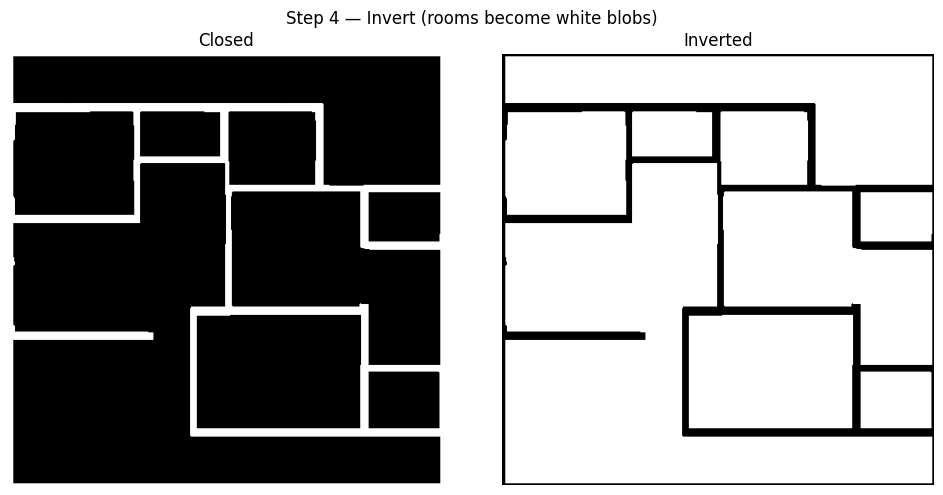

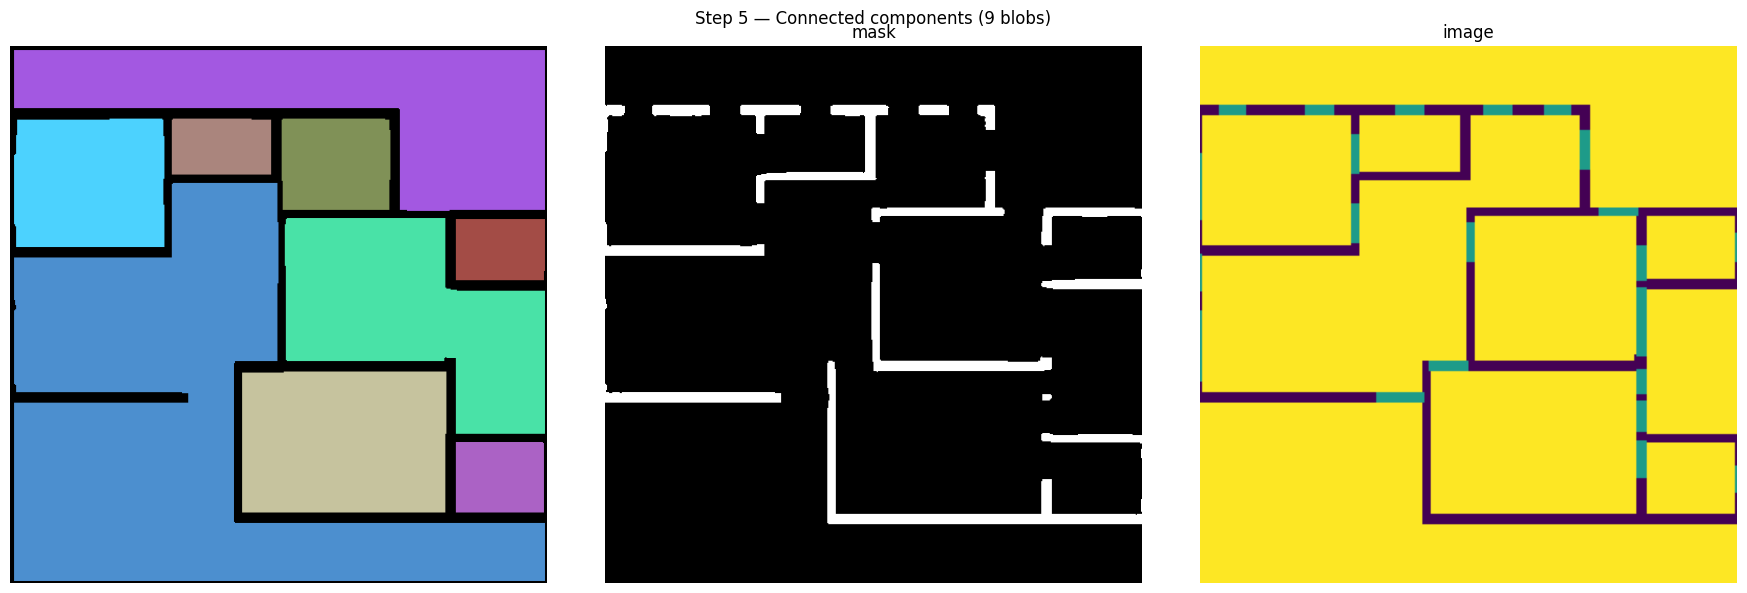

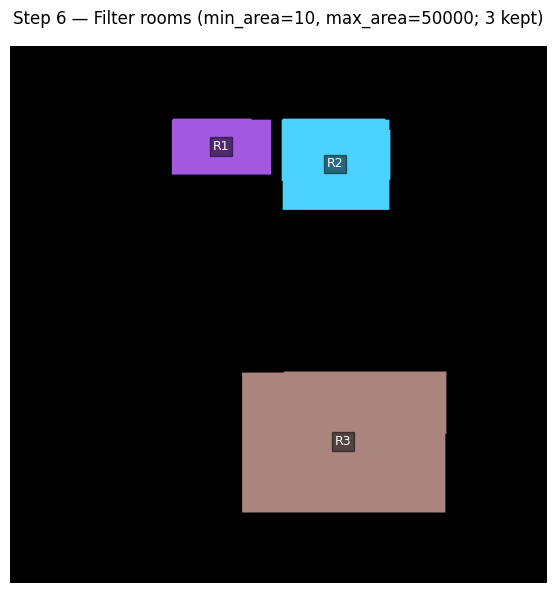

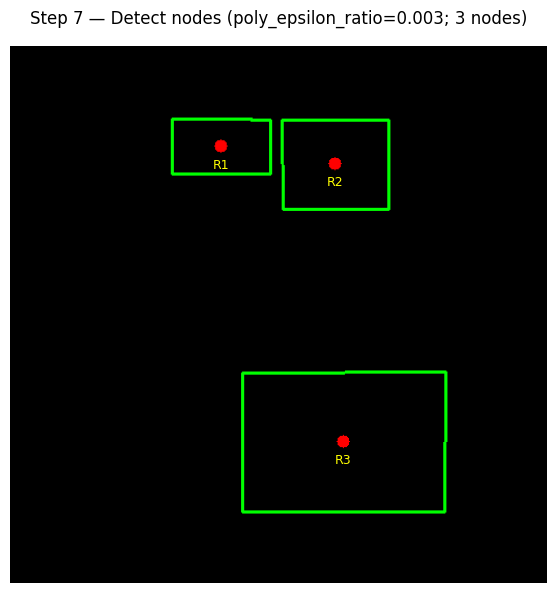

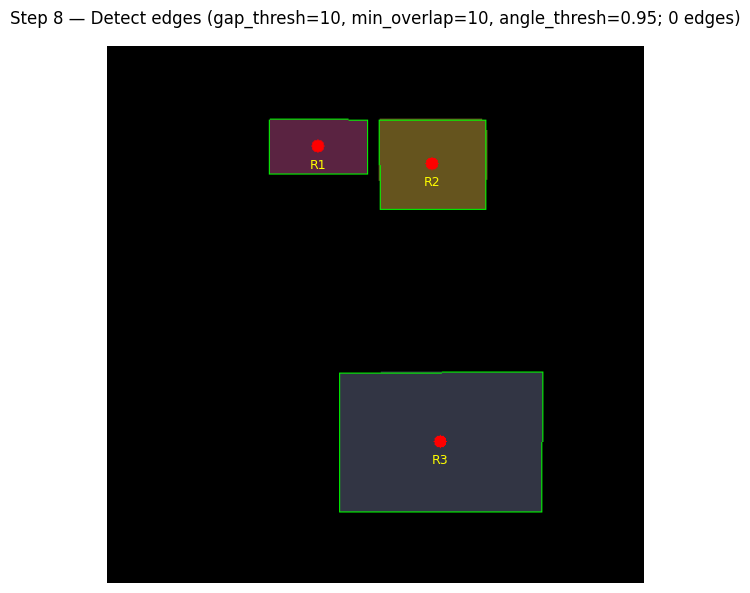

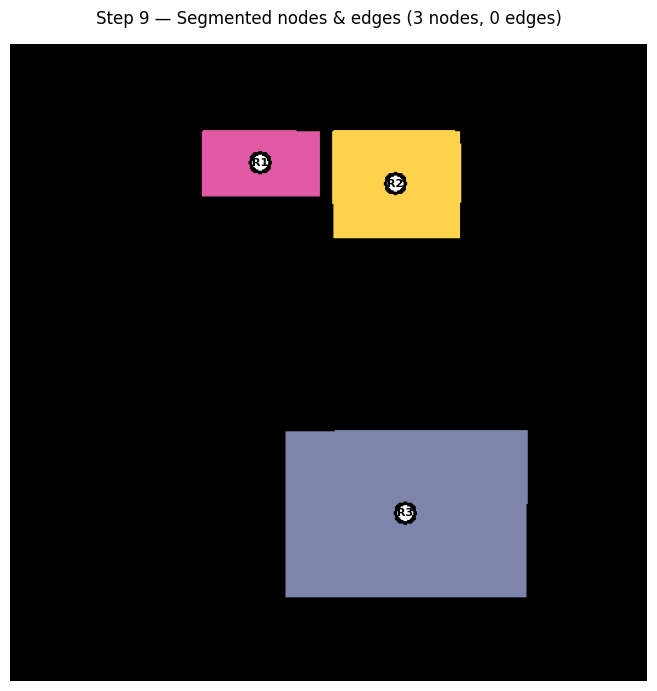

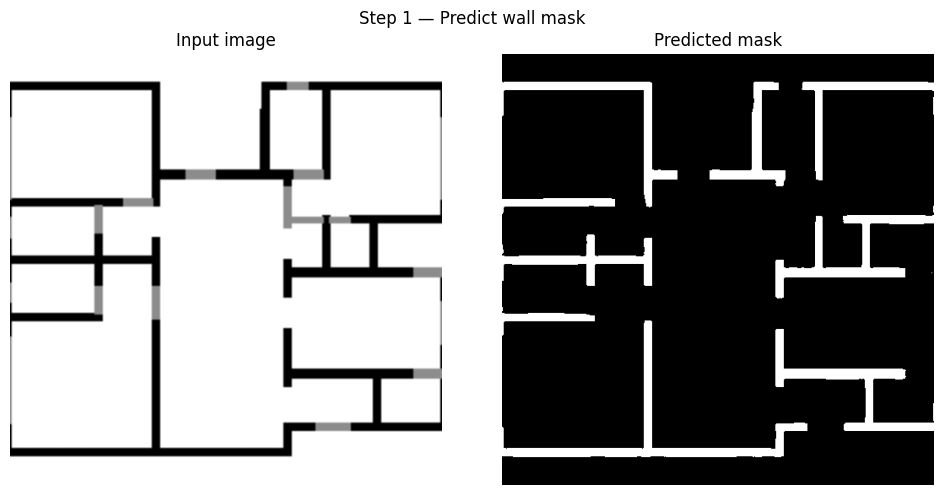

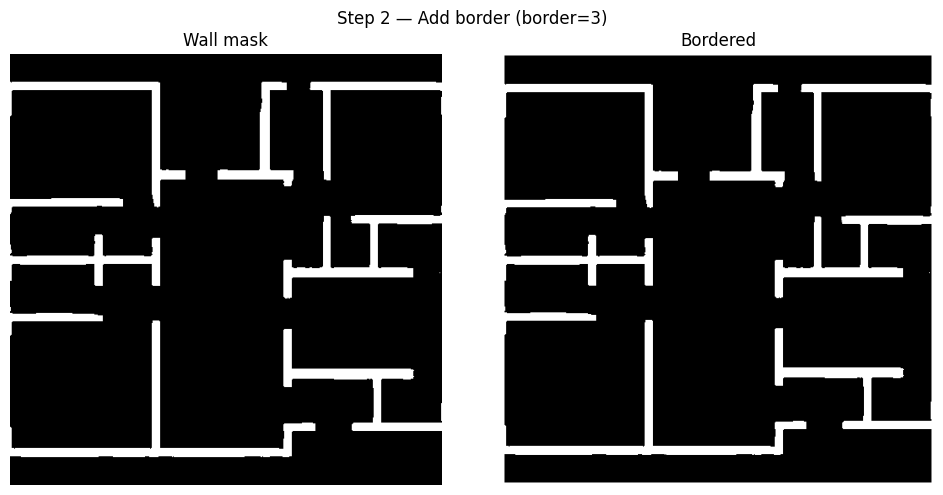

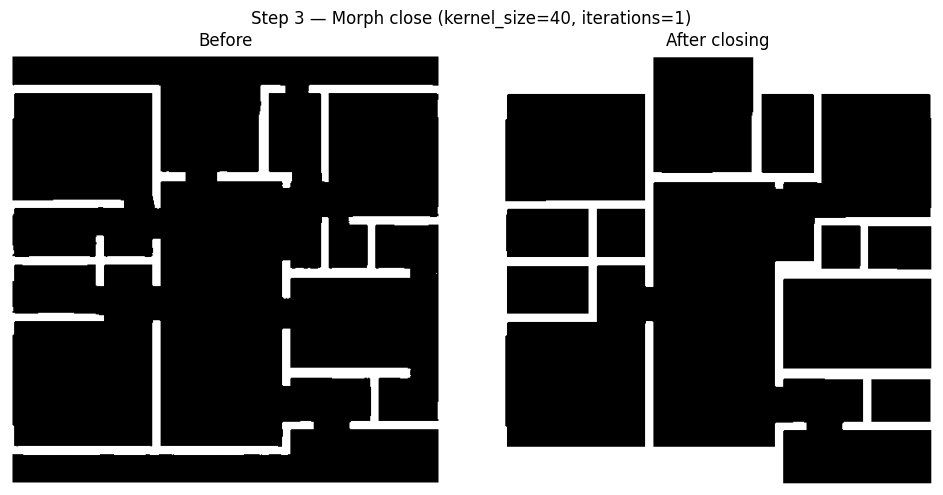

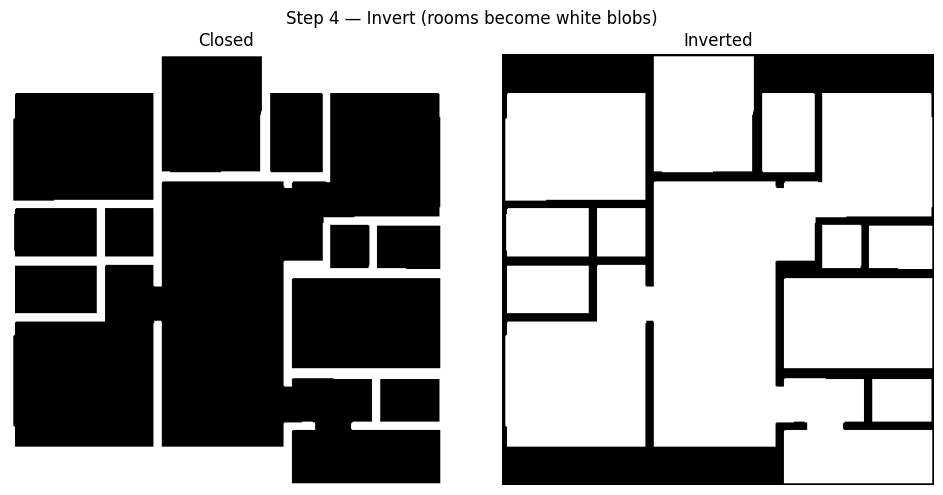

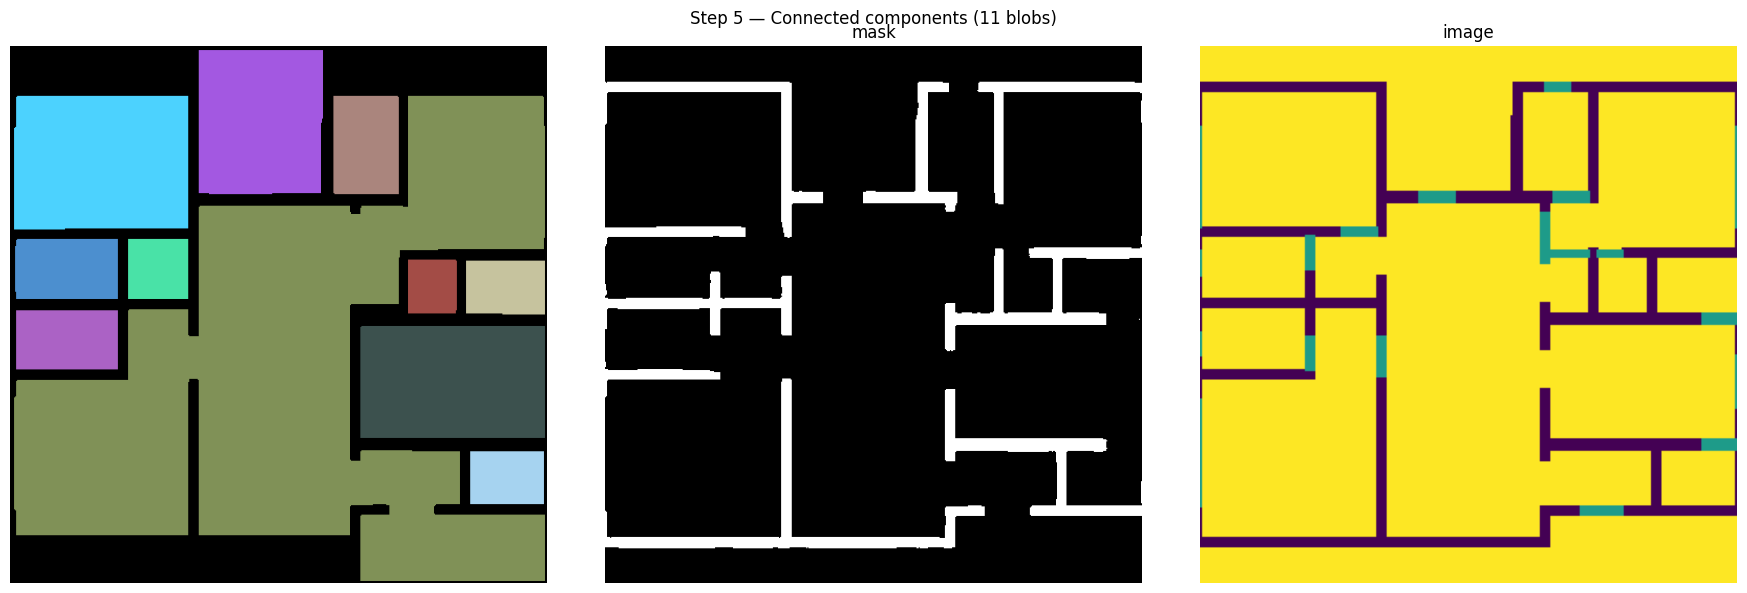

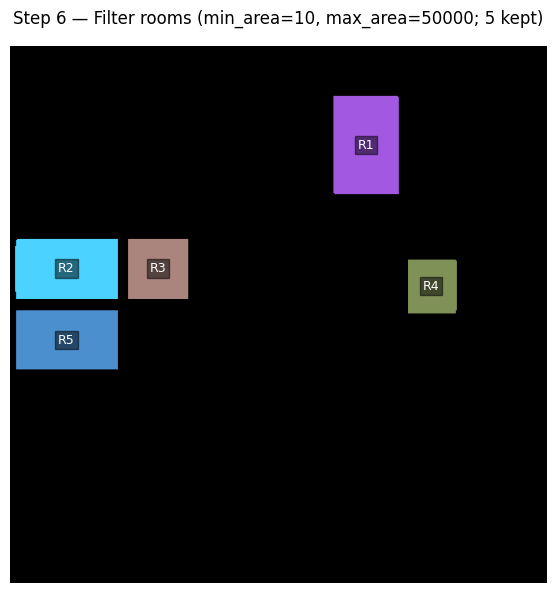

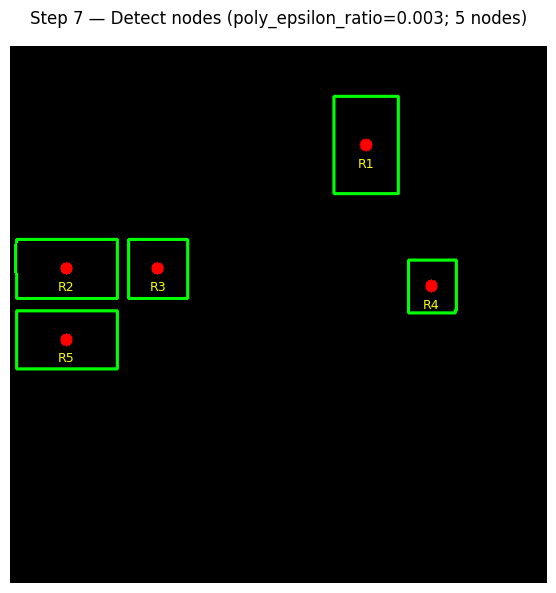

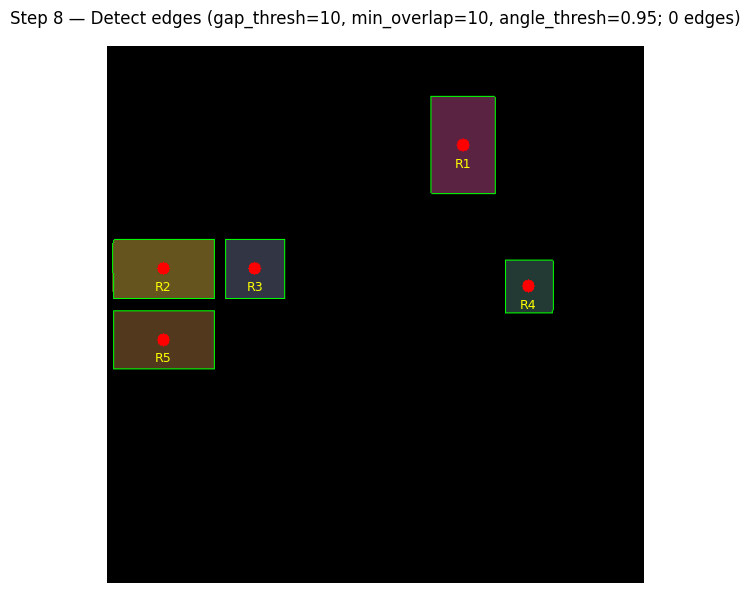

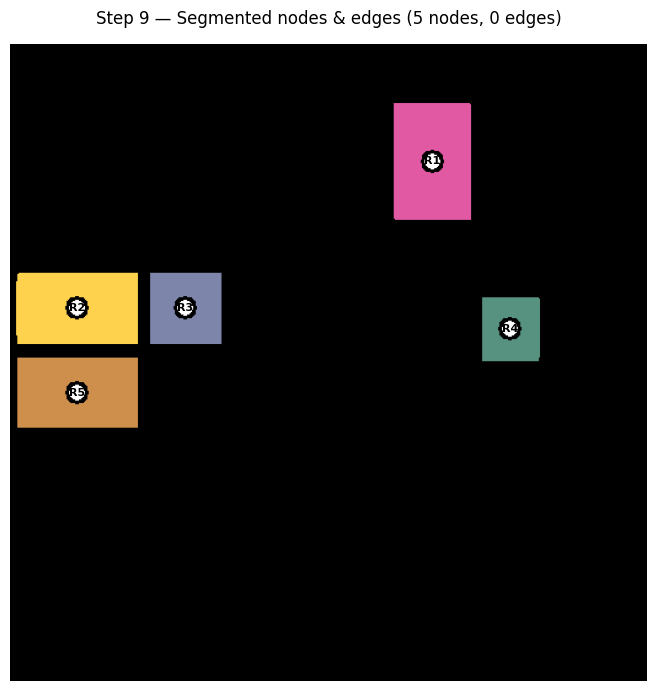

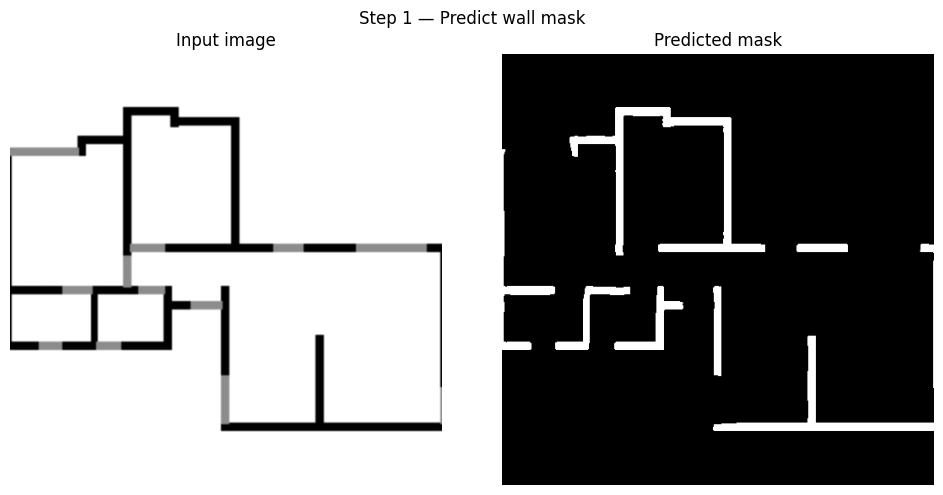

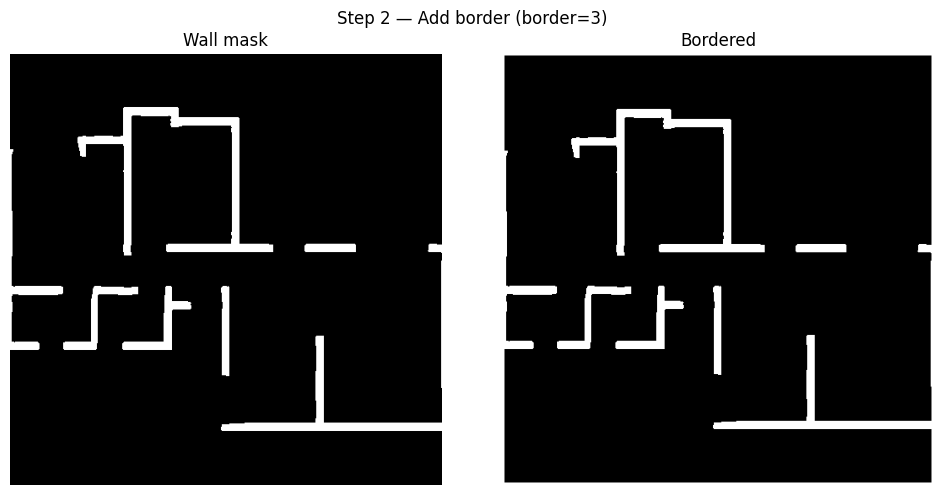

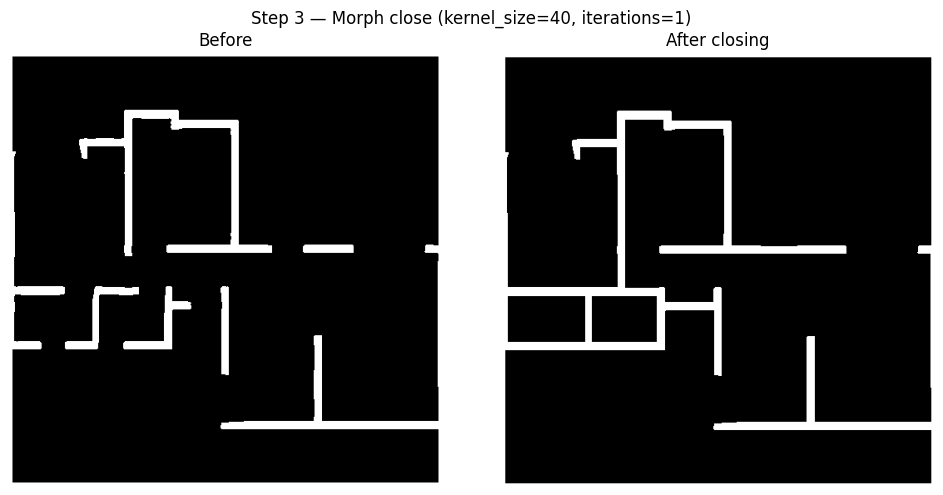

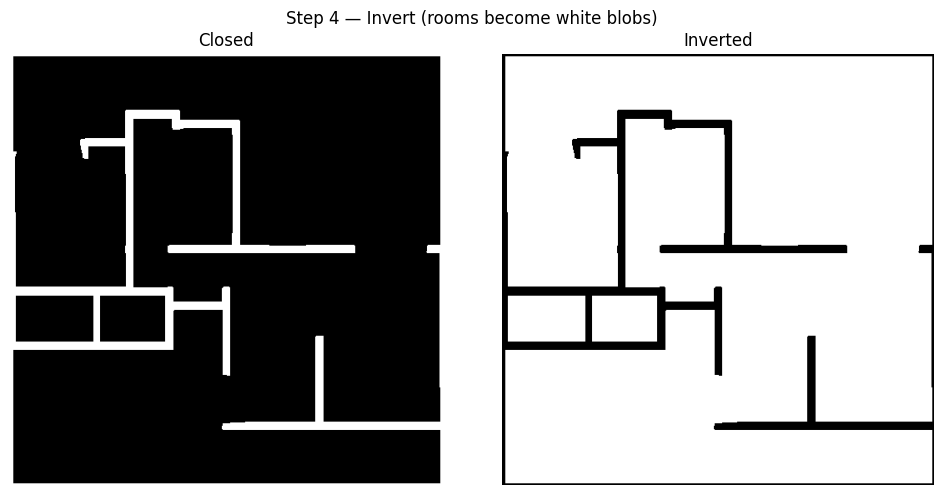

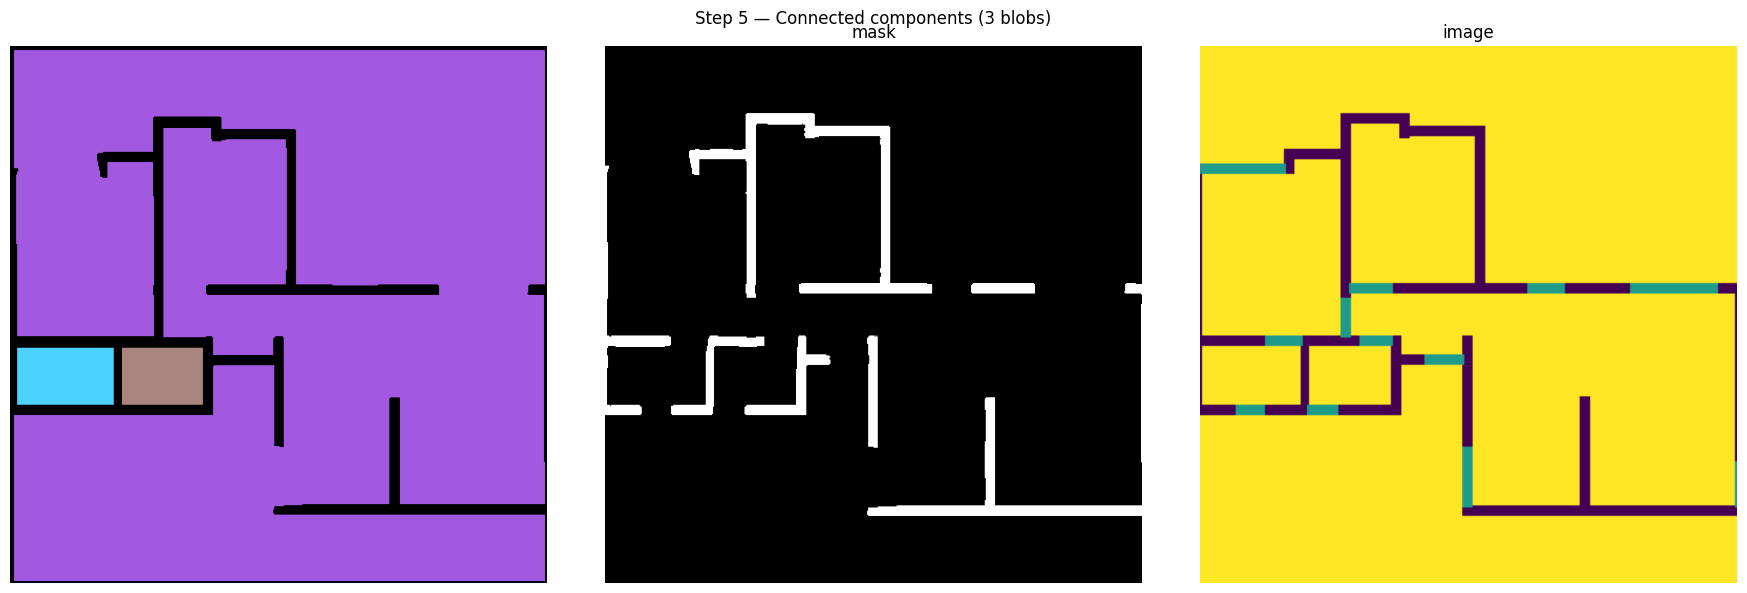

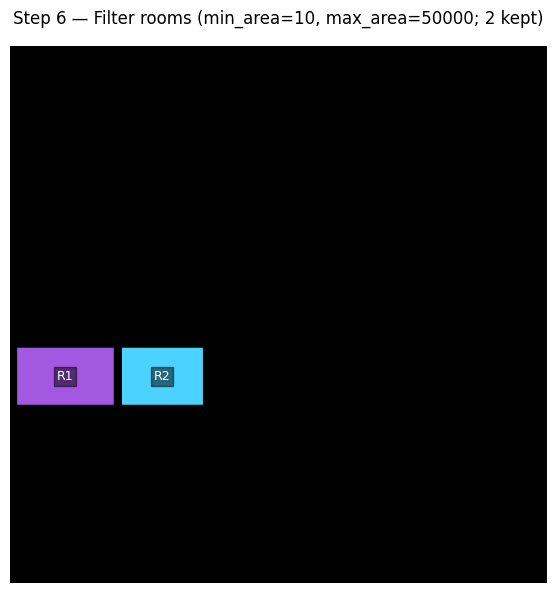

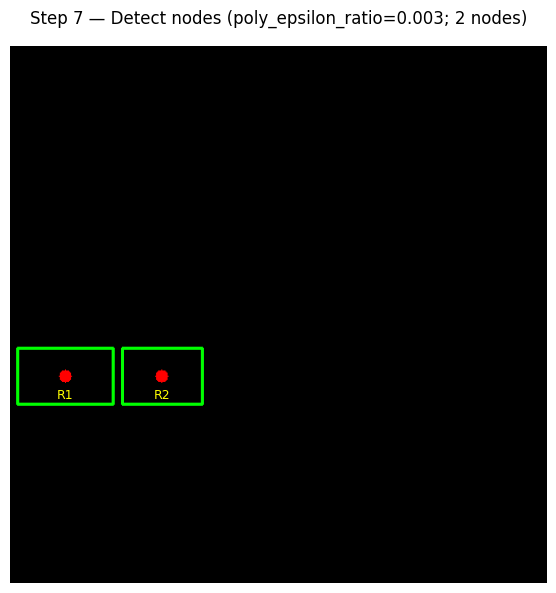

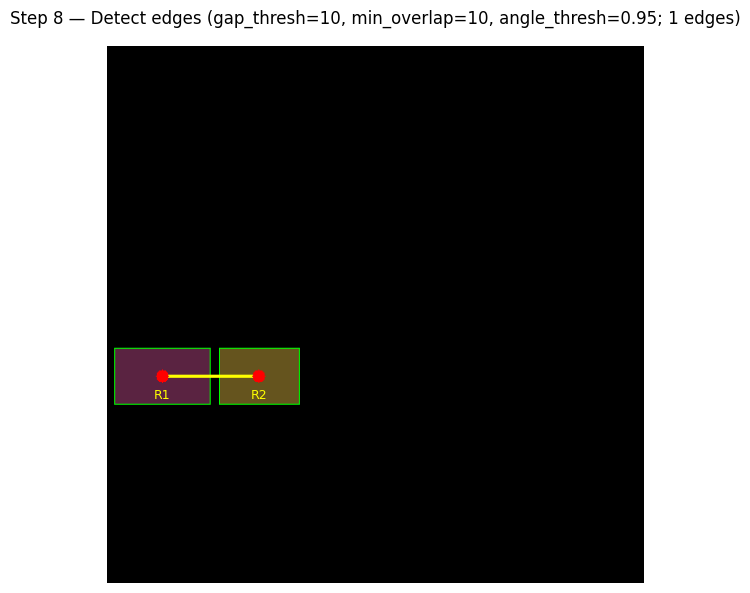

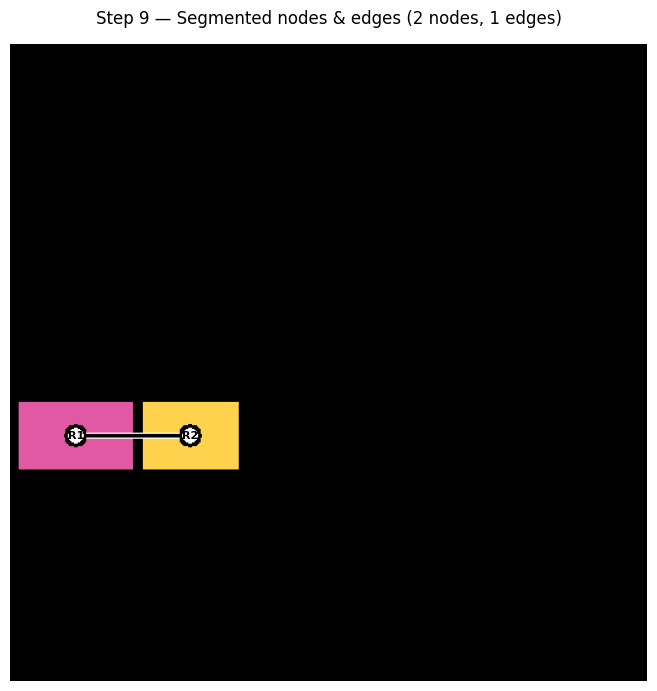

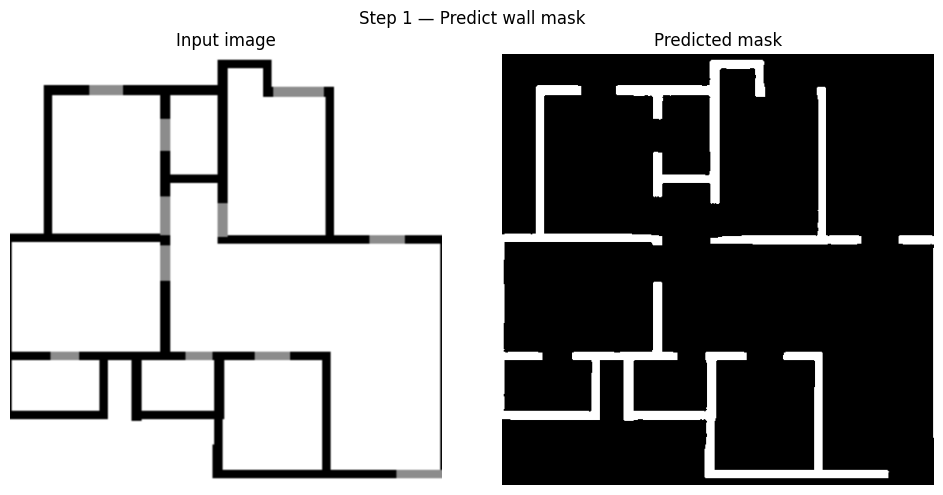

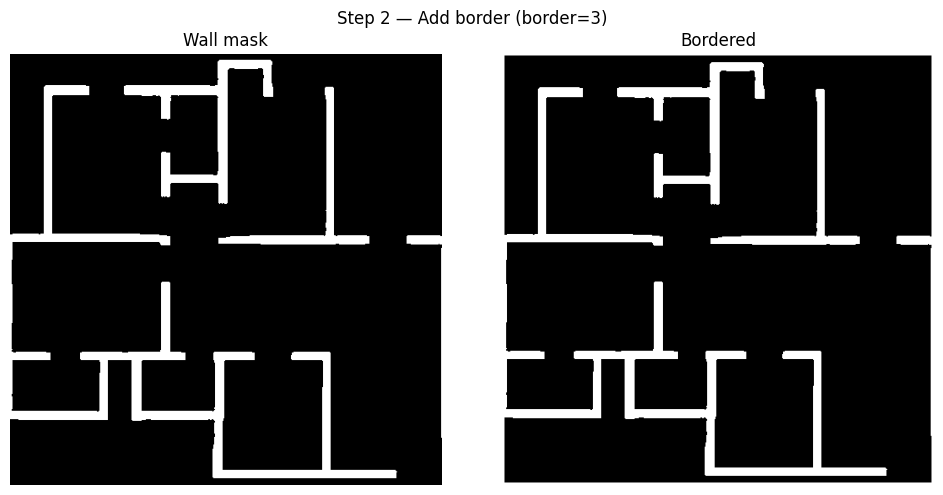

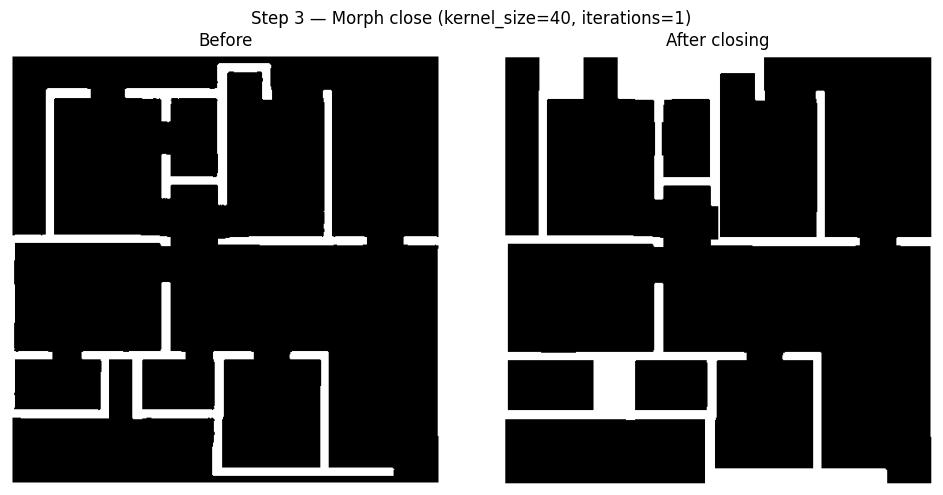

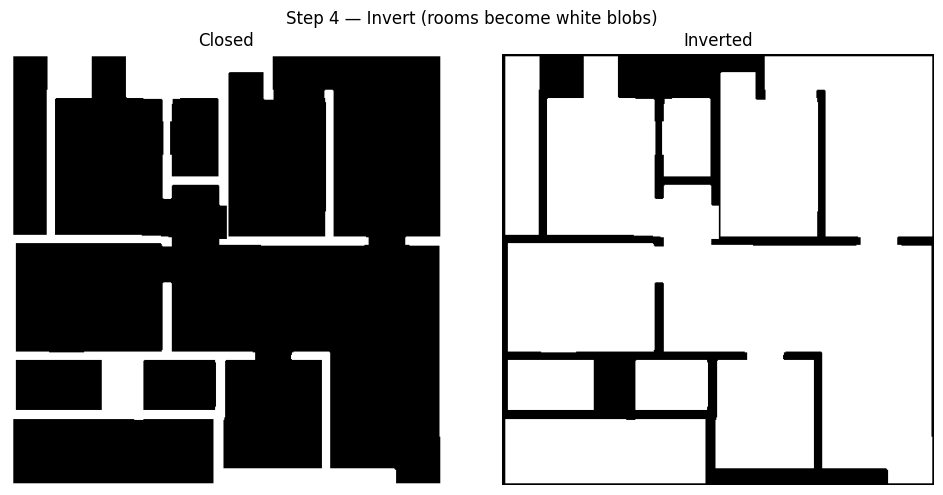

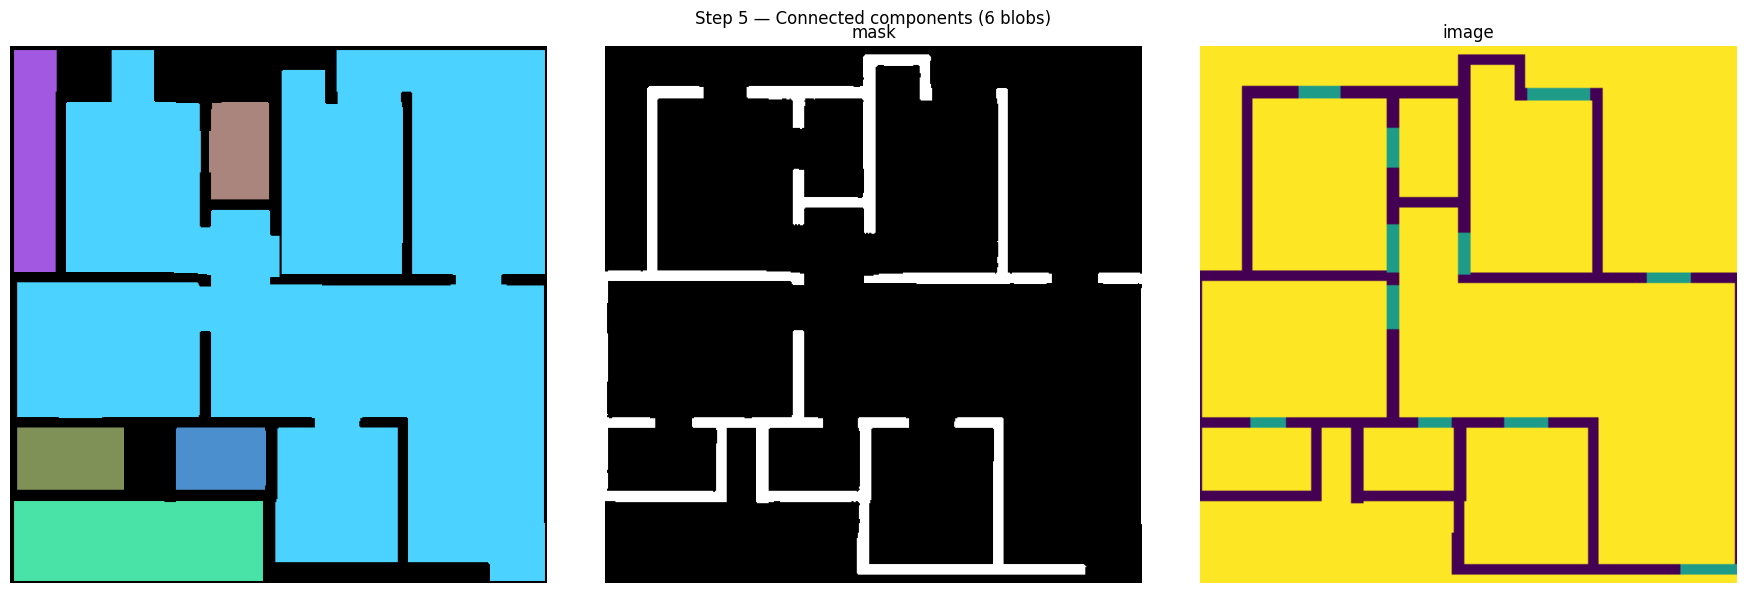

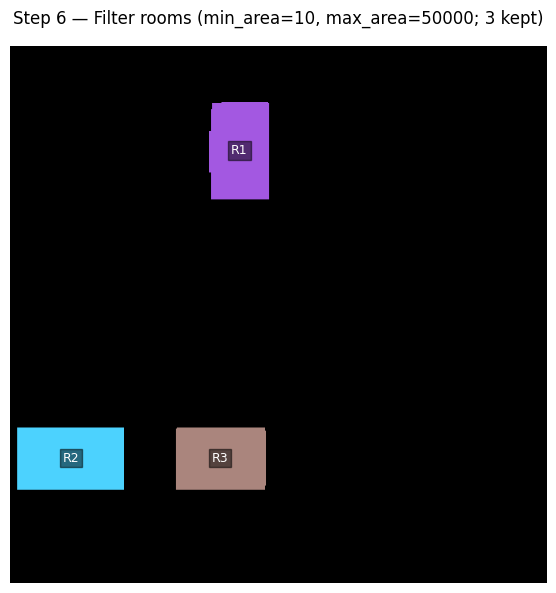

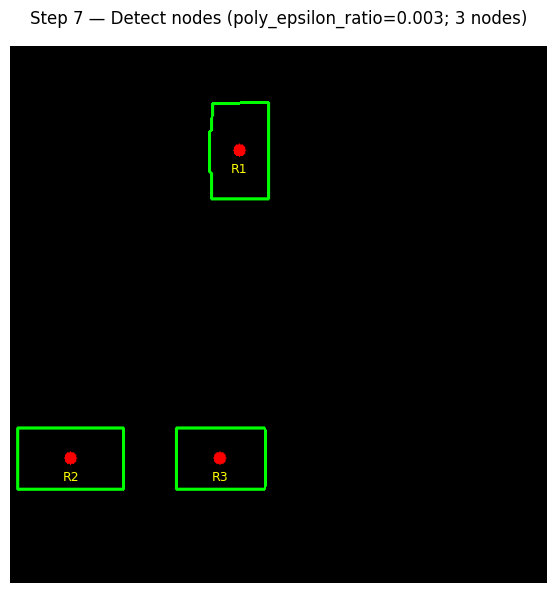

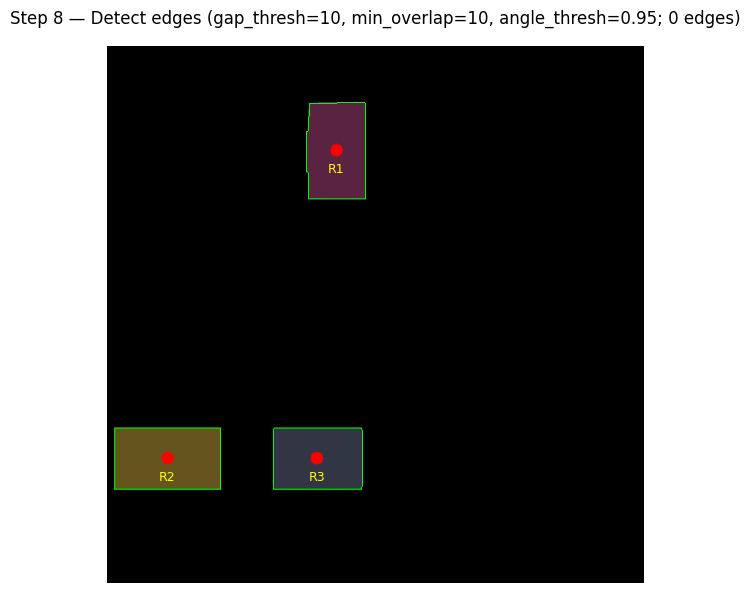

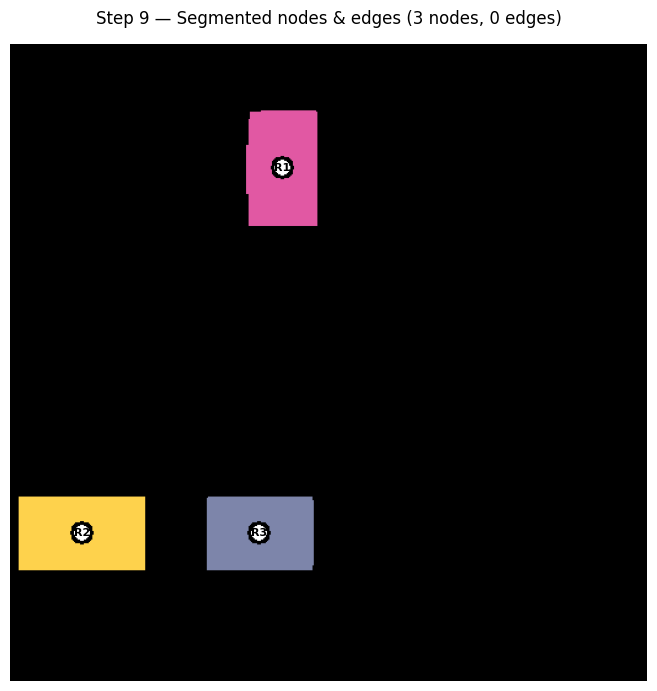

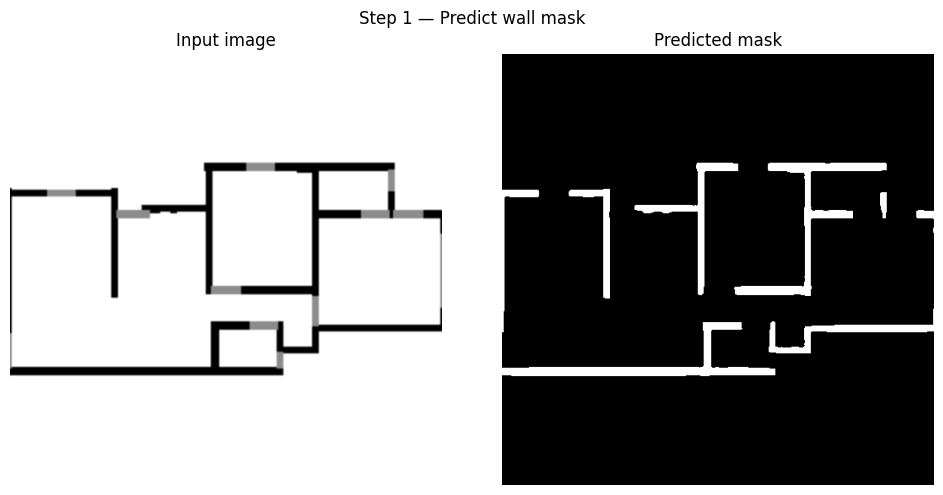

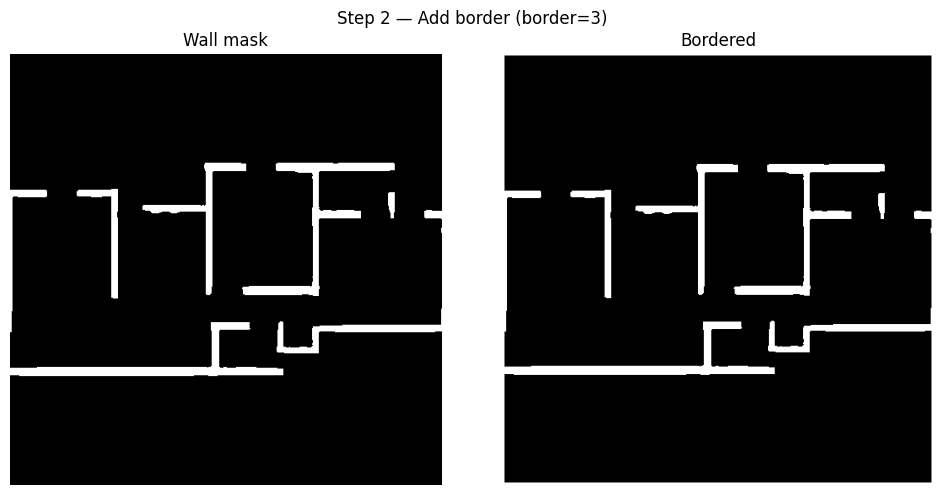

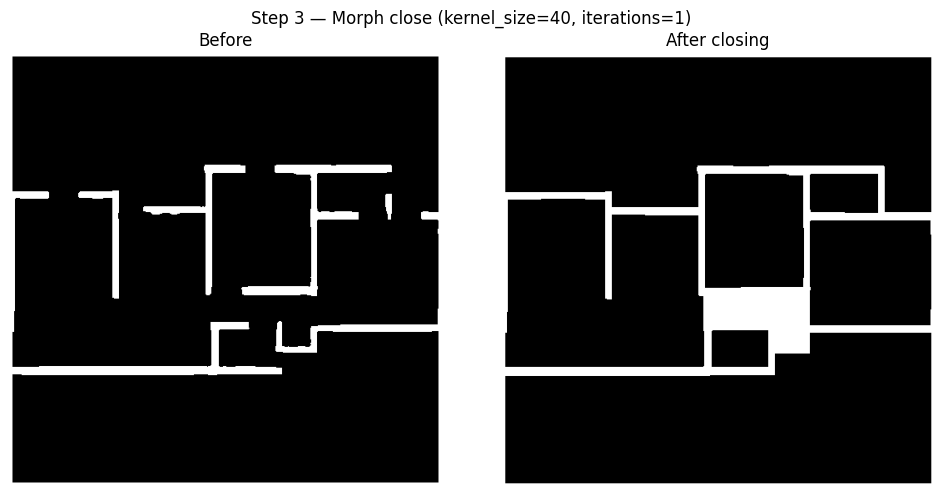

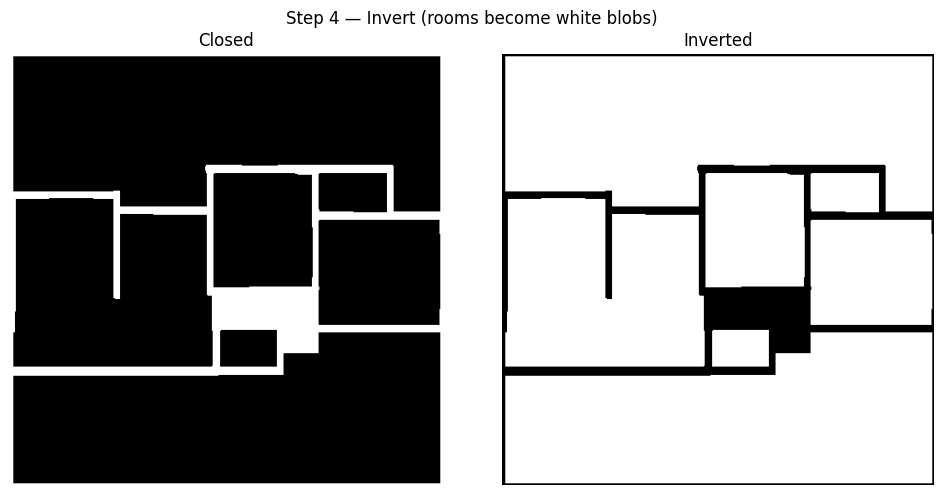

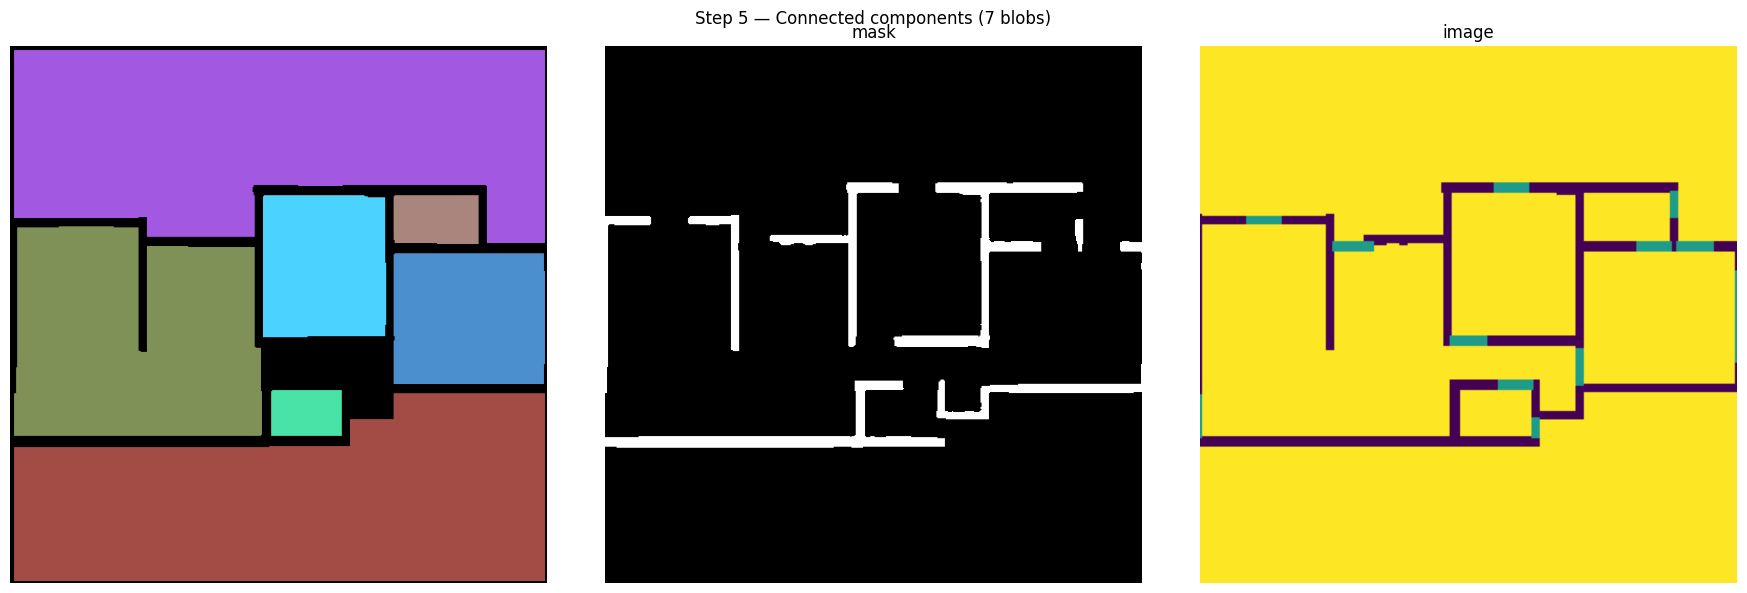

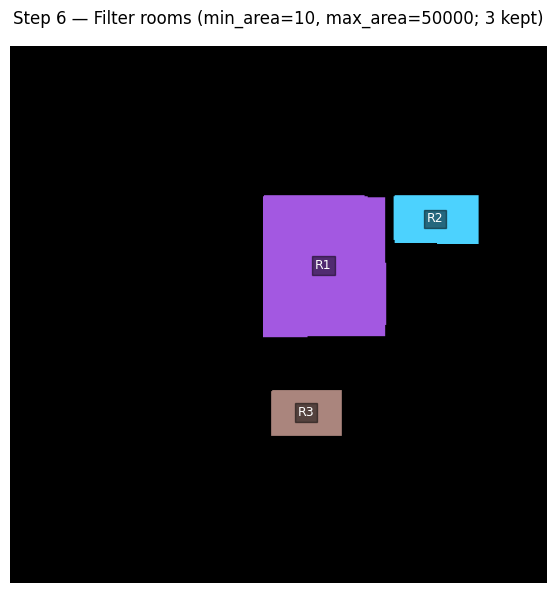

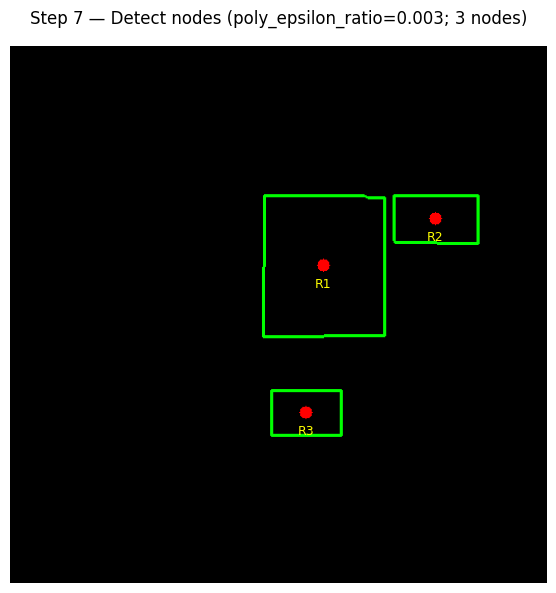

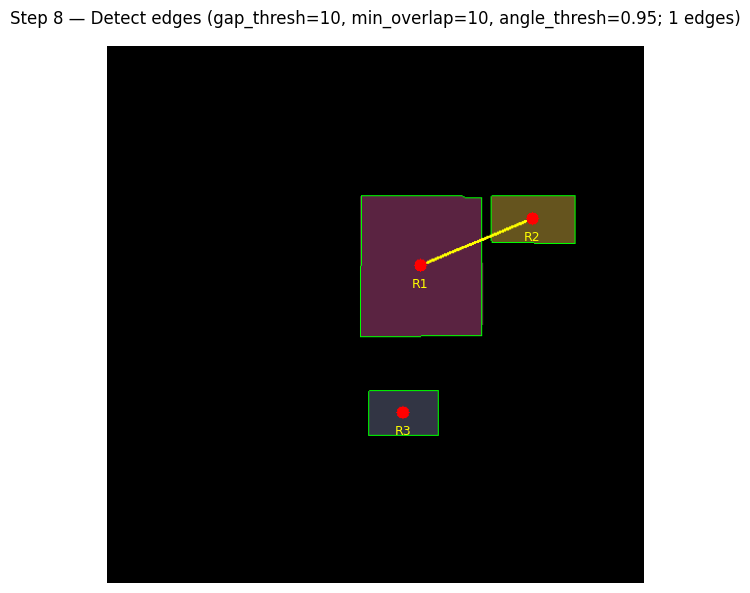

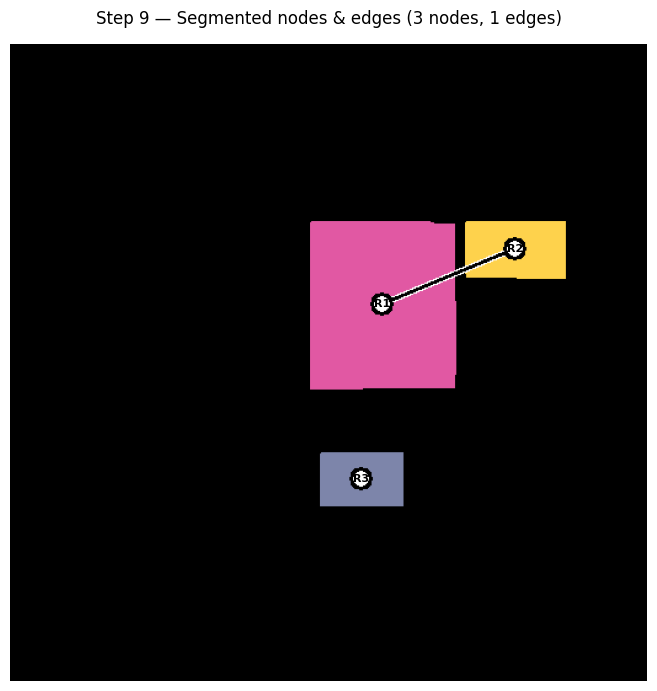

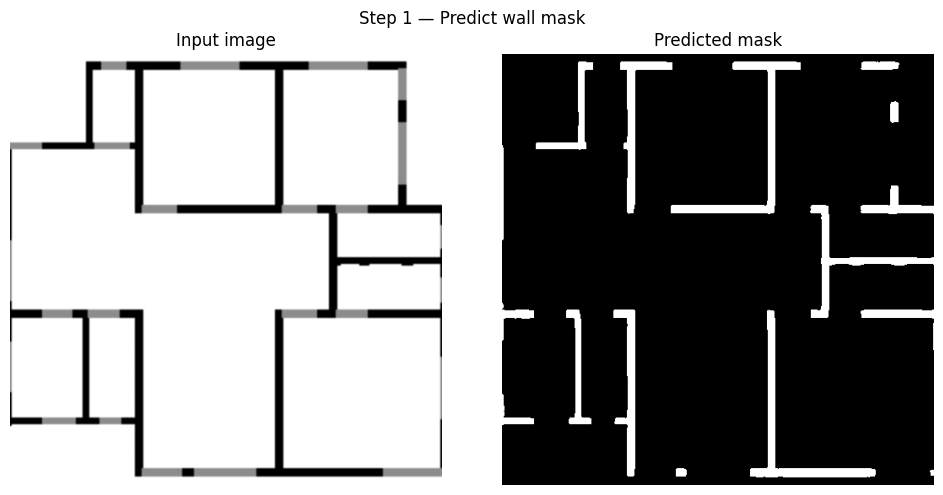

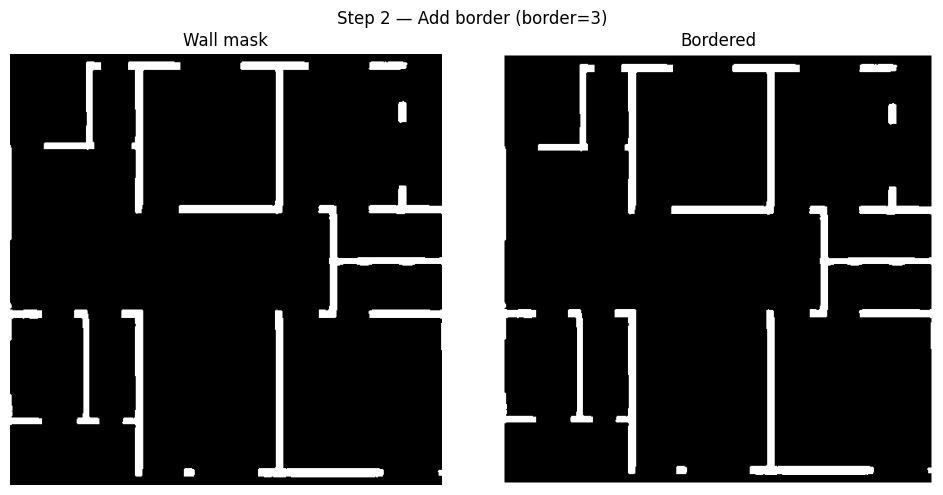

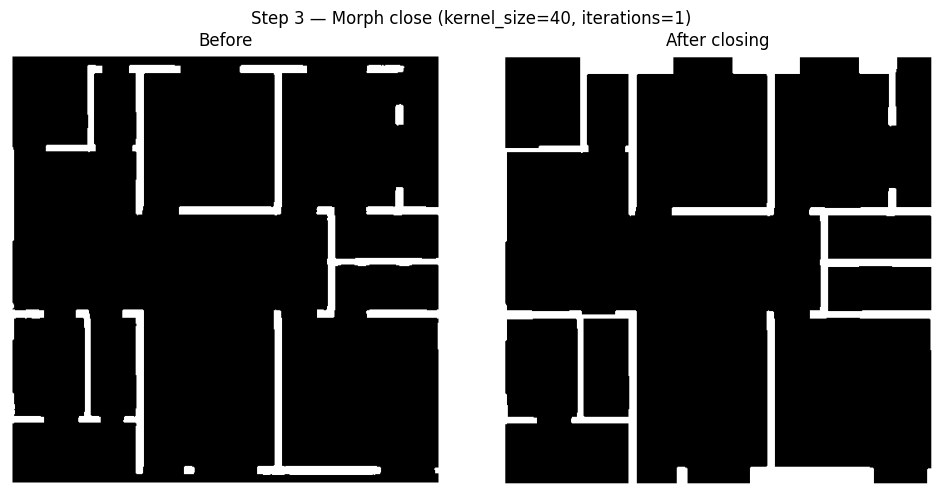

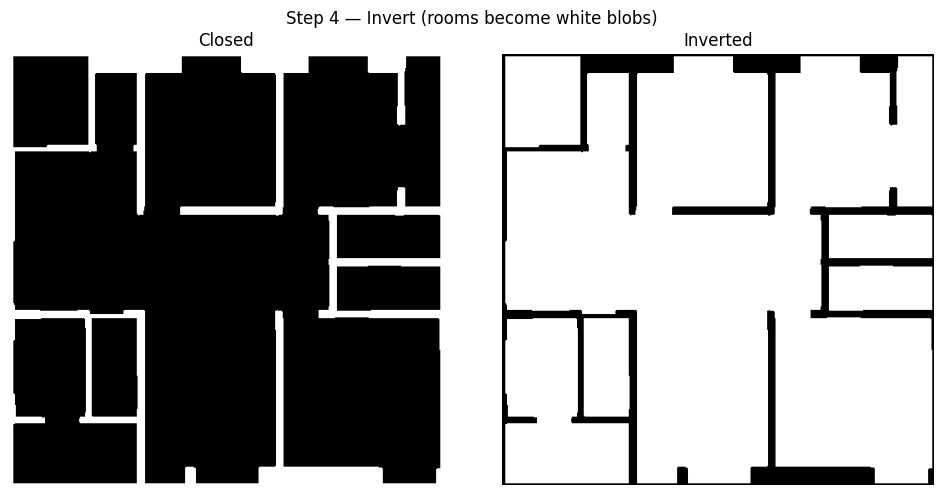

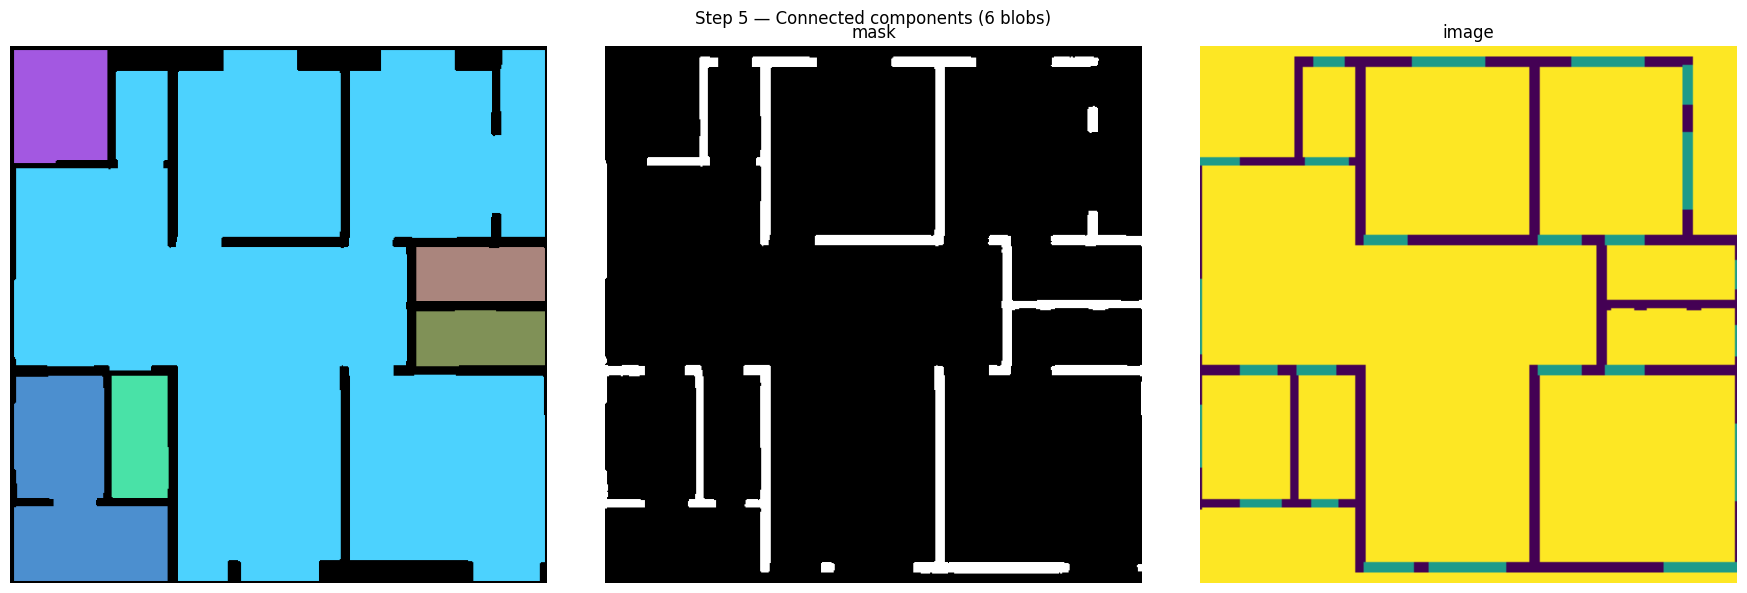

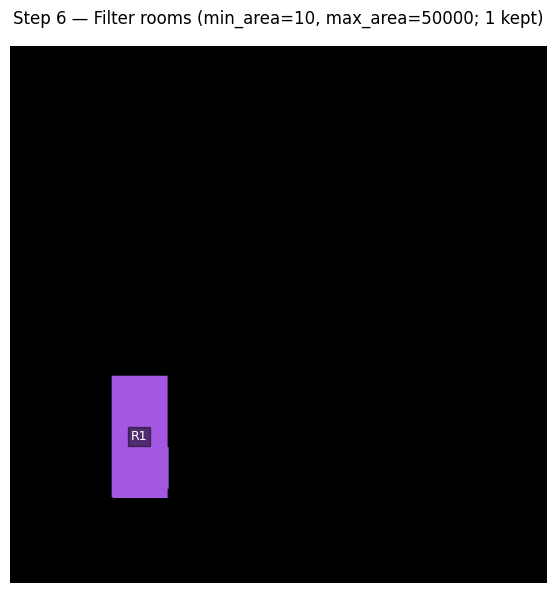

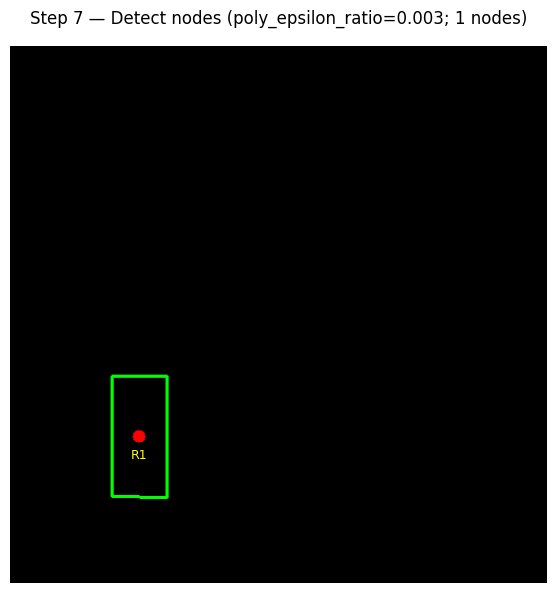

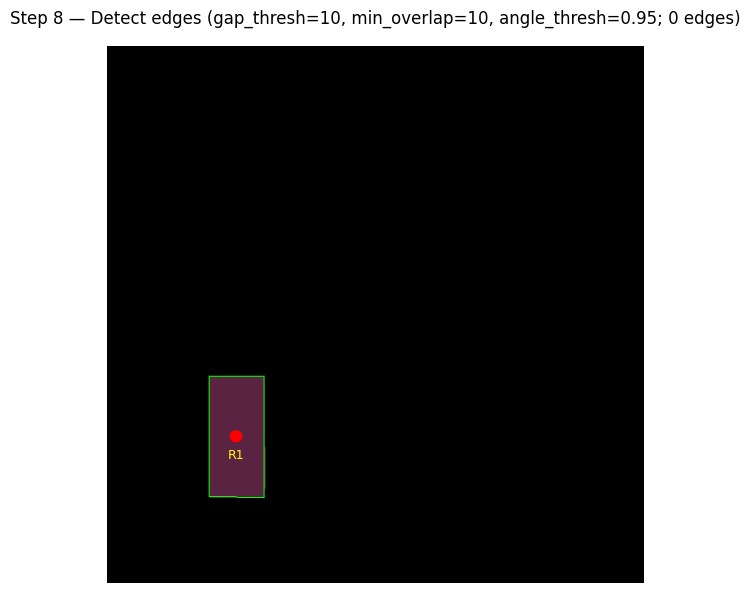

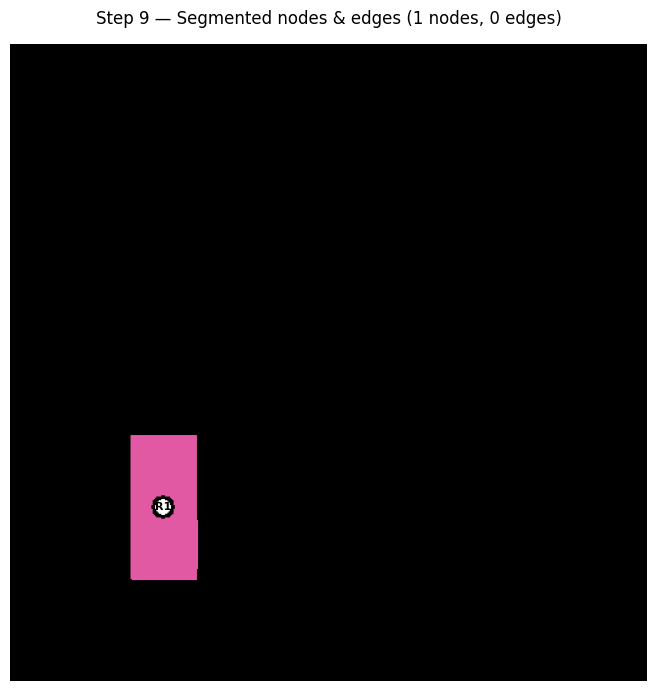

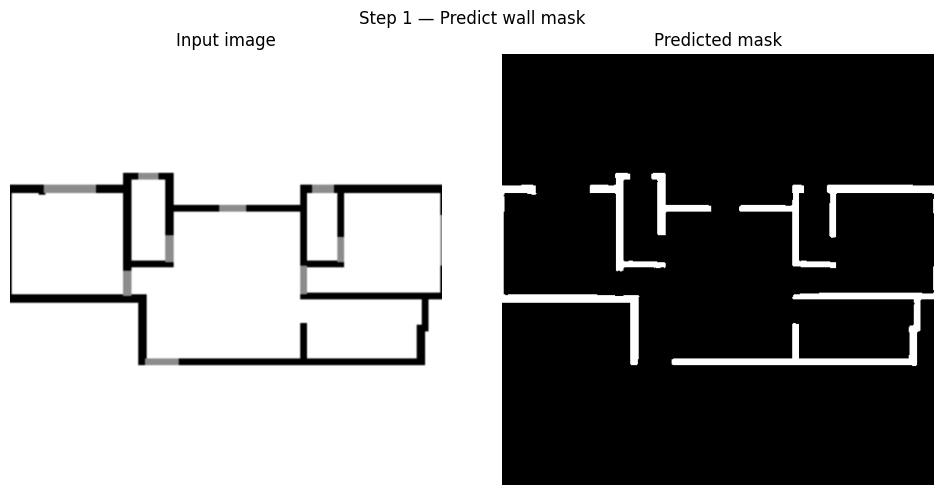

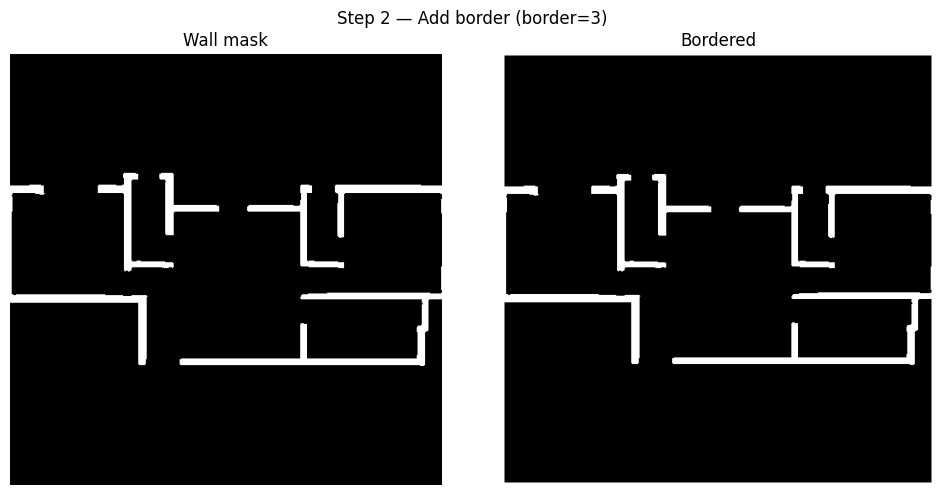

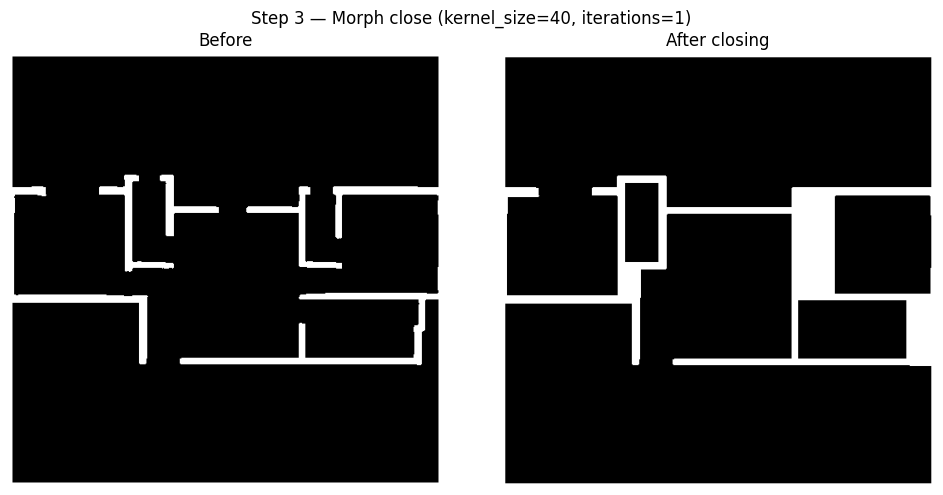

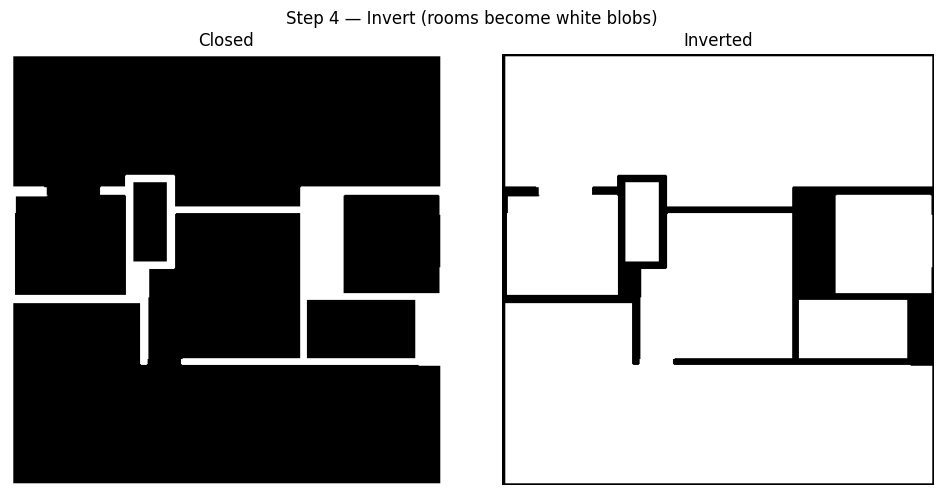

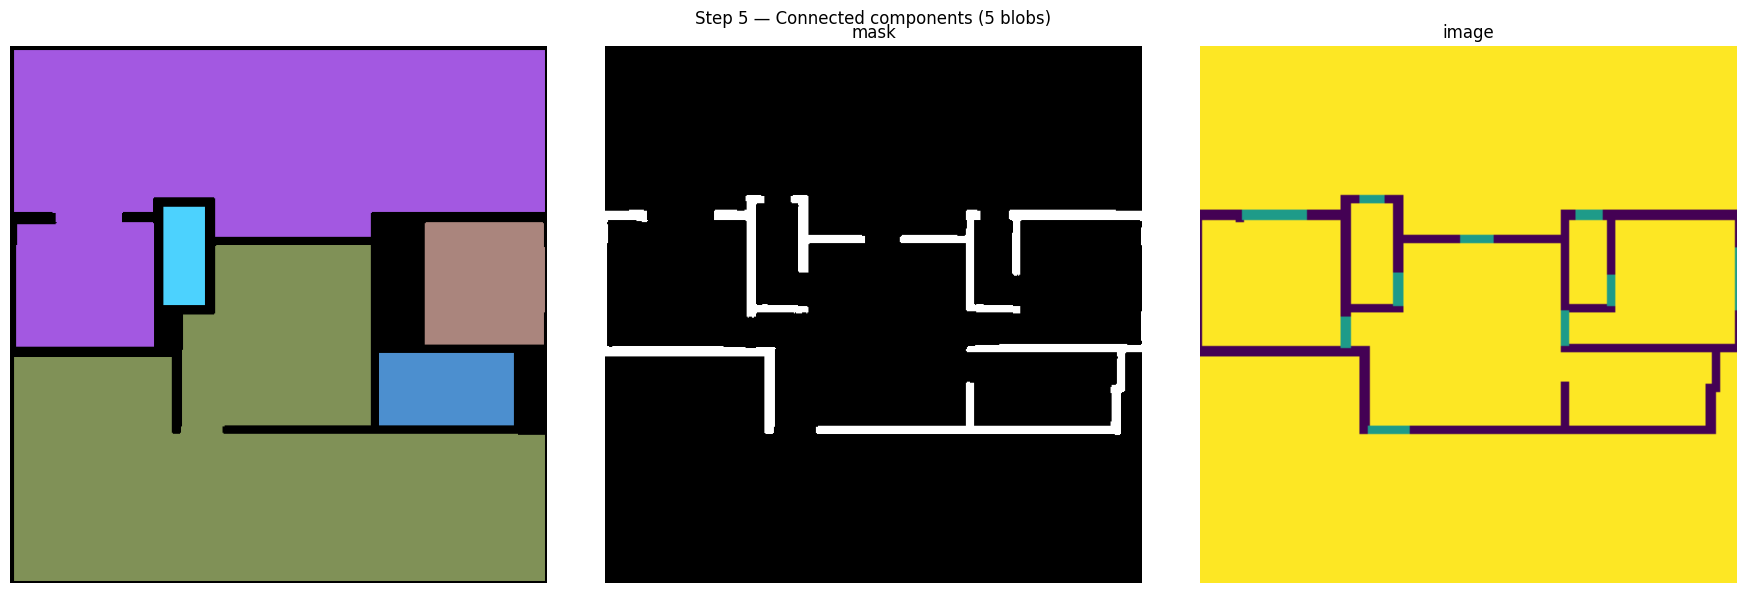

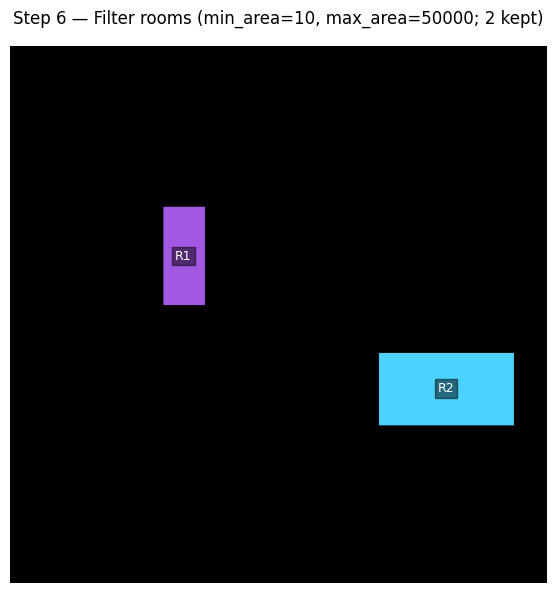

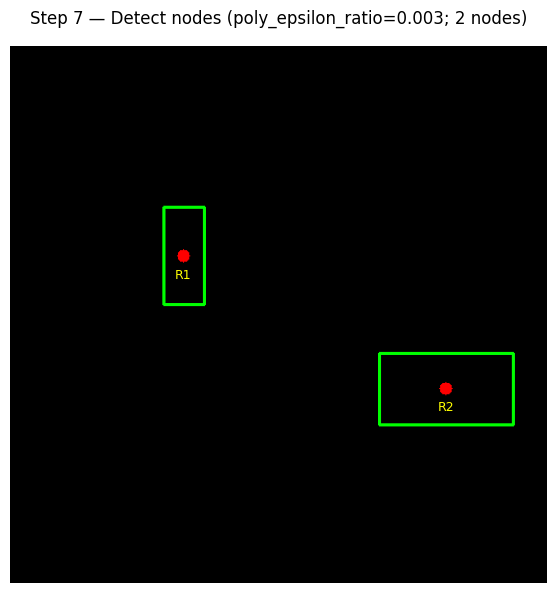

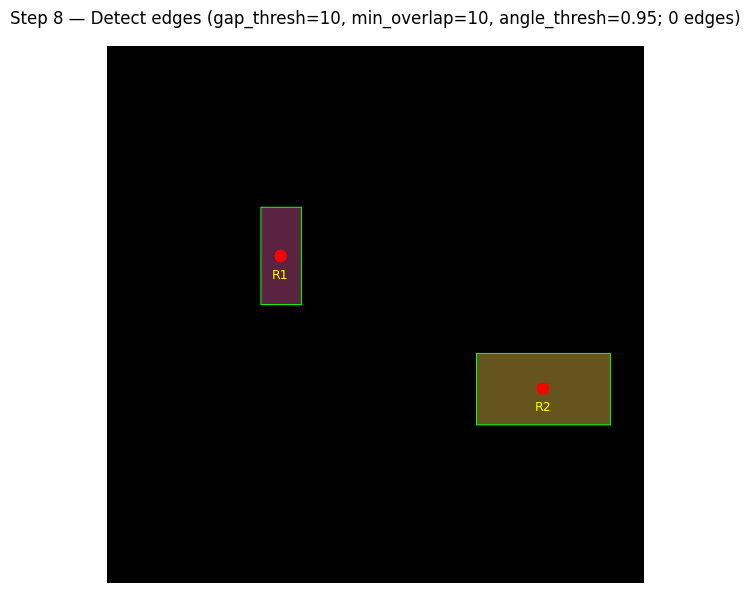

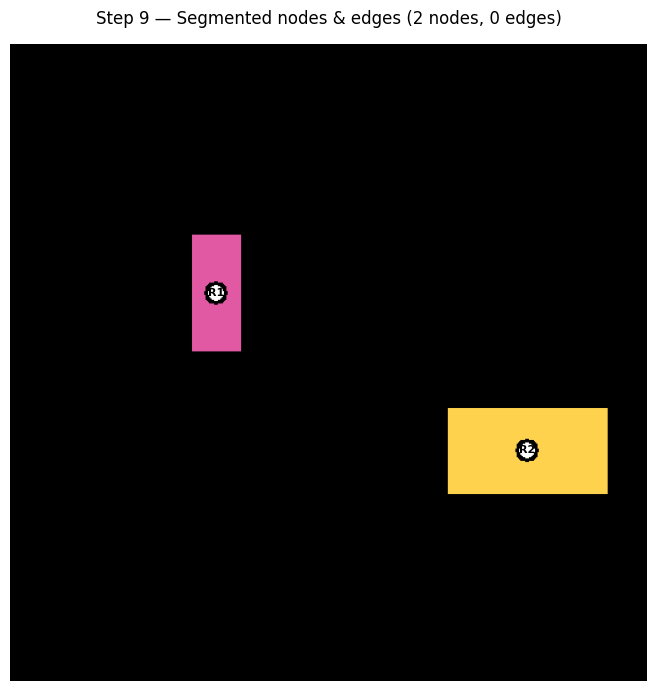

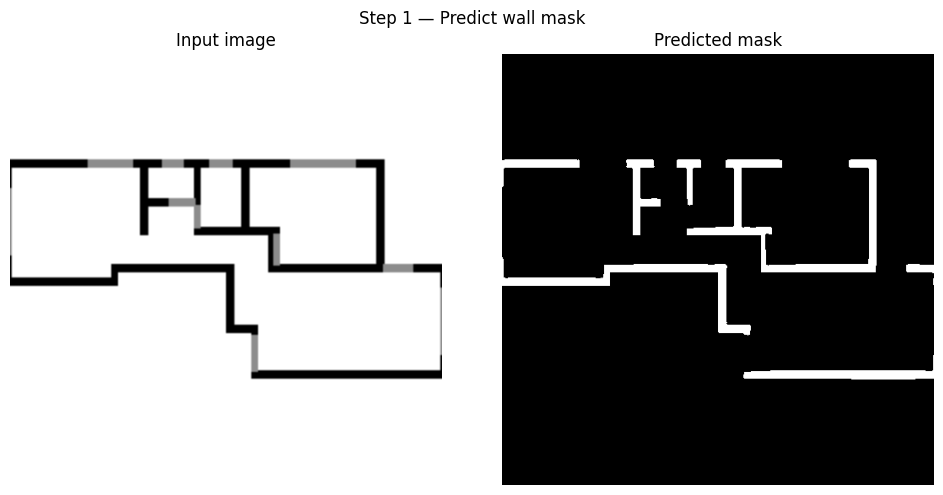

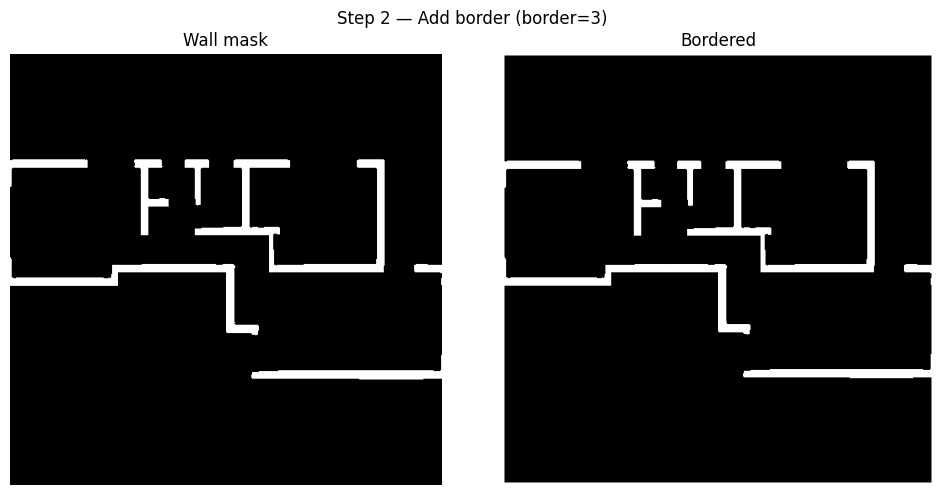

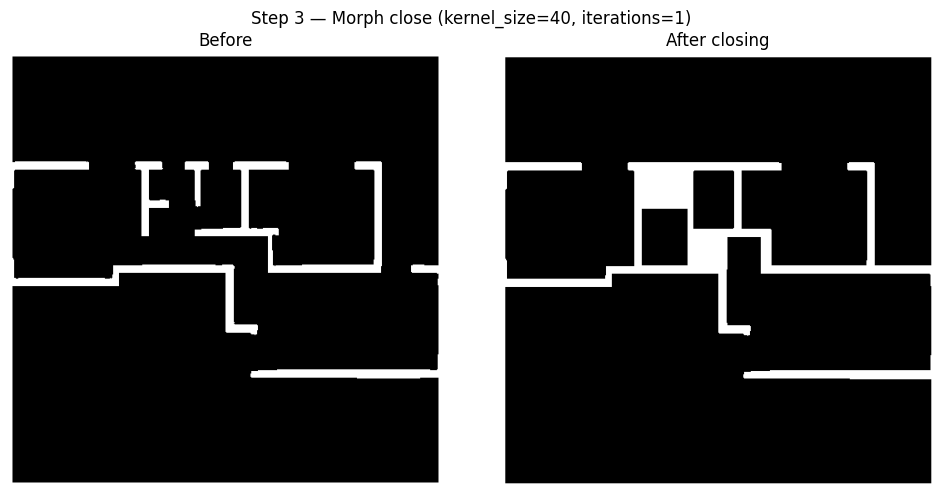

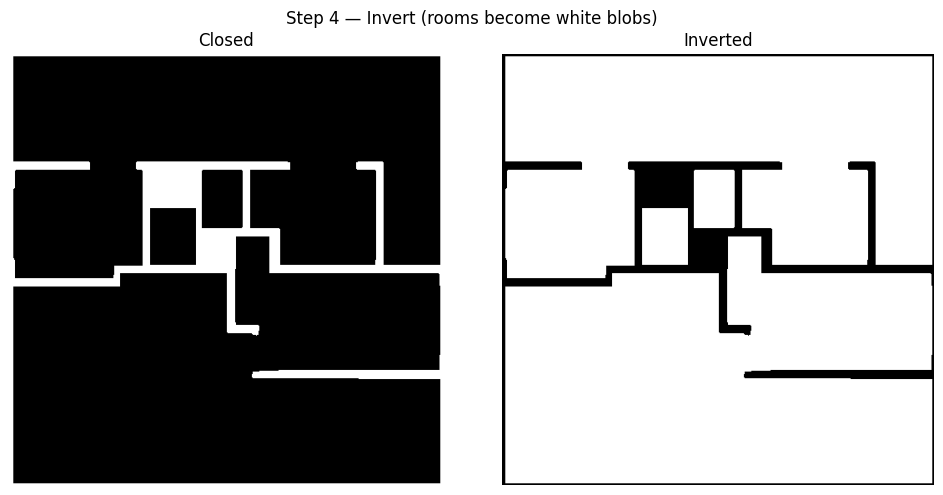

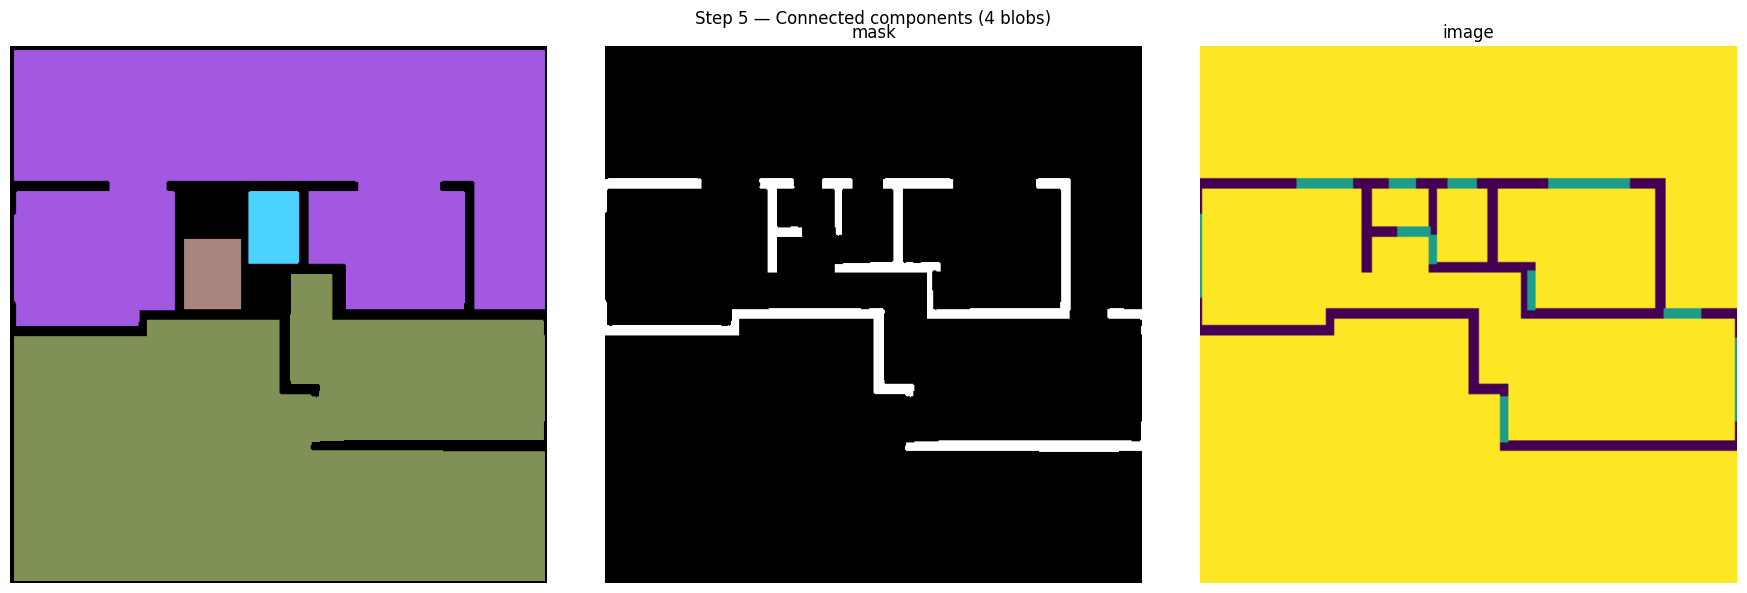

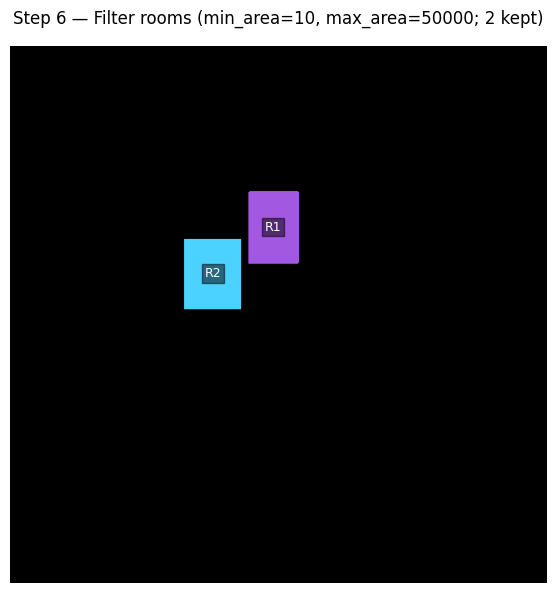

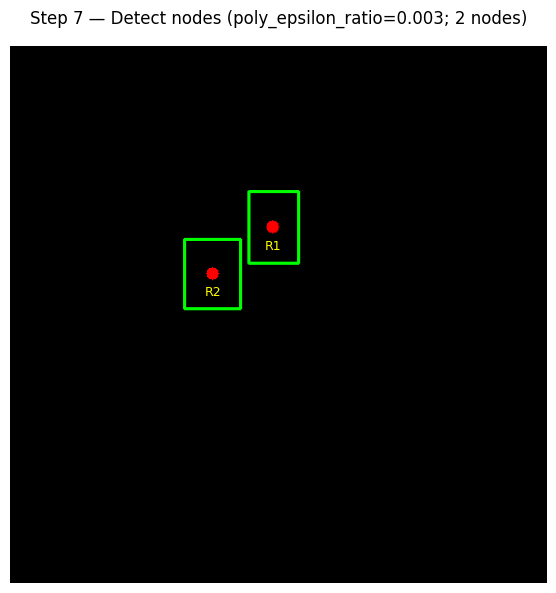

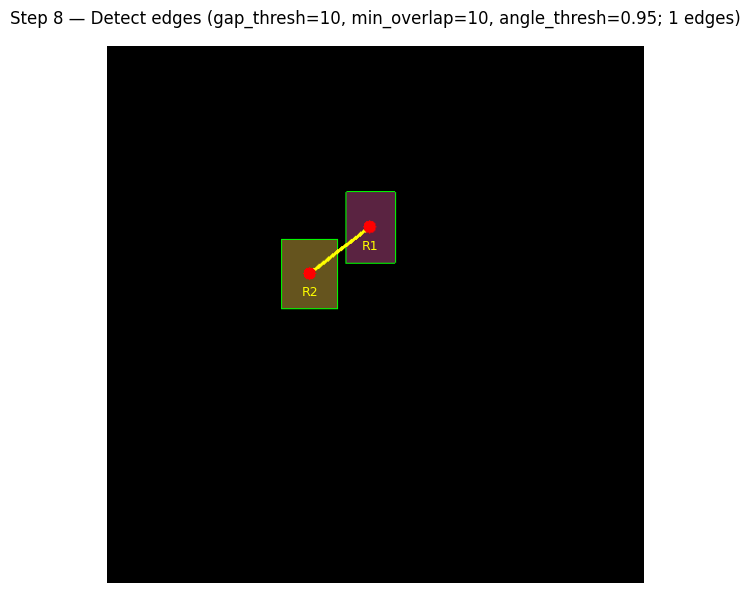

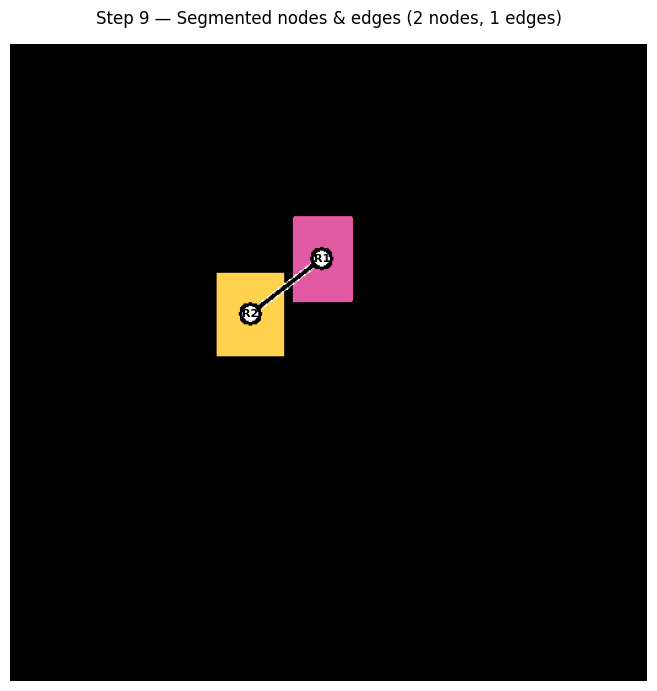

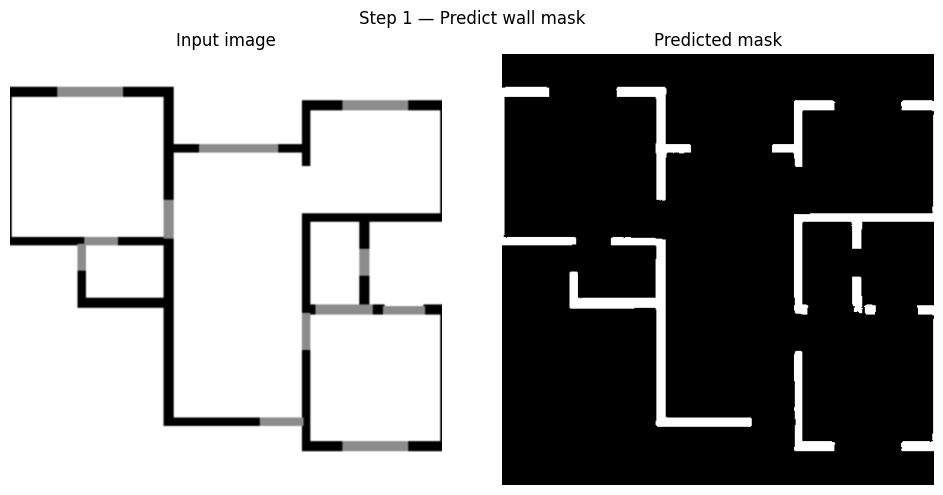

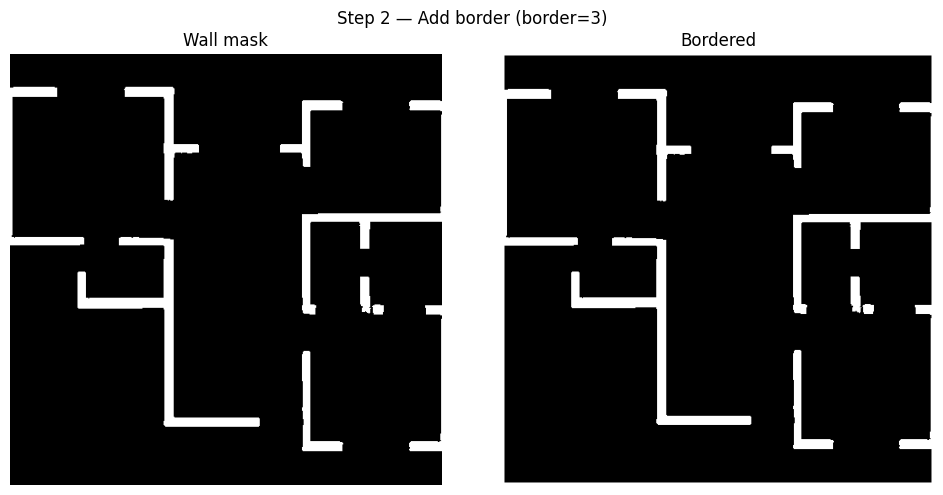

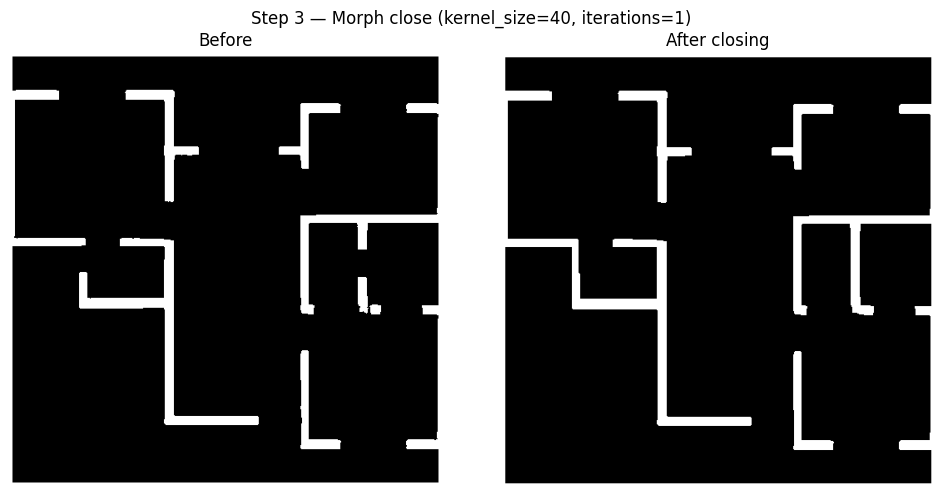

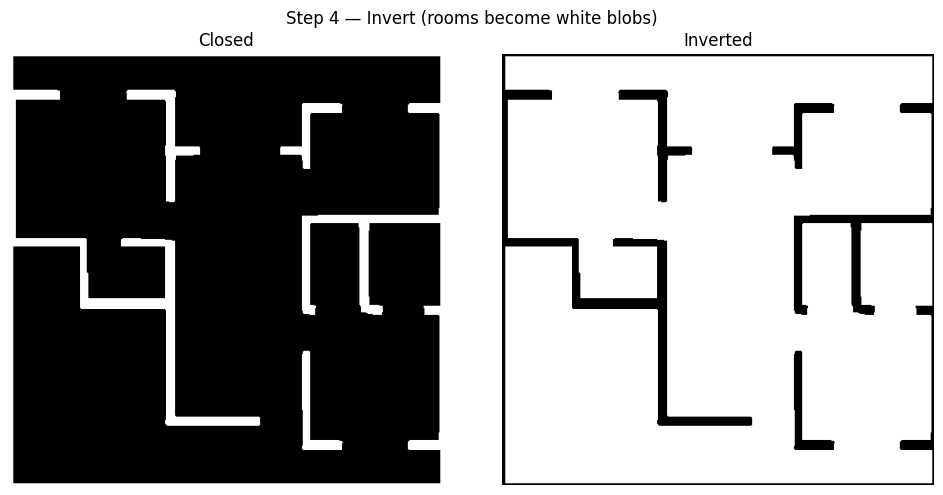

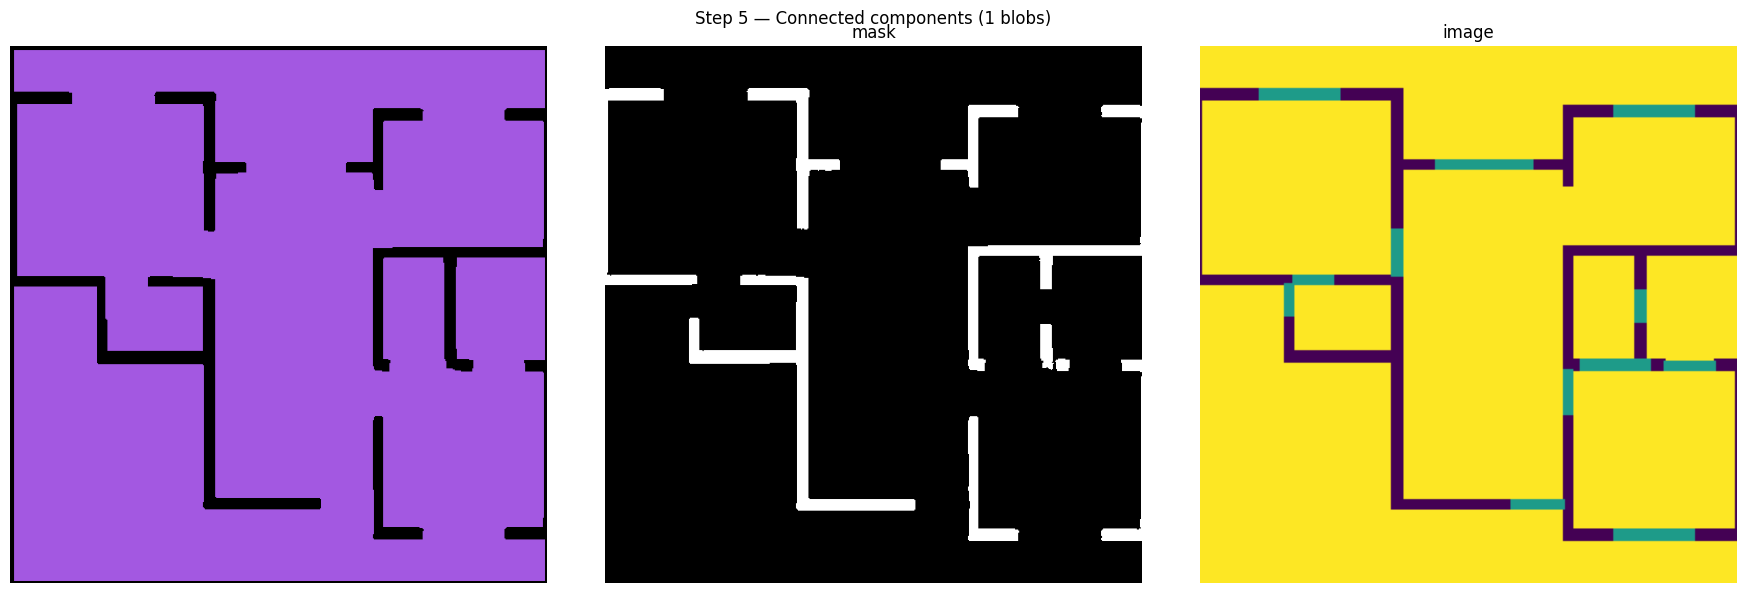

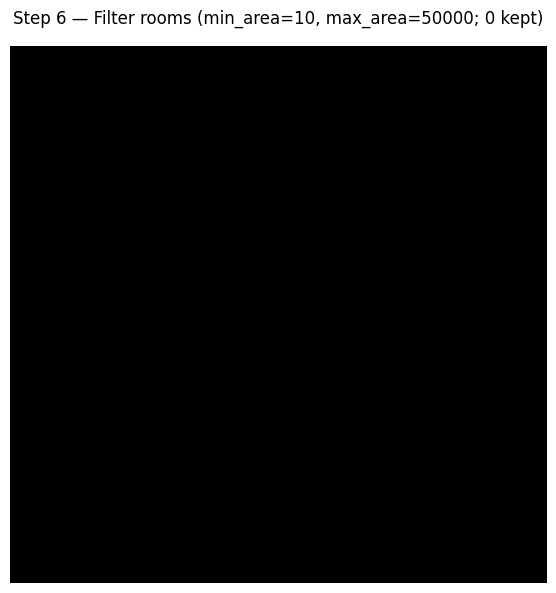

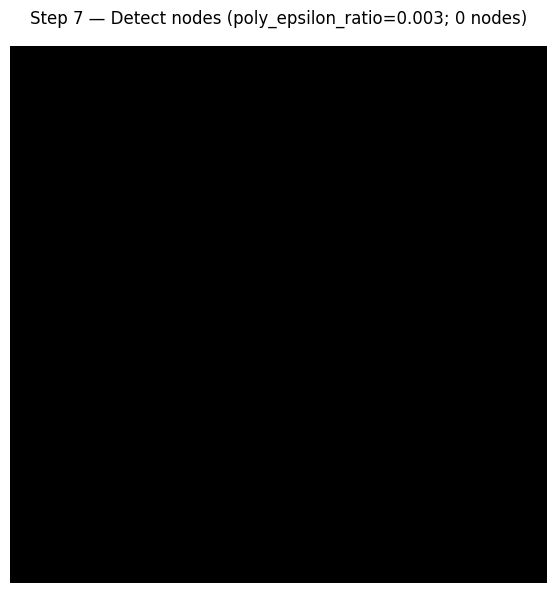

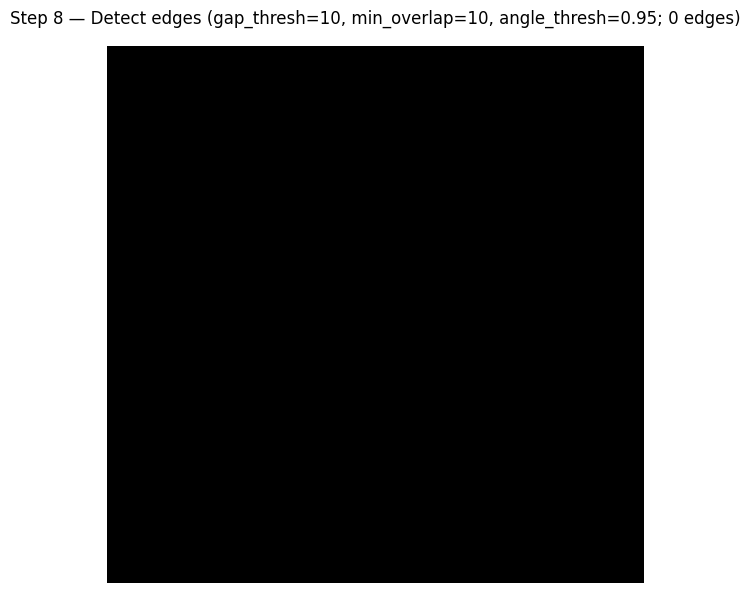

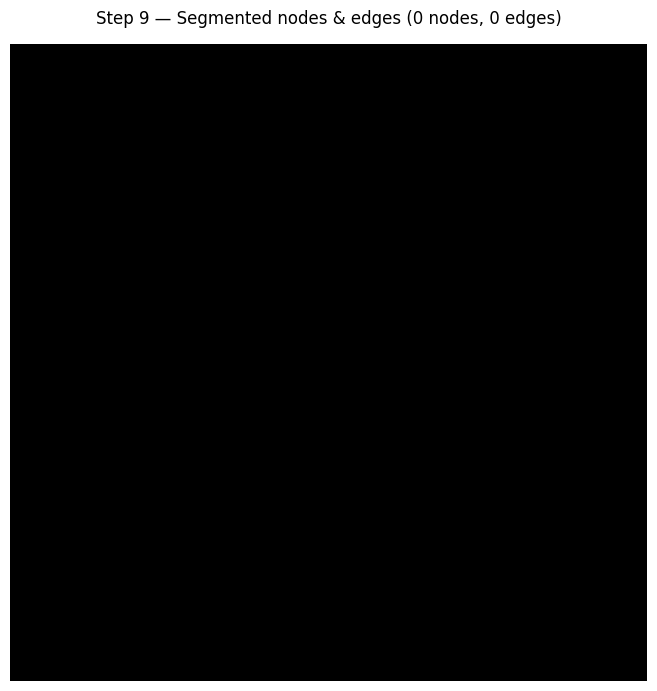

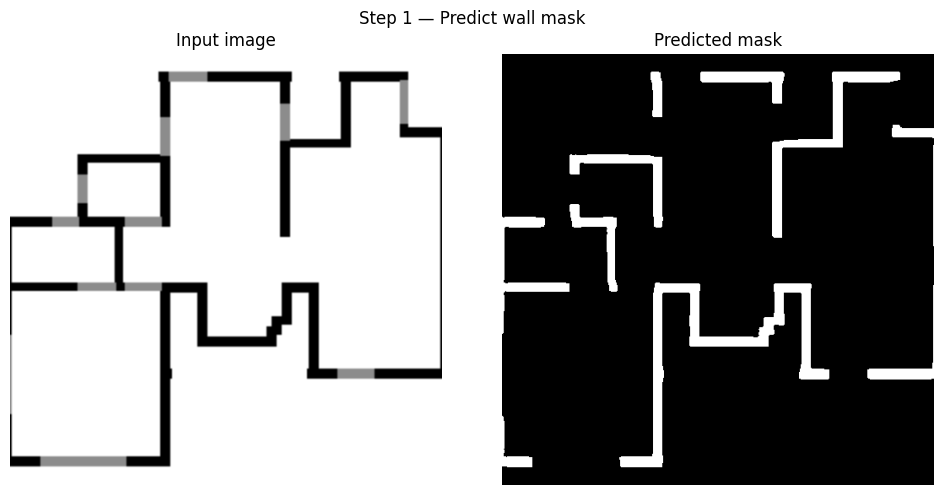

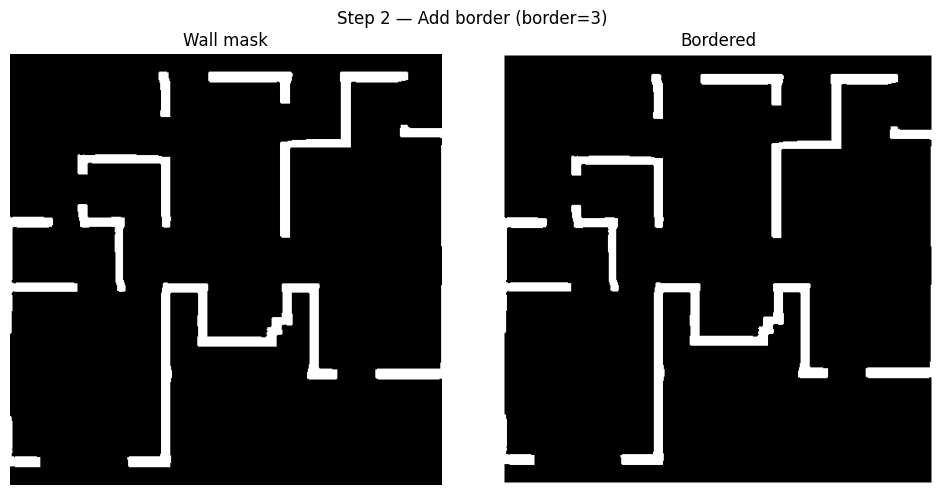

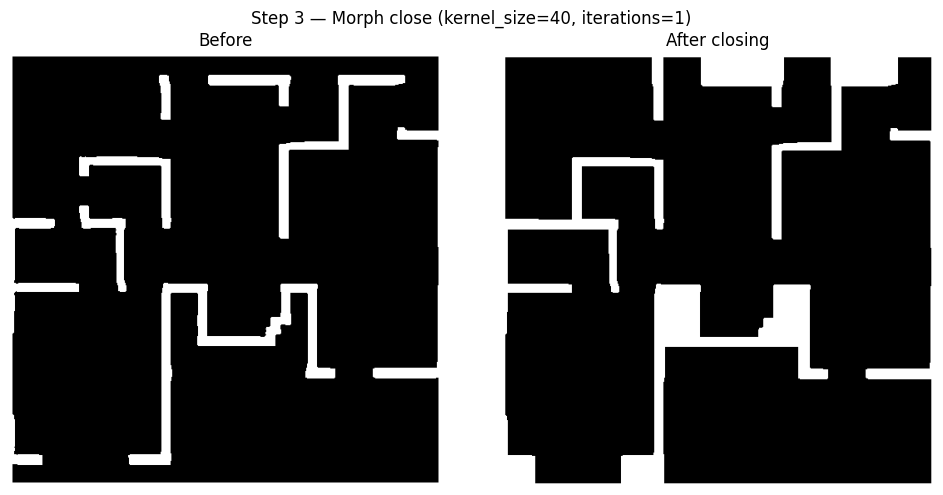

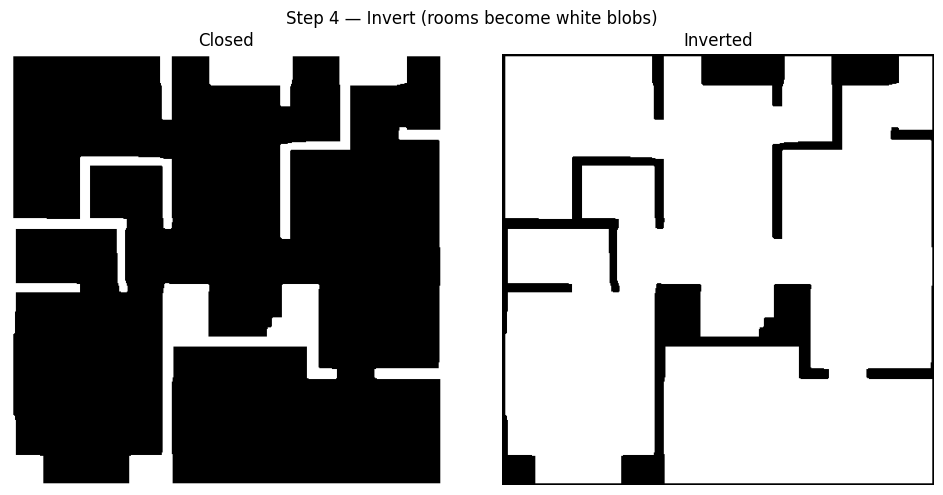

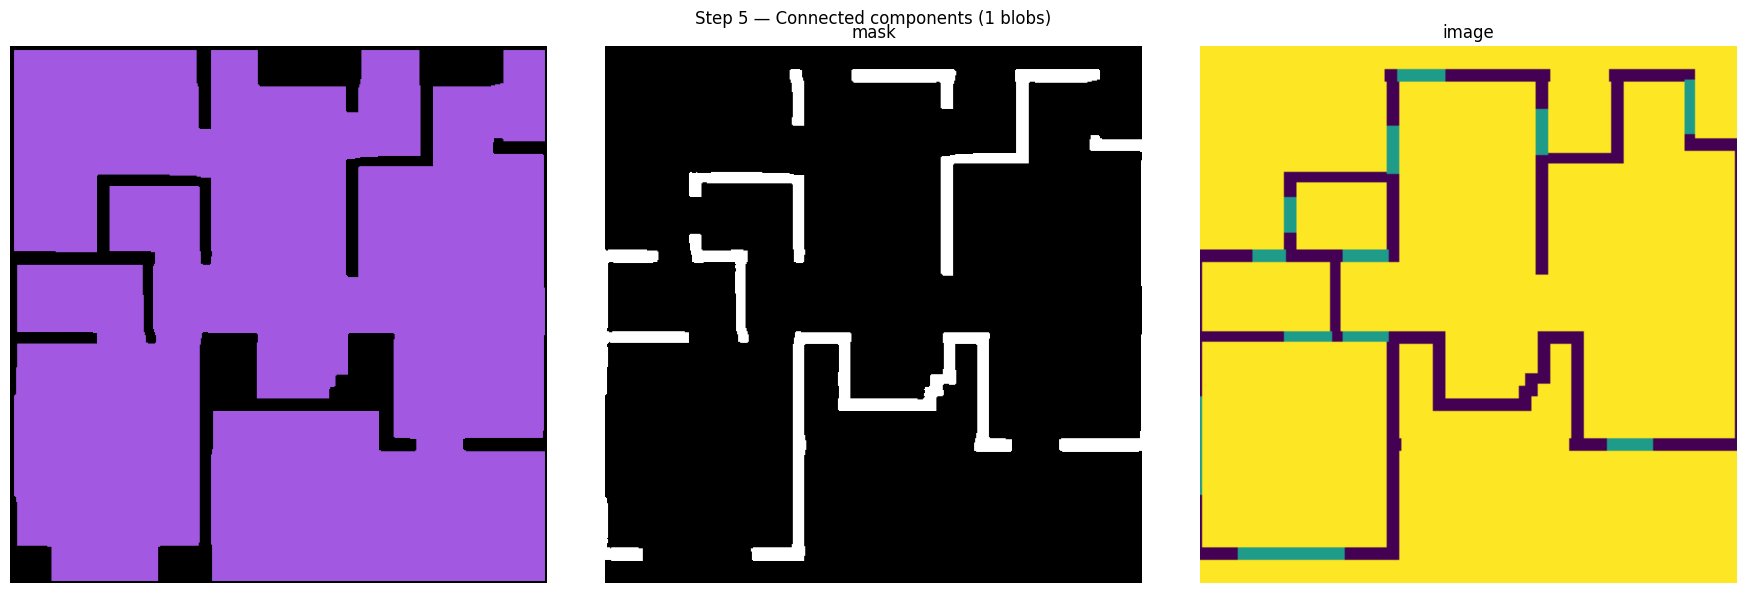

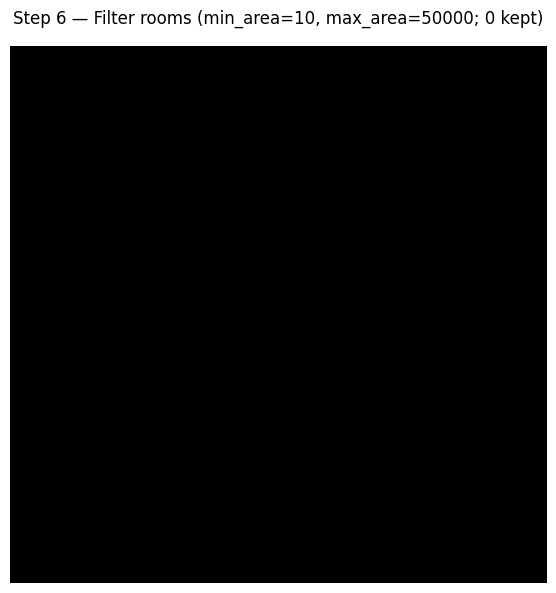

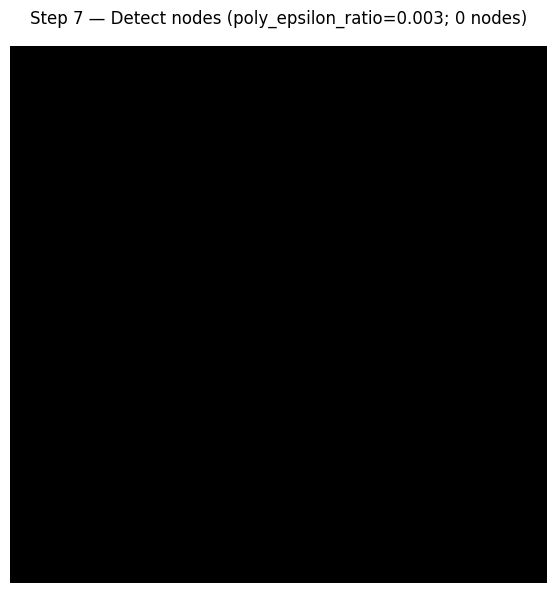

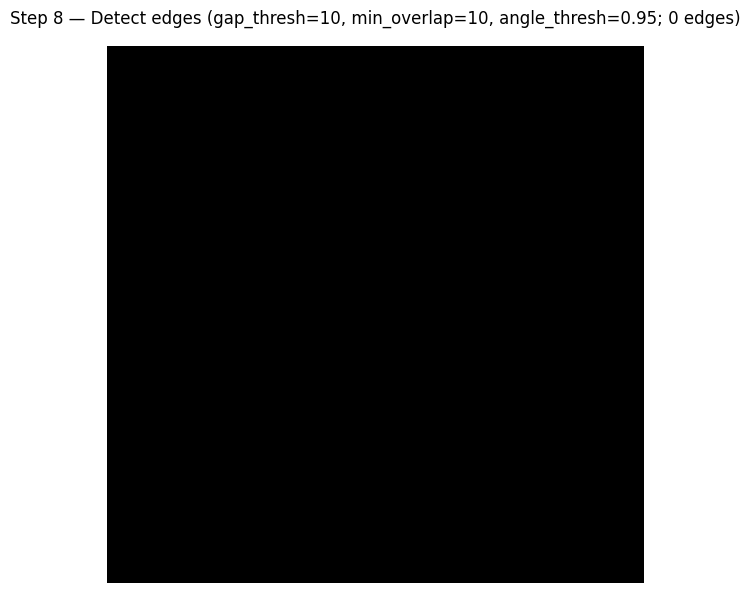

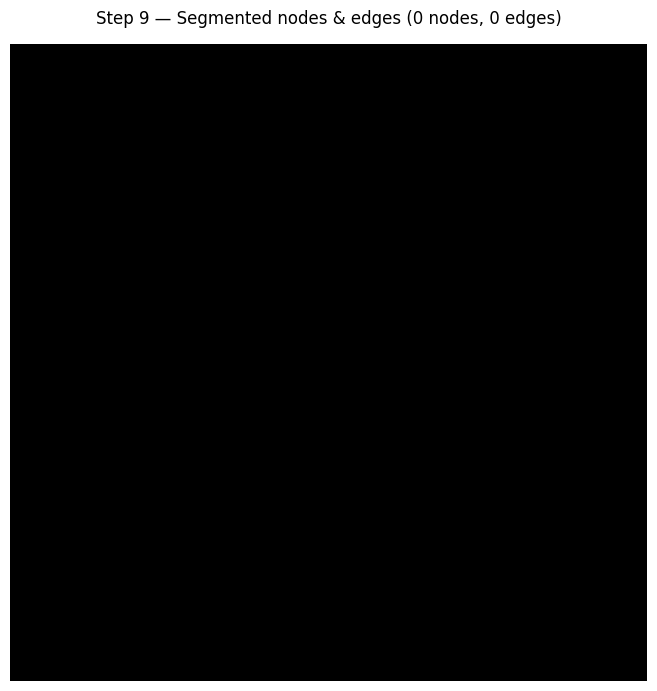

In [9]:
for i in range(10):
    idx = random.randrange(len(plans))
    plan = plans[idx]

    SHAPE = (512, 512)

    img = get_2d_plan(plan, show=False)

    graph = gm.build_graph(
        img,
        border=3,
        kernel_size=40,
        iterations=1,
        min_room_area=10,
        max_room_area=50000,
        poly_epsilon_ratio=0.003,
        gap_thresh=10,
        min_overlap=10,
        angle_thresh=0.95,
        show=True,
    )

## running it on a folder of images

In [ ]:
from pathlib import Path
import cv2
import matplotlib.pyplot as plt
import shutil

# ---------- config ----------
INPUT_DIR = Path("plan_imgs_100")         # <- your input image folder
OUTPUT_DIR = Path("op_seg_100_final_220526")  # <- root output folder
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

valid_ext = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

# ---------- collect images ----------
image_paths = sorted([
    p for p in INPUT_DIR.iterdir()
    if p.is_file() and p.suffix.lower() in valid_ext
])

print(f"Found {len(image_paths)} images in {INPUT_DIR}")

# ---------- loop ----------
for i, img_path in enumerate(image_paths):
    img = cv2.imread(str(img_path))
    if img is None:
        print(f"[FAIL] unreadable: {img_path.name}")
        continue

    img_out_dir = OUTPUT_DIR / img_path.stem
    img_out_dir.mkdir(parents=True, exist_ok=True)

    debug_dir = img_out_dir / "debug"
    debug_dir.mkdir(parents=True, exist_ok=True)

    cv2.imwrite(str(img_out_dir / f"{img_path.stem}_input.png"), img)

    graph = gm.build_graph(
        img,
        border=3,
        kernel_size=40,
        iterations=1,
        min_room_area=10,
        max_room_area=100000,
        poly_epsilon_ratio=0.003,
        gap_thresh=20,
        min_overlap=10,
        angle_thresh=0.95,
        show=False,
        save_steps=True,
        debug_dir=str(debug_dir),
        prefix=img_path.stem,
    )

    final_debug_file = debug_dir / f"{img_path.stem}_step_09_segment_nodes_edges.png"
    out_file = img_out_dir / f"{img_path.stem}_final.png"
    if final_debug_file.exists():
        shutil.copy(str(final_debug_file), str(out_file))
        print(f"[OK] {i+1}/{len(image_paths)} {img_path.name} -> {out_file}")
    else:
        print(f"[WARN] {i+1}/{len(image_paths)} {img_path.name} -> saved debug files to {debug_dir}")


Found 115 images in plan_imgs_100


NameError: name 'gm' is not defined